In [1]:
import json
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
from collections import OrderedDict
from collections import Counter, defaultdict, OrderedDict

import statsmodels.api as sm
from scipy.stats import norm
from scipy.interpolate import interp1d

%config InlineBackend.figure_format='retina'

In [2]:
n_folders = len([f for f in os.listdir("../manuscripts") if os.path.isdir(os.path.join("../manuscripts", f))])
print(n_folders)

18576


In [3]:
v1_only = True
post_2023_only = True

# Load list of post-2023 manuscripts from file
post_2023_manuscripts = set()
with open("../data/post2023_manuscripts.txt") as f:
    for line in f:
        # Each line: elife-100000-v1,elife-100000  --> we want the second entry
        parts = line.strip().split(',')
        if len(parts) > 1:
            manuscript_id = parts[1].strip()
            if manuscript_id:
                post_2023_manuscripts.add(manuscript_id)

# Find subfolders in evals/manuscripts/*/*/ that contain all 4 JSON files (allow any version, not just v1)
base_path = "../manuscripts"
manuscript_dirs = []
missing_files_info = {}

# Get total number of manuscript folders (excluding any hidden files/dirs)
total_manuscripts = len([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d)) and not d.startswith('.')])
print(f"[INFO] Total number of manuscripts (folders in '{base_path}'): {total_manuscripts}")

version_counts = Counter()          # Counts of picked manuscripts per version
manuscript_versions = defaultdict(list)  # manuscript_id -> list of chosen versions

for manuscript_id in os.listdir(base_path):
    if post_2023_only and manuscript_id not in post_2023_manuscripts:
        continue
    manuscript_path = os.path.join(base_path, manuscript_id)
    if not os.path.isdir(manuscript_path) or manuscript_id.startswith('.'):
        continue
    # find all subdirectories (version directories)
    version_dirs = [
        d for d in os.listdir(manuscript_path)
        if os.path.isdir(os.path.join(manuscript_path, d)) and not d.startswith('.')
    ]
    found_version = False
    for version in version_dirs:
        if v1_only and version != "v1":
            continue
        v_path = os.path.join(manuscript_path, version)
        required_files = ["eval_llm.json", "eval_peer.json", "cmp.json", "claims.json"]
        present = [os.path.exists(os.path.join(v_path, fname)) for fname in required_files]
        all_present = all(present)
        if all_present:
            manuscript_dirs.append((manuscript_id, v_path, version))
            found_version = True
            version_counts[version] += 1
            manuscript_versions[manuscript_id].append(version)
            break  # Only take the first version that is complete
        else:
            missing = [fname for idx, fname in enumerate(required_files) if not present[idx]]
            if manuscript_id not in missing_files_info:
                missing_files_info[manuscript_id] = []
            missing_files_info[manuscript_id].append((version, missing))
    if found_version and manuscript_id in missing_files_info:
        del missing_files_info[manuscript_id]

if missing_files_info:
    print(f"[INFO] {len(missing_files_info)} manuscripts are missing one or more required files in all available versions.")
    # for m_id, missing_list in missing_files_info.items():
    #     for version, files in missing_list:
    #         print(f"  {m_id}/{version}: missing {', '.join(files)}")
else:
    print("[INFO] All manuscripts have at least one version with all required files.")

print(f"[INFO] Found {len(manuscript_dirs)} manuscripts with all required files (in any version directory).")
print("[INFO] Number of manuscripts per version (with all required files):")
for version, count in version_counts.items():
    print(f"  Version {version}: {count}")

# Will concatenate all dfs from all manuscripts
dfs_llm = []
dfs_peer = []
dfs_cmp = []
dfs_claims = []
for manuscript_id, v_path, version in manuscript_dirs:
    with open(os.path.join(v_path, "eval_llm.json"), "r") as f:
        eval_llm = json.load(f)
    with open(os.path.join(v_path, "eval_peer.json"), "r") as f:
        eval_peer = json.load(f)
    with open(os.path.join(v_path, "cmp.json"), "r") as f:
        cmp = json.load(f)
    with open(os.path.join(v_path, "claims.json"), "r") as f:
        claims = json.load(f)
    df_llm = pd.DataFrame(eval_llm)
    df_peer = pd.DataFrame(eval_peer)
    df_cmp = pd.DataFrame(cmp)
    df_claims = pd.DataFrame(claims)
    # Add manuscript_id and version as columns for possible stratification
    for df in (df_llm, df_peer, df_cmp, df_claims):
        df["manuscript_id"] = manuscript_id
        df["version"] = version
    dfs_llm.append(df_llm)
    dfs_peer.append(df_peer)
    dfs_cmp.append(df_cmp)
    dfs_claims.append(df_claims)

# Concatenate dataframes
df_llm = pd.concat(dfs_llm, ignore_index=True)
df_peer = pd.concat(dfs_peer, ignore_index=True)
df_cmp = pd.concat(dfs_cmp, ignore_index=True)
df_claims = pd.concat(dfs_claims, ignore_index=True)

# Save each DataFrame to the 'data' folder as a CSV file
df_llm.to_csv('../data/df_llm.csv', index=False)
df_peer.to_csv('../data/df_peer.csv', index=False)
df_cmp.to_csv('../data/df_cmp.csv', index=False)
df_claims.to_csv('../data/df_claims.csv', index=False)

[INFO] Total number of manuscripts (folders in '../manuscripts'): 18576
[INFO] 113 manuscripts are missing one or more required files in all available versions.
[INFO] Found 2492 manuscripts with all required files (in any version directory).
[INFO] Number of manuscripts per version (with all required files):
  Version v1: 2492


In [4]:
df_llm

,result_id,claim_ids,result,reviewer_id,reviewer_name,evaluation_type,evaluation,result_type,manuscript_id,version
0,R1,"[C3, C34, C35, C36, C37, C38, C39]",Inhibitory cTBS applied to the left ATL signif...,OpenEval,OpenEval,SUPPORTED,"Claims C3, C34-C38 provide converging evidence...",MAJOR,elife-91771,v1
1,R2,"[C4, C40, C41, C42]",Inhibitory cTBS reduced BOLD activation in the...,OpenEval,OpenEval,SUPPORTED,"Claims C4, C40-C42 are supported by fMRI data ...",MAJOR,elife-91771,v1
2,R3,"[C5, C43, C44]",Changes in GABA concentrations induced by cTBS...,OpenEval,OpenEval,SUPPORTED,"Claims C5, C43-C44 demonstrate a tight mechani...",MAJOR,elife-91771,v1
3,R4,"[C46, C47, C48, C49, C50]",ATL cTBS induced task-specific inhibitory effe...,OpenEval,OpenEval,SUPPORTED,Claims C46-C50 are supported by behavioral dat...,MAJOR,elife-91771,v1
4,R5,"[C51, C52, C53, C54, C55, C56]",Participants categorized as responders showed ...,OpenEval,OpenEval,UNCERTAIN,Claims C51-C56 reveal important individual dif...,MAJOR,elife-91771,v1
...,...,...,...,...,...,...,...,...,...,...
45291,R11,"[C92, C93, C94, C95, C96]","Alpha-ketoglutarate and malate, which are NAD ...",OpenEval,OpenEval,UNCERTAIN,Claims C92-C96 describe correlations between c...,MAJOR,elife-87039,v1
45292,R12,"[C97, C98, C99, C100]",Overflow metabolism appears common in evolved ...,OpenEval,OpenEval,UNCERTAIN,Claims C97-C100 propose overflow metabolism as...,MAJOR,elife-87039,v1
45293,R13,"[C101, C102, C105]","The metabolome integrates environment, genetic...",OpenEval,OpenEval,SUPPORTED,Claims C101-C102 and C105 provide appropriate ...,MINOR,elife-87039,v1
45294,R14,[C109],Prior work shows that E. coli continues to acc...,OpenEval,OpenEval,SUPPORTED,Claim C109 accurately cites prior work on stat...,MINOR,elife-87039,v1


In [5]:
df_peer

,result_id,claim_ids,result,reviewer_id,reviewer_name,evaluation_type,evaluation,result_type,manuscript_id,version
0,R1,"[C3, C36, C37, C38, C54]",The study found that inhibitory cTBS applied t...,PEER_REVIEW,Peer Reviewer,SUPPORTED,"Reviewers explicitly affirmed this finding, wi...",MAJOR,elife-91771,v1
1,R2,"[C4, C41, C42, C40]",The study demonstrated that cTBS reduced BOLD ...,PEER_REVIEW,Peer Reviewer,SUPPORTED,"Reviewers confirmed this finding, noting the a...",MAJOR,elife-91771,v1
2,R3,"[C5, C43, C44, C6, C68]",The study found a significant negative correla...,PEER_REVIEW,Peer Reviewer,SUPPORTED,Reviewers acknowledged this as a novel contrib...,MAJOR,elife-91771,v1
3,R4,"[C9, C62, C63, C64, C65, C66]","The study claims a non-linear, inverted U-shap...",PEER_REVIEW,Peer Reviewer,UNCERTAIN,"Reviewer 1 explicitly challenged this claim, s...",MAJOR,elife-91771,v1
4,R5,"[C51, C52, C53, C93, C94]",The study categorized participants into respon...,PEER_REVIEW,Peer Reviewer,UNCERTAIN,Reviewer 1 raised a fundamental methodological...,MAJOR,elife-91771,v1
...,...,...,...,...,...,...,...,...,...,...
29237,R9,"[C97, C98, C99, C100]",Overflow metabolism appears common in evolved ...,PEER_REVIEW,Peer Reviewer,UNCERTAIN,While the PEP data supporting overflow metabol...,MINOR,elife-87039,v1
29238,R10,"[C101, C102, C103, C104]","The metabolome integrates environment, genetic...",PEER_REVIEW,Peer Reviewer,SUPPORTED,Reviewers acknowledged both the value and limi...,MAJOR,elife-87039,v1
29239,R11,"[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11,...",Background claims about the LTEE: 12 replicate...,PEER_REVIEW,Peer Reviewer,SUPPORTED,These are well-established background facts ab...,MINOR,elife-87039,v1
29240,R12,"[C31, C39, C41]",Principal components in exponential phase are ...,PEER_REVIEW,Peer Reviewer,SUPPORTED,These descriptive findings about PCA compositi...,MINOR,elife-87039,v1


In [6]:
df_claims

,claim_id,claim,claim_type,source,source_type,evidence,evidence_type,manuscript_id,version
0,C1,The anterior temporal lobe (ATL) is a hub for ...,EXPLICIT,The anterior temporal lobe (ATL) is a hub for ...,[TEXT],This claim is supported by citations to prior ...,"[CITATION, KNOWLEDGE]",elife-91771,v1
1,C2,GABAergic inhibition plays a crucial role in s...,EXPLICIT,GABAergic inhibition plays a crucial role in s...,[TEXT],This is a general statement supported by exist...,"[CITATION, KNOWLEDGE]",elife-91771,v1
2,C3,Inhibitory cTBS increased GABA concentrations ...,EXPLICIT,We found that inhibitory cTBS increased GABA c...,[TEXT],This claim is directly supported by experiment...,[DATA],elife-91771,v1
3,C4,Inhibitory cTBS reduced blood-oxygen level-dep...,EXPLICIT,We found that inhibitory cTBS increased GABA c...,[TEXT],This claim is supported by fMRI data comparing...,[DATA],elife-91771,v1
4,C5,Changes in GABA were tightly linked to changes...,EXPLICIT,"Crucially, changes in GABA were tightly linked...",[TEXT],This is supported by correlation analysis betw...,[DATA],elife-91771,v1
...,...,...,...,...,...,...,...,...,...
306969,C120,The quantile regression imputation of left-cen...,EXPLICIT,"We used methods from Wei et al., 2018 and the ...",[TEXT],The manuscript explicitly describes the imputa...,"[DATA, CITATION]",elife-87039,v1
306970,C121,Imputed values theoretically represent values ...,EXPLICIT,Imputed values theoretically represent values ...,[TEXT],The manuscript explicitly states this interpre...,[KNOWLEDGE],elife-87039,v1
306971,C122,Imputed values always fell below the detected ...,EXPLICIT,"As expected, our imputed values always fell be...","[TEXT, IMAGE]",The manuscript states this observation and ref...,[DATA],elife-87039,v1
306972,C123,Correlations between the replicates were high ...,EXPLICIT,"After imputation was performed, correlations b...","[TEXT, IMAGE]",The manuscript states this observation and ref...,[DATA],elife-87039,v1


In [7]:
df_cmp

,comparison_id,openeval_result_id,peer_result_id,openeval_evaluation_type,peer_evaluation_type,openeval_result_type,peer_result_type,comparison_type,comparison,n_openeval,n_peer,n_itx,manuscript_id,version
0,CMP1,R2,R2,SUPPORTED,SUPPORTED,MAJOR,MAJOR,agree,"Perfect agreement on claims C4, C40-C42 regard...",4.0,4.0,4,elife-91771,v1
1,CMP2,R1,R1,SUPPORTED,SUPPORTED,MAJOR,MAJOR,agree,"Strong agreement on claims C3, C36-C38 regardi...",7.0,5.0,4,elife-91771,v1
2,CMP3,R3,R3,SUPPORTED,SUPPORTED,MAJOR,MAJOR,agree,"Agreement on claims C5, C43-C44 regarding corr...",3.0,5.0,3,elife-91771,v1
3,CMP4,R6,R7,SUPPORTED,SUPPORTED,MAJOR,MINOR,agree,"Agreement on claims C31-C32, C57, C59-C60 rega...",7.0,6.0,5,elife-91771,v1
4,CMP5,R7,R4,SUPPORTED,UNCERTAIN,MAJOR,MAJOR,partial,Disagreement on inverted-U relationship claims...,5.0,6.0,4,elife-91771,v1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50898,CMP16,R6,R12,SUPPORTED,SUPPORTED,MAJOR,MINOR,agree,"Both address parallelism analysis claims (C39,...",4.0,3.0,2,elife-87039,v1
50899,CMP17,R3,R10,SUPPORTED,SUPPORTED,MINOR,MAJOR,agree,Both address metabolome coverage limitation (C...,8.0,4.0,1,elife-87039,v1
50900,CMP18,R2,R13,SUPPORTED,SUPPORTED,MINOR,MINOR,agree,Overlap on experimental design details (C112-C...,11.0,10.0,5,elife-87039,v1
50901,CMP19,R4,R13,SUPPORTED,SUPPORTED,MAJOR,MINOR,agree,Minor overlap on PCA details (C35-C36). OpenEv...,11.0,10.0,2,elife-87039,v1


In [8]:
df_cmp.columns

Index(['comparison_id', 'openeval_result_id', 'peer_result_id',
       'openeval_evaluation_type', 'peer_evaluation_type',
       'openeval_result_type', 'peer_result_type', 'comparison_type',
       'comparison', 'n_openeval', 'n_peer', 'n_itx', 'manuscript_id',
       'version'],
      dtype='object')

In [9]:
print(df_cmp["peer_evaluation_type"].unique())
print(df_cmp["openeval_evaluation_type"].unique())

# Replace NaN with "Not reviewed"
df_cmp["peer_evaluation_type"] = df_cmp["peer_evaluation_type"].fillna("Unknown").replace("Unknown", "Not reviewed")
df_cmp["openeval_evaluation_type"] = df_cmp["openeval_evaluation_type"].fillna("Unknown").replace("Unknown", "Not reviewed")

# Normalize to lowercase, then capitalize only the first letter
df_cmp["peer_evaluation_type"] = df_cmp["peer_evaluation_type"].astype(str).str.lower().str.capitalize()
df_cmp["openeval_evaluation_type"] = df_cmp["openeval_evaluation_type"].astype(str).str.lower().str.capitalize()

# Set order
ordered_statuses = ["Supported", "Uncertain", "Unsupported", "Not reviewed"]
df_cmp["peer_evaluation_type"] = pd.Categorical(df_cmp["peer_evaluation_type"], categories=ordered_statuses, ordered=True)
df_cmp["openeval_evaluation_type"] = pd.Categorical(df_cmp["openeval_evaluation_type"], categories=ordered_statuses, ordered=True)

['SUPPORTED' 'UNCERTAIN' None 'UNSUPPORTED']
['SUPPORTED' 'UNCERTAIN' None 'UNSUPPORTED']


In [10]:
df_cmp["comparison_type"].unique()

array(['agree', 'partial', 'disjoint', 'disagree'], dtype=object)

# Fraction of claims per manuscript that are reviewed:

In [11]:
import ast
import numpy as np
import pandas as pd

# -----------------------
# Helper: parse claim_ids
# -----------------------
def parse_claim_ids(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            s = x.strip().strip("[]")
            if not s:
                return []
            return [t.strip().strip("'").strip('"') for t in s.split(",")]
    return []

# -----------------------
# 1) Total claims per manuscript (from df_claims)
# -----------------------
claims = df_claims.copy()
claims["manuscript_id"] = claims["manuscript_id"].astype(str).str.strip()
claims["claim_id"] = claims["claim_id"].astype(str).str.strip()

total_claims_per_ms = (
    claims.groupby("manuscript_id")["claim_id"]
    .nunique()
)

# -----------------------
# 2) Reviewed claims per manuscript — PEER
# -----------------------
peer = df_peer.copy()
peer["manuscript_id"] = peer["manuscript_id"].astype(str).str.strip()
peer["claim_id"] = peer["claim_ids"].apply(parse_claim_ids)

peer_exploded = peer.explode("claim_id")
peer_exploded["claim_id"] = peer_exploded["claim_id"].astype(str).str.strip()

peer_claims_per_ms = (
    peer_exploded.groupby("manuscript_id")["claim_id"]
    .nunique()
)

peer_fraction_reviewed = (
    peer_claims_per_ms / total_claims_per_ms
).dropna()

# -----------------------
# 3) Reviewed claims per manuscript — LLM
# -----------------------
llm = df_llm.copy()
llm["manuscript_id"] = llm["manuscript_id"].astype(str).str.strip()
llm["claim_id"] = llm["claim_ids"].apply(parse_claim_ids)

llm_exploded = llm.explode("claim_id")
llm_exploded["claim_id"] = llm_exploded["claim_id"].astype(str).str.strip()

llm_claims_per_ms = (
    llm_exploded.groupby("manuscript_id")["claim_id"]
    .nunique()
)

llm_fraction_reviewed = (
    llm_claims_per_ms / total_claims_per_ms
).dropna()

# -----------------------
# 4) Print mean ± SD
# -----------------------
print(
    f"Peer: mean fraction reviewed = "
    f"{peer_fraction_reviewed.mean():.3f} ± {peer_fraction_reviewed.std():.3f} "
    f"(SD, n={peer_fraction_reviewed.shape[0]} manuscripts)"
)

print(
    f"LLM:  mean fraction reviewed = "
    f"{llm_fraction_reviewed.mean():.3f} ± {llm_fraction_reviewed.std():.3f} "
    f"(SD, n={llm_fraction_reviewed.shape[0]} manuscripts)"
)


Peer: mean fraction reviewed = 0.681 ± 0.202 (SD, n=2492 manuscripts)
LLM:  mean fraction reviewed = 0.928 ± 0.125 (SD, n=2492 manuscripts)


In [12]:
# Number of results per manuscript
peer_results_per_ms = peer.groupby("manuscript_id").size()
llm_results_per_ms  = llm.groupby("manuscript_id").size()

# Print mean ± SD
print(
    f"Peer: mean results per manuscript = "
    f"{peer_results_per_ms.mean():.2f} ± {peer_results_per_ms.std():.2f} "
    f"(SD, n={peer_results_per_ms.shape[0]} manuscripts)"
)

print(
    f"LLM:  mean results per manuscript = "
    f"{llm_results_per_ms.mean():.2f} ± {llm_results_per_ms.std():.2f} "
    f"(SD, n={llm_results_per_ms.shape[0]} manuscripts)"
)

Peer: mean results per manuscript = 11.73 ± 3.16 (SD, n=2492 manuscripts)
LLM:  mean results per manuscript = 18.18 ± 5.50 (SD, n=2492 manuscripts)


In [13]:
print(len(df_llm[df_llm["evaluation_type"]=="SUPPORTED"]))
print(len(df_llm[df_llm["evaluation_type"]=="UNCERTAIN"]))
print(len(df_llm[df_llm["evaluation_type"]=="UNSUPPORTED"]))

print(len(df_peer[df_peer["evaluation_type"]=="SUPPORTED"]))
print(len(df_peer[df_peer["evaluation_type"]=="UNCERTAIN"]))
print(len(df_peer[df_peer["evaluation_type"]=="UNSUPPORTED"]))

40916
4330
50
24241
4750
251


# Plotting

Plotting setup:

In [14]:
bar_color = "#6baed6"

# Updated colors for new subcategories
# colors = {
#     "Agree": "#31a354",
#     "Partial:OpenEvalUncertain": "#FDBB84", # OpenEval Uncertain
#     "Partial:PeerUncertain": "#FDD49E",     # Peer Uncertain
#     "Disagree": "#e34a33",
#     "Disjoint:OpenEvalOnly": "#6497b1",      # Disjoint, only LLM/OpenEval has the result
#     "Disjoint:PeerOnly": "#b3cde0"         # Disjoint, only Peer has the result
# }
colors = {
    "Agree": "darkgreen",
    "Partial:OpenEvalUncertain": "darkorange", # OpenEval Uncertain
    "Partial:PeerUncertain": "#FDBB84",     # Peer Uncertain
    "Disagree": "#e34a33",
    "Disjoint:OpenEvalOnly": "darkgrey",      # Disjoint, only LLM/OpenEval has the result
    "Disjoint:PeerOnly": "lightgrey"         # Disjoint, only Peer has the result
}
status_colors = colors

colors_stacked = {
    "shared": "#6497b1",
    "openeval_only": "#b3cde0",
    "peer_only": "#03396c"
}
jaccard_color = "#6497b1"

fontsize = 12

def partial_split(row):
    if row["comparison_type"] == "Partial":
        peer_s = str(row["peer_evaluation_type"]).lower()
        open_s = str(row["openeval_evaluation_type"]).lower()
        if peer_s == "uncertain":
            return "Partial:PeerUncertain"
        elif open_s == "uncertain":
            return "Partial:OpenEvalUncertain"
        else:
            return "Partial:Other"
    return None

def disjoint_split(row):
    if row["comparison_type"] == "Disjoint":
        n_peer = row.get("n_peer", np.nan)
        n_open = row.get("n_openeval", np.nan)
        if pd.isna(n_peer):
            n_peer = 0
        if pd.isna(n_open):
            n_open = 0
        if (n_peer == 0 or n_peer == 0.0) and (n_open > 0):
            return "Disjoint:OpenEvalOnly"
        elif (n_open == 0 or n_open == 0.0) and (n_peer > 0):
            return "Disjoint:PeerOnly"
        elif n_peer > n_open:
            return "Disjoint:PeerOnly"
        else:
            return "Disjoint:OpenEvalOnly"
    return None

df_cmp["comparison_type"] = df_cmp["comparison_type"].astype(str).str.capitalize()
df_cmp["intersection_fraction"] = df_cmp["n_itx"] / df_cmp[["n_openeval", "n_peer"]].max(axis=1)

def safe_int(s):
    return s.where(pd.notnull(s) & np.isfinite(s), 0).astype(int)

df_cmp["n_peer_int"] = safe_int(df_cmp["n_peer"])
df_cmp["n_openeval_int"] = safe_int(df_cmp["n_openeval"])

# Subcategory/workup for barplot, partial, disjoint status
df_cmp["agree_bar_cat"] = df_cmp["comparison_type"]
partial_mask = df_cmp["comparison_type"] == "Partial"
df_cmp.loc[partial_mask, "agree_bar_cat"] = df_cmp[partial_mask].apply(partial_split, axis=1)
disjoint_mask = df_cmp["comparison_type"] == "Disjoint"
df_cmp.loc[disjoint_mask, "agree_bar_cat"] = df_cmp[disjoint_mask].apply(disjoint_split, axis=1)
stacked_bar_categories = [
    "Agree",
    "Partial:PeerUncertain", 
    "Partial:OpenEvalUncertain", 
    "Disagree", 
    "Disjoint:PeerOnly", 
    "Disjoint:OpenEvalOnly"
]

agree_counts = OrderedDict((cat, 0) for cat in stacked_bar_categories)
for cat, count in df_cmp["agree_bar_cat"].value_counts().items():
    if cat in agree_counts:
        agree_counts[cat] = count

desired_agree_order = ["Agree", "Partial", "Disagree", "Disjoint"]

Plot agreement status between peer and OpenEval:

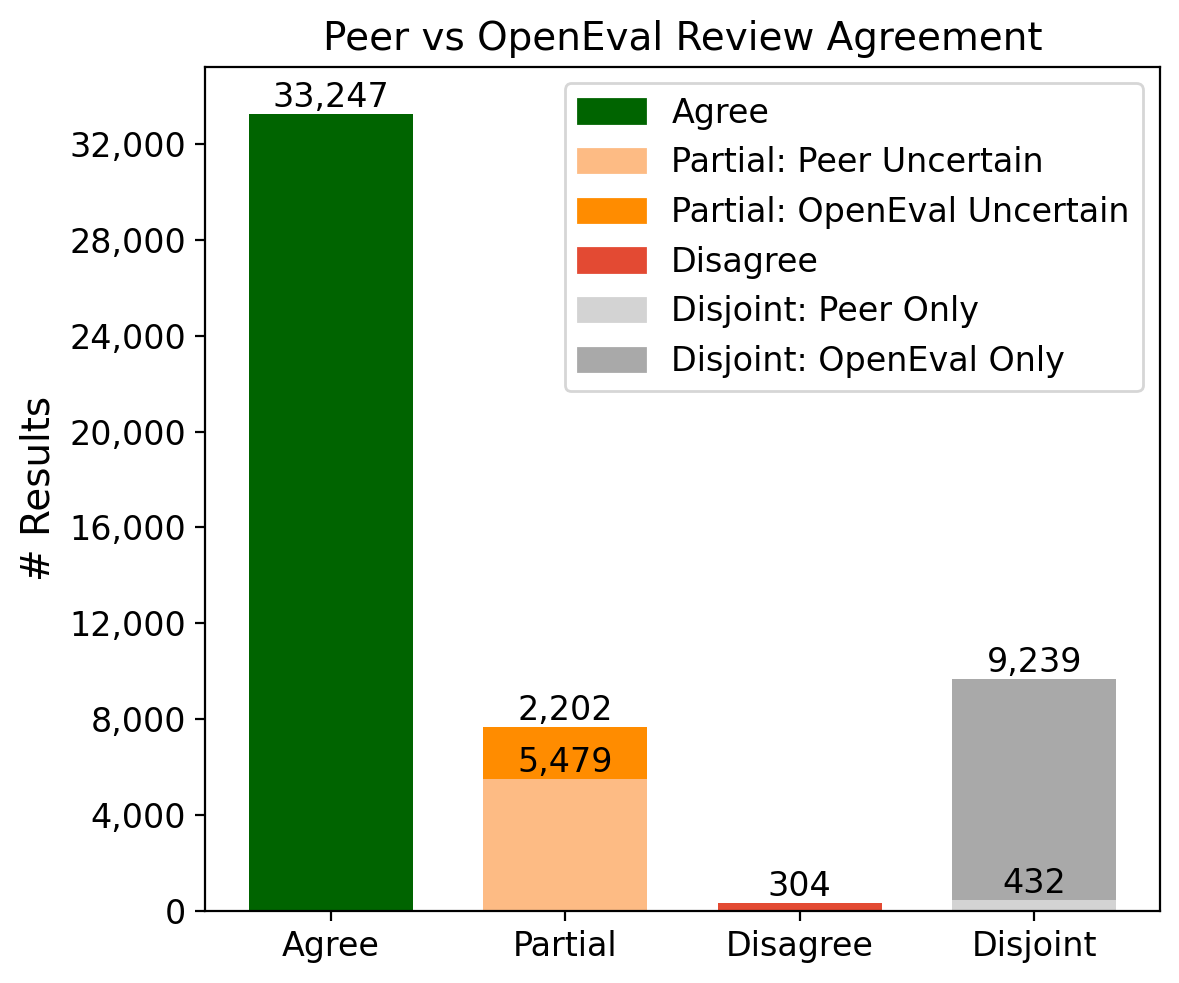

In [15]:
import matplotlib.ticker as mticker

bar_groups = ["Agree", "Partial", "Disagree", "Disjoint"]
partial_cats = ["Partial:PeerUncertain", "Partial:OpenEvalUncertain"]
disjoint_cats = ["Disjoint:PeerOnly", "Disjoint:OpenEvalOnly"]
y_main = [
    agree_counts["Agree"],
    agree_counts["Partial:PeerUncertain"],
    agree_counts["Disagree"],
    agree_counts["Disjoint:PeerOnly"]
]
y_stack = [
    0,
    agree_counts["Partial:OpenEvalUncertain"],
    0,
    agree_counts["Disjoint:OpenEvalOnly"]
]
bar_colors_main = [
    colors["Agree"],
    colors.get("Partial:PeerUncertain", "#ccc"),
    colors["Disagree"],
    colors.get("Disjoint:PeerOnly", "#ccc")
]
bar_colors_stack = [
    "#fff",
    colors.get("Partial:OpenEvalUncertain", "#ccc"),
    "#fff",
    colors.get("Disjoint:OpenEvalOnly", "#ccc")
]
bar_labels_main = ["Agree", "Peer Uncertain", "Disagree", "Peer Only"]
bar_labels_stack = ["", "OpenEval Uncertain", "", "OpenEval Only"]

fig_agree, ax_agree = plt.subplots(figsize=(6, 5))
bar_width = 0.7
bar_positions = range(len(bar_groups))
main_bars = ax_agree.bar(bar_positions, y_main, color=bar_colors_main, width=bar_width, label=bar_labels_main)
stack_bars = ax_agree.bar(bar_positions, y_stack, 
                          bottom=y_main, color=bar_colors_stack, width=bar_width, label=bar_labels_stack)

# Helper to format thousands with commas
def format_thousands(val):
    return "{:,}".format(val)

for i, val in enumerate(y_main):
    if val > 0:
        ax_agree.text(i, val + 0.3, format_thousands(val), ha="center", va="bottom", fontsize=fontsize)
for i, (val_stack, val_main) in enumerate(zip(y_stack, y_main)):
    if val_stack > 0:
        ax_agree.text(i, val_main + val_stack + 0.3, format_thousands(val_stack), ha="center", va="bottom", fontsize=fontsize)
ax_agree.set_xticks(bar_positions)
ax_agree.set_xticklabels(bar_groups, fontsize=fontsize)
ax_agree.set_title("Peer vs OpenEval Review Agreement", fontsize=fontsize+2)
# ax_agree.set_xlabel("Agreement Status", fontsize=fontsize+2)
ax_agree.set_ylabel("# Results", fontsize=fontsize+2)
ax_agree.grid(False)

ax_agree.yaxis.set_major_locator(MaxNLocator(integer=True))
# Use FuncFormatter to display y ticklabels with comma separators
ax_agree.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: format_thousands(int(x)) if x == int(x) else ""))
ax_agree.tick_params(axis="y", labelsize=fontsize)
bar_heights = [y_main[i] + y_stack[i] for i in range(len(y_main))]
if bar_heights:
    ymax = max(bar_heights)
    ax_agree.set_ylim(top=ymax + max(1, int(0.06 * ymax)))

legend_patches = [
    mpatches.Patch(color=colors.get("Agree"), label="Agree"),
    mpatches.Patch(color=colors.get("Partial:PeerUncertain"), label="Partial: Peer Uncertain"),
    mpatches.Patch(color=colors.get("Partial:OpenEvalUncertain"), label="Partial: OpenEval Uncertain"),
    mpatches.Patch(color=colors.get("Disagree"), label="Disagree"),
    mpatches.Patch(color=colors.get("Disjoint:PeerOnly"), label="Disjoint: Peer Only"),
    mpatches.Patch(color=colors.get("Disjoint:OpenEvalOnly"), label="Disjoint: OpenEval Only"),
]
legend_patches_present = []
for cat, patch in zip(stacked_bar_categories, legend_patches):
    if agree_counts[cat] > 0:
        legend_patches_present.append(patch)
if legend_patches_present:
    ax_agree.legend(handles=legend_patches_present, fontsize=fontsize, title_fontsize=fontsize, loc="best")
plt.tight_layout()
fig_agree.savefig("figures/1_eval_agreement_bar_all_stacked.png", dpi=300, bbox_inches='tight')
plt.show()

Plot # of claims per result:

MAJOR - Peer mean ± SD: 8.94 ± 6.00
MAJOR - OpenEval mean ± SD: 6.92 ± 4.31
MAJOR - T-test between Peer and OpenEval #claims per result: t=45.558, p=0
MINOR - Peer mean ± SD: 7.73 ± 8.64
MINOR - OpenEval mean ± SD: 5.50 ± 5.37
MINOR - T-test between Peer and OpenEval #claims per result: t=25.263, p=6e-139


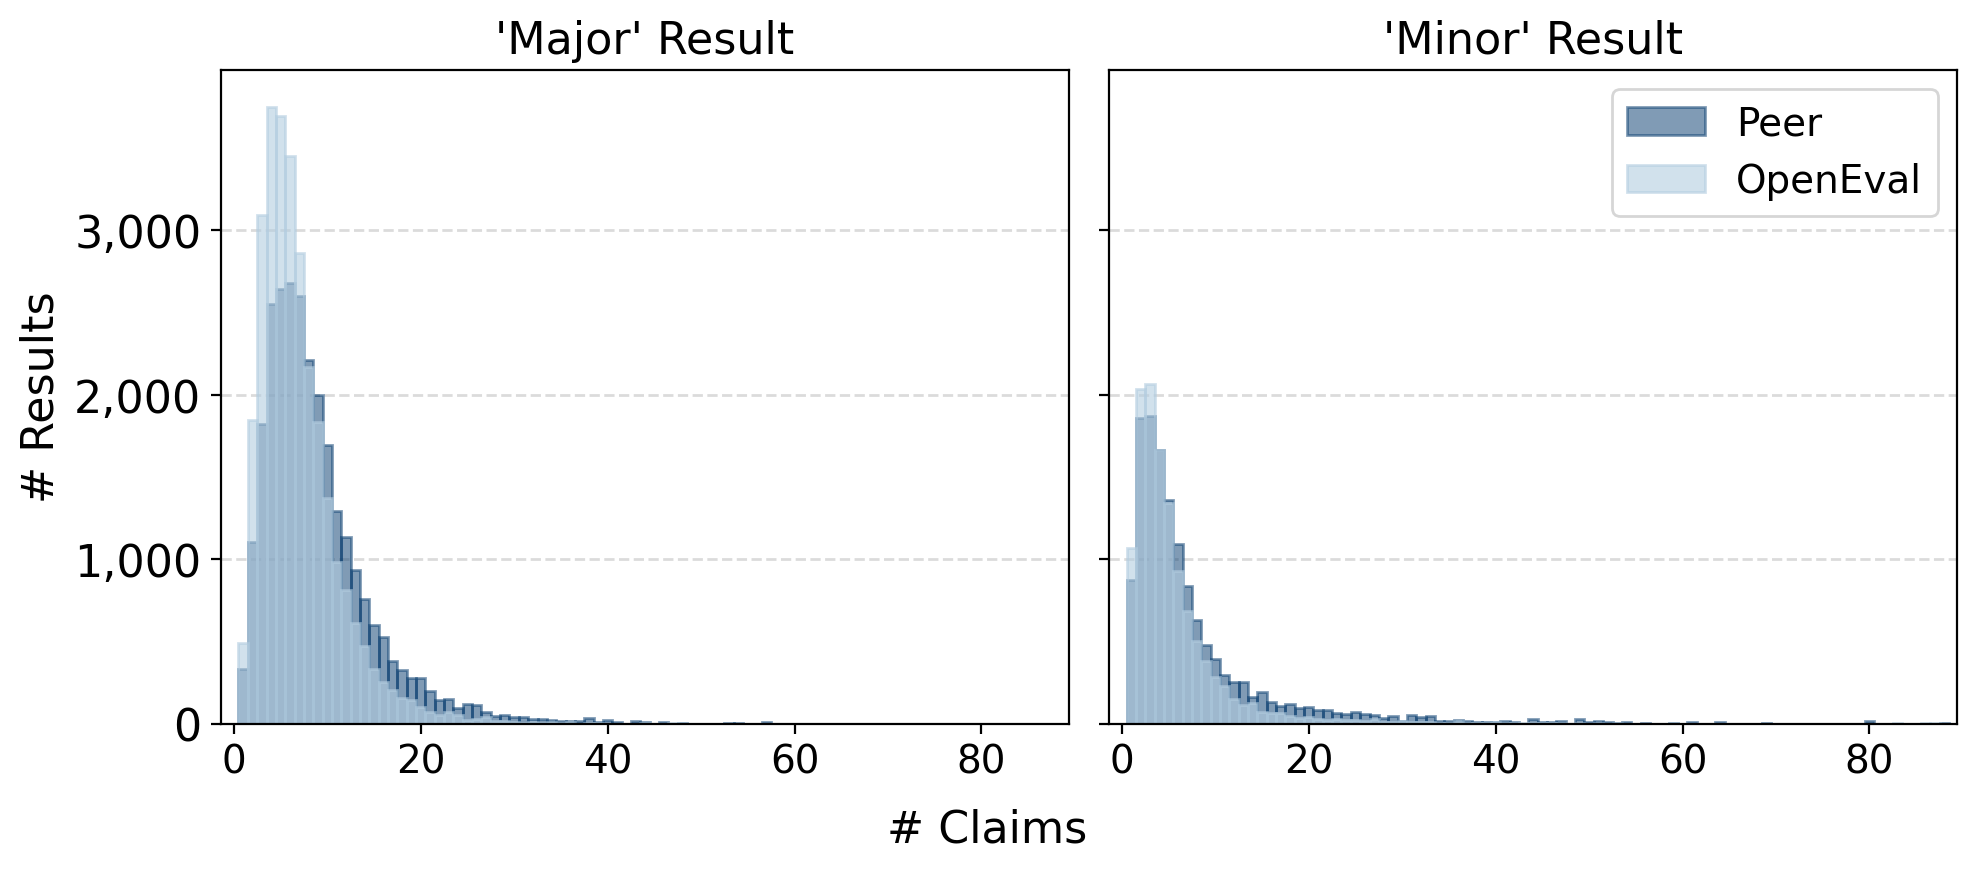


>>> TOTAL (MAJOR + MINOR, all non-disjoint):
Peer mean ± SD: 8.53 ± 7.02
OpenEval mean ± SD: 6.50 ± 4.69
T-test between Peer and OpenEval #claims per result (all): t=48.833, p=0


In [16]:
df_cmp_no_disjoint = df_cmp.copy()
# Exclude Disjoint results
df_cmp_no_disjoint = df_cmp_no_disjoint[df_cmp_no_disjoint["comparison_type"] != "Disjoint"]

# Split OpenEval and Peer by *their own* result_type
df_oe_major = df_cmp_no_disjoint[df_cmp_no_disjoint["openeval_result_type"] == "MAJOR"]
df_oe_minor = df_cmp_no_disjoint[df_cmp_no_disjoint["openeval_result_type"] == "MINOR"]
df_peer_major = df_cmp_no_disjoint[df_cmp_no_disjoint["peer_result_type"] == "MAJOR"]
df_peer_minor = df_cmp_no_disjoint[df_cmp_no_disjoint["peer_result_type"] == "MINOR"]

# Prepare data for both (for each panel: 
#   left = MAJOR, right = MINOR; for each, plot OE and Peer)
hist_data = [
    (
        "MAJOR",
        df_oe_major["n_openeval_int"].dropna(),
        df_peer_major["n_peer_int"].dropna(),
        "major"
    ),
    (
        "MINOR",
        df_oe_minor["n_openeval_int"].dropna(),
        df_peer_minor["n_peer_int"].dropna(),
        "minor"
    ),
]

# Calculate global bins for a consistent x-axis between plots
any_nonempty = any((len(oe) > 0 or len(peer) > 0) for _, oe, peer, _ in hist_data)
if any_nonempty:
    max_x = 0
    for _, oe, peer, _ in hist_data:
        oe_max = oe.max() if len(oe) > 0 else 0
        peer_max = peer.max() if len(peer) > 0 else 0
        max_x = max(max_x, oe_max, peer_max)
    bins_claims = np.arange(0, max_x + 2) - 0.5
else:
    bins_claims = np.arange(0, 2) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
fontsize = 16

# Formatter for comma-separated thousands on y-ticks
import matplotlib.ticker as mticker
def format_thousands(x, pos=None):
    if x == int(x):
        return "{:,}".format(int(x))
    else:
        return ""

# Track ymax for later so the plots maintain square and even y-axis limits
ymax = 0
for ax, (res_type, n_oe, n_peer, fname_suffix) in zip(axes, hist_data):
    if len(n_oe) == 0 and len(n_peer) == 0:
        print(f"No {res_type} results present.")
        ax.set_visible(False)
        continue

    # Plot histograms
    peer_hist = ax.hist(
        n_peer,
        bins=bins_claims,
        alpha=0.5,
        label="Peer",
        color=colors_stacked["peer_only"],
        edgecolor=colors_stacked["peer_only"]
    ) if len(n_peer) > 0 else (np.array([]), np.array([]), np.array([]))
    openeval_hist = ax.hist(
        n_oe,
        bins=bins_claims,
        alpha=0.6,
        label="OpenEval",
        color=colors_stacked["openeval_only"],
        edgecolor=colors_stacked["openeval_only"]
    ) if len(n_oe) > 0 else (np.array([]), np.array([]), np.array([]))
    local_ymax = max(peer_hist[0].max() if len(peer_hist[0]) > 0 else 0, 
                     openeval_hist[0].max() if len(openeval_hist[0]) > 0 else 0)
    ymax = max(ymax, local_ymax)

    # Stats and test
    # Peer
    if len(n_peer) > 0:
        peer_mean, peer_std = np.mean(n_peer), np.std(n_peer)
        print(f"{res_type} - Peer mean ± SD: {peer_mean:.2f} ± {peer_std:.2f}")
    else:
        peer_mean, peer_std = np.nan, np.nan
        print(f"{res_type} - Peer mean ± SD: NA (no data)")
    # OpenEval
    if len(n_oe) > 0:
        openeval_mean, openeval_std = np.mean(n_oe), np.std(n_oe)
        print(f"{res_type} - OpenEval mean ± SD: {openeval_mean:.2f} ± {openeval_std:.2f}")
    else:
        openeval_mean, openeval_std = np.nan, np.nan
        print(f"{res_type} - OpenEval mean ± SD: NA (no data)")
    # T-test (only if both have >1 value)
    from scipy.stats import ttest_ind
    if len(n_peer) > 1 and len(n_oe) > 1:
        t_stat, p_val = ttest_ind(
            n_peer, 
            n_oe, 
            equal_var=False
        )
        print(f"{res_type} - T-test between Peer and OpenEval #claims per result: t={t_stat:.3f}, p={p_val:.3g}")
    else:
        print(f"{res_type} - T-test between Peer and OpenEval #claims per result: NA (insufficient data)")

    ax.set_title(f"'{res_type.capitalize()}' Result", fontsize=fontsize)
    # Remove per-axis xlabel; use only a main xlabel for both plots
    # ax.set_xlabel("# Claims", fontsize=fontsize)
    if ax is axes[0]:
        ax.set_ylabel("# Results", fontsize=fontsize)
    ax.margins(x=0.01)
    ax.tick_params(axis='x', labelsize=fontsize-2)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    # Set y-axis tick formatter to comma-separate thousands
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_thousands))

for ax in axes:
    if ax.get_visible():
        ax.set_ylim(0, ymax + max(1, int(0.06 * ymax)))

axes[1].legend(fontsize=fontsize-2, title_fontsize=fontsize)

# fig.suptitle("# Claims per Result", fontsize=fontsize+2, y=0.95)
# Add a single shared X label below both axes (centered and reduce label padding)
fig.supxlabel("# Claims", fontsize=fontsize, y=0.04)

plt.tight_layout()
fig.savefig(f"figures/1_claims_per_result_histogram_major_minor.png", dpi=300, bbox_inches="tight")
plt.show()

# === Additional: Print total mean and mean ± SD for all (not split by major/minor, just all non-disjoint) ===
n_peer_all = df_cmp_no_disjoint["n_peer_int"]
n_openeval_all = df_cmp_no_disjoint["n_openeval_int"]
peer_mean_all, peer_std_all = np.mean(n_peer_all), np.std(n_peer_all)
openeval_mean_all, openeval_std_all = np.mean(n_openeval_all), np.std(n_openeval_all)
print("\n>>> TOTAL (MAJOR + MINOR, all non-disjoint):")
print(f"Peer mean ± SD: {peer_mean_all:.2f} ± {peer_std_all:.2f}")
print(f"OpenEval mean ± SD: {openeval_mean_all:.2f} ± {openeval_std_all:.2f}")
from scipy.stats import ttest_ind
t_stat_all, p_val_all = ttest_ind(n_peer_all, n_openeval_all, equal_var=False)
print(f"T-test between Peer and OpenEval #claims per result (all): t={t_stat_all:.3f}, p={p_val_all:.3g}")


Plot mean vs cariance of # claims per result:

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_39433/3642974173.py:38: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(xlim)
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_39433/3642974173.py:39: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim)
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_39433/3642974173.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


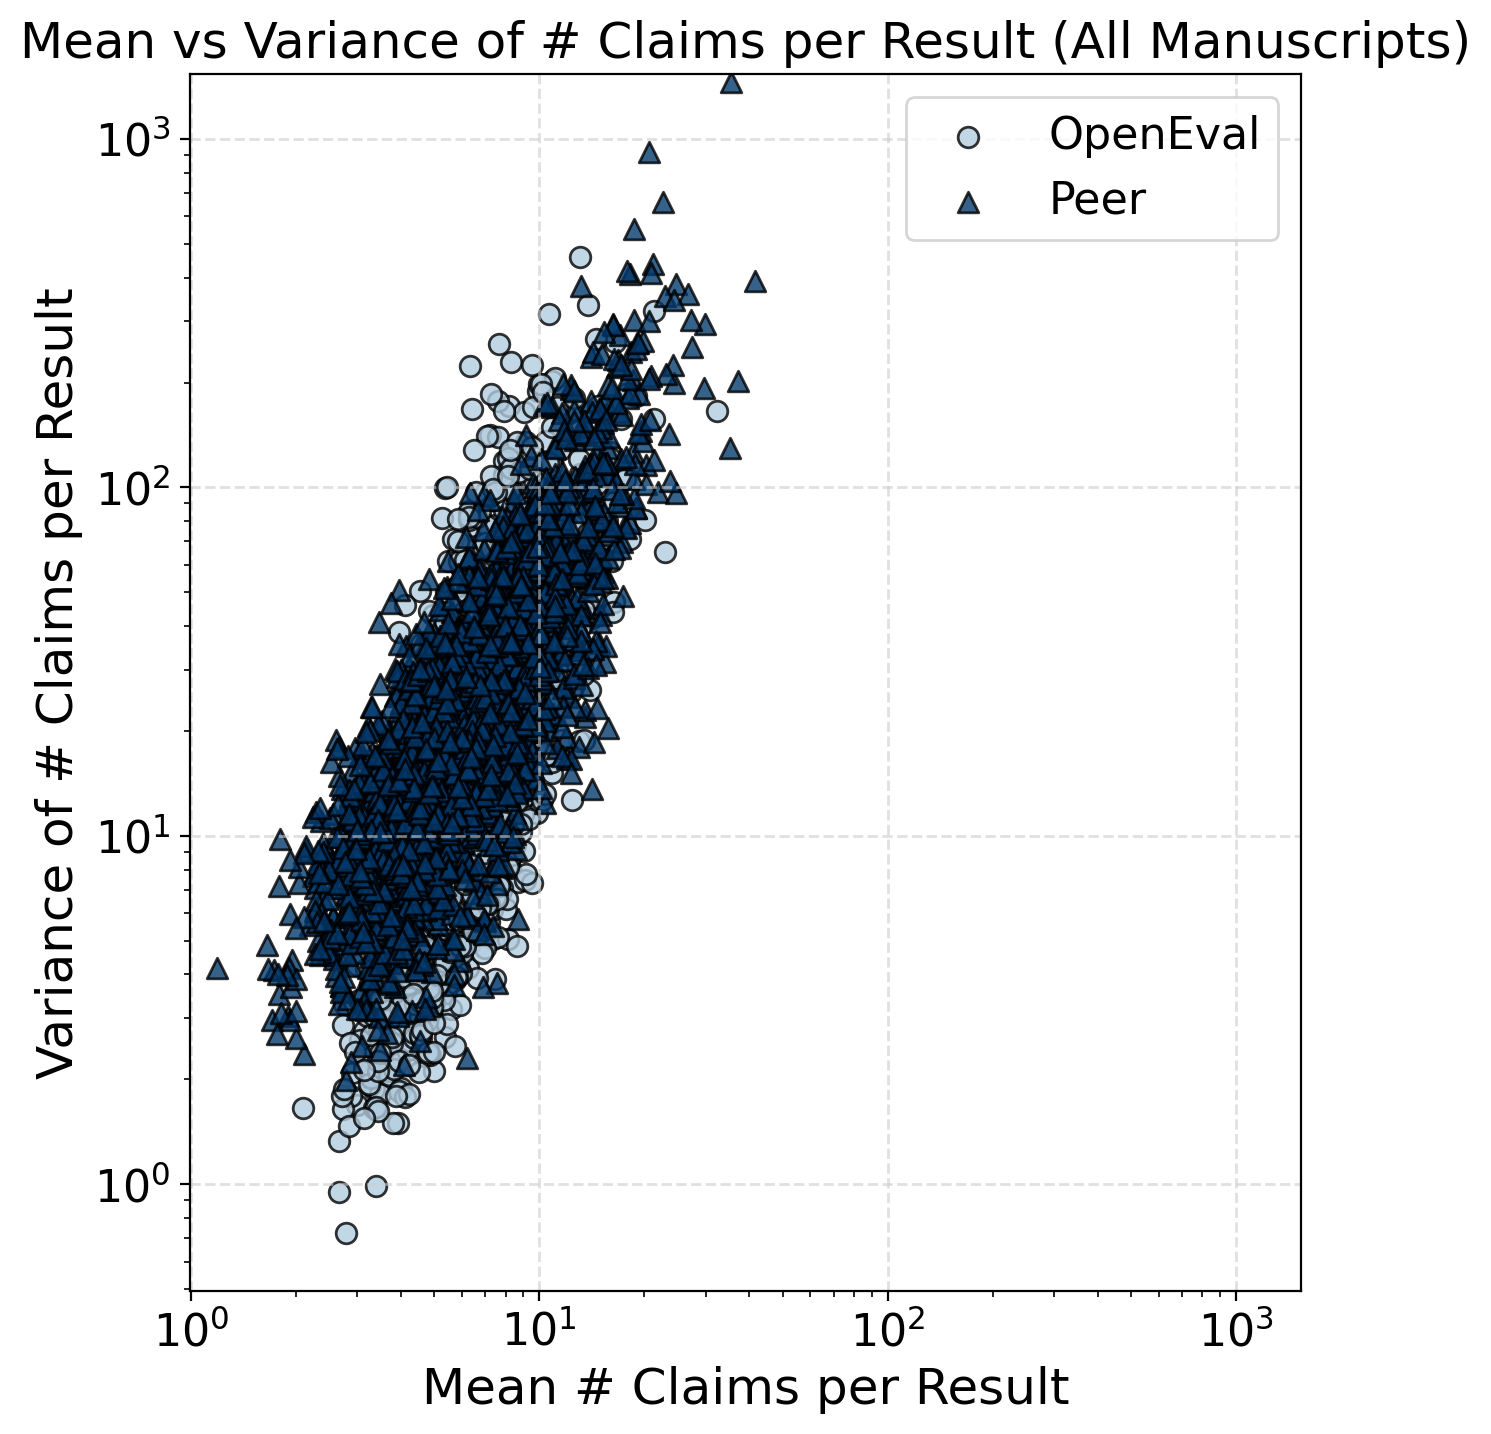

In [17]:
claims_stats = df_cmp.groupby("manuscript_id").agg({
    "n_peer_int": ['mean', 'var'],
    "n_openeval_int": ['mean', 'var']
})
claims_stats.columns = ["peer_mean", "peer_var", "openeval_mean", "openeval_var"]
claims_stats = claims_stats.reset_index()
vals_openeval_mean = claims_stats['openeval_mean'].replace(0, np.nan).dropna()
vals_openeval_var = claims_stats['openeval_var'].replace(0, np.nan).dropna()
vals_peer_mean = claims_stats['peer_mean'].replace(0, np.nan).dropna()
vals_peer_var = claims_stats['peer_var'].replace(0, np.nan).dropna()
all_mean = pd.concat([vals_openeval_mean, vals_peer_mean])
all_var = pd.concat([vals_openeval_var, vals_peer_var])
x_max = all_mean.max()
y_max = all_var.max()
max_val = max(x_max, y_max) * 1.05
xlim = (0, max_val)
ylim = (0, max_val)
fig, ax = plt.subplots(figsize=(7.3, 7.3), constrained_layout=True)
ax.scatter(
    claims_stats['openeval_mean'], claims_stats['openeval_var'],
    color=colors_stacked["openeval_only"], marker="o", s=55, alpha=0.8,
    edgecolor="black", label="OpenEval"
)
ax.scatter(
    claims_stats['peer_mean'], claims_stats['peer_var'],
    color=colors_stacked["peer_only"], marker="^", s=55, alpha=0.8,
    edgecolor="black", label="Peer"
)
ax.set_xlabel("Mean # Claims per Result", fontsize=fontsize+2)
ax.set_ylabel("Variance of # Claims per Result", fontsize=fontsize+2)
ax.set_title("Mean vs Variance of # Claims per Result (All Manuscripts)", fontsize=fontsize+2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=fontsize, title_fontsize=fontsize)
ax.grid(axis='both', linestyle="--", color="#cccccc", linewidth=1, alpha=0.6, zorder=0)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

fig.savefig("figures/claims_mean_vs_var_all.png", dpi=300, bbox_inches="tight")

plt.show()

Confusion Matrix: Peer vs LLM result status

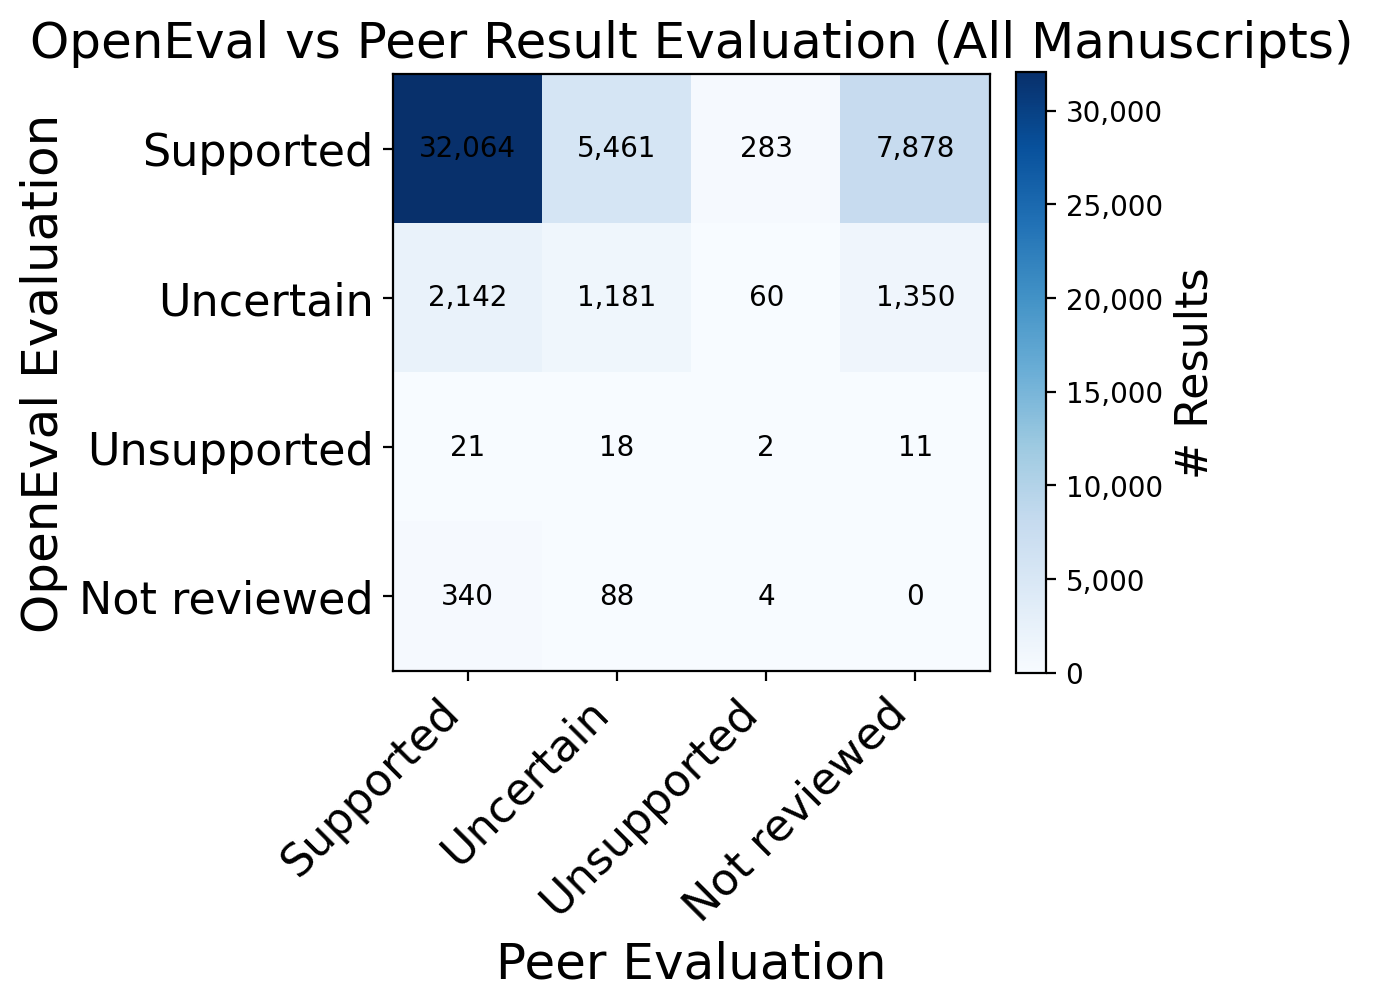

In [18]:
import matplotlib.ticker as mticker

fig_conf, ax_conf = plt.subplots(figsize=(6.3, 6.3))
conf_mat = pd.crosstab(df_cmp["peer_evaluation_type"], df_cmp["openeval_evaluation_type"]).reindex(
    index=ordered_statuses, columns=ordered_statuses, fill_value=0
)
im = ax_conf.imshow(conf_mat.T, cmap="Blues", aspect="equal")
ax_conf.set_title("OpenEval vs Peer Result Evaluation (All Manuscripts)", fontsize=fontsize+2)
ax_conf.set_xlabel("Peer Evaluation", fontsize=fontsize+2)
ax_conf.set_ylabel("OpenEval Evaluation", fontsize=fontsize+2)
ax_conf.set_xticks(range(len(ordered_statuses)))
ax_conf.set_yticks(range(len(ordered_statuses)))
ax_conf.set_xticklabels(ordered_statuses, rotation=45, ha="right", fontsize=fontsize)
ax_conf.set_yticklabels(ordered_statuses, fontsize=fontsize)

for i in range(len(ordered_statuses)):
    for j in range(len(ordered_statuses)):
        val = conf_mat.iloc[j, i]
        # Format with thousands separator
        ax_conf.text(j, i, f"{val:,}", ha="center", va="center", color="black", fontsize=10)

cbar = fig_conf.colorbar(im, ax=ax_conf, fraction=0.046, pad=0.04)
cbar.set_label("# Results", fontsize=fontsize)
# Set colorbar tick labels with thousands separators
cbar.formatter = mticker.FuncFormatter(lambda x, _: f"{int(x):,}" if x == int(x) else f"{x:,}")
cbar.update_ticks()

ax_conf.set_aspect('equal', adjustable='box')
plt.tight_layout()
fig_conf.savefig("figures/evals_confusion_matrix_all.png", dpi=300, bbox_inches='tight')
plt.show()

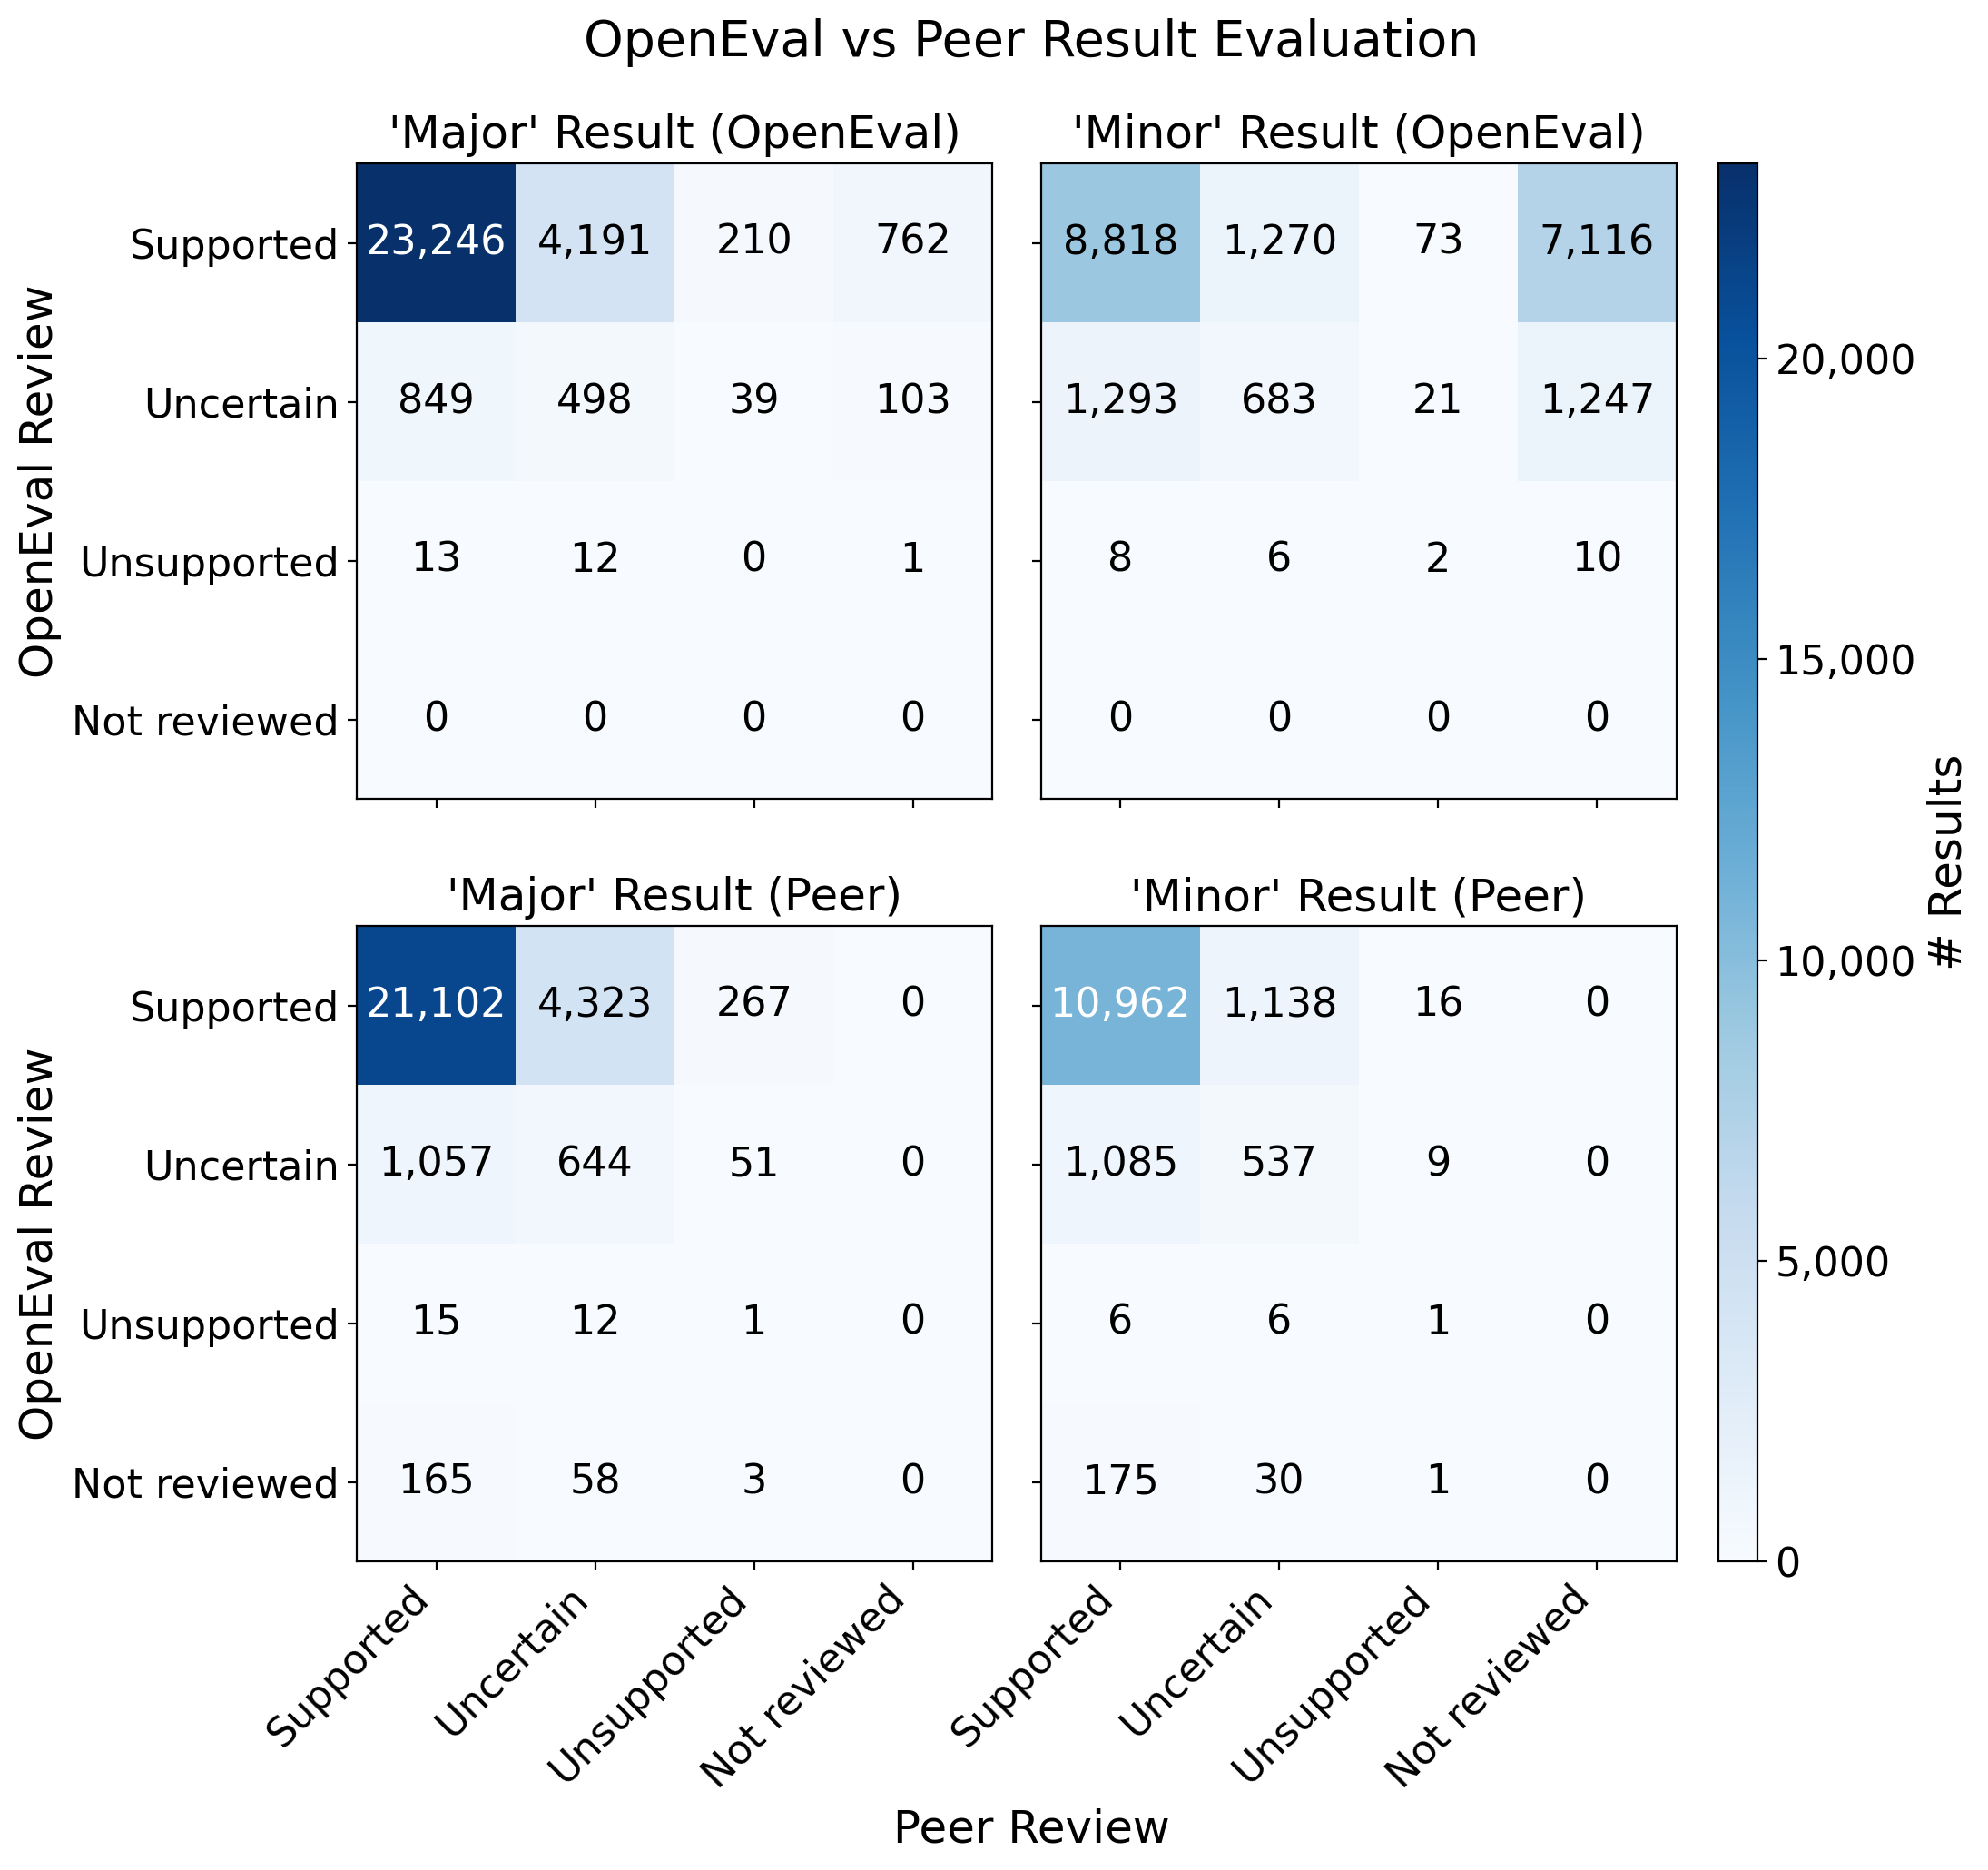

In [19]:
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# Set fontsize for all relevant plot elements
# ----------------------------
fontsize = 18

# ----------------------------
# Figure geometry (4 panels: 2 top, 2 bottom)
# ----------------------------
single_width = 6.3
single_height = 6.3
wspace_fraction = 0.08
hspace_fraction = 0.2

# We'll use 2 rows x 2 cols plus a column for the colorbar
cbar_frac = 0.06
fig_cols = [1, 1, cbar_frac]  # panel, panel, cbar
fig_rows = [1, 1]             # top, bottom

fig_conf = plt.figure(figsize=(10, 10))

gs = fig_conf.add_gridspec(
    2, 3,     # 2 rows, 3 cols (panels left to right, cbar rightmost)
    width_ratios=fig_cols,
    height_ratios=fig_rows,
    wspace=wspace_fraction,
    hspace=hspace_fraction
)

# Share x axes in top and bottom rows
ax0 = fig_conf.add_subplot(gs[0,0])
ax1 = fig_conf.add_subplot(gs[0,1], sharey=ax0, sharex=ax0)
ax2 = fig_conf.add_subplot(gs[1,0], sharex=ax0)
ax3 = fig_conf.add_subplot(gs[1,1], sharey=ax2, sharex=ax0)
cax = fig_conf.add_subplot(gs[:,2])  # cbar spans both rows

axes_conf = [ax0, ax1, ax2, ax3]

# ----------------------------
# Masks ("row/col selectors")
# ----------------------------
oe_major_mask  = df_cmp["openeval_result_type"] == "MAJOR"
oe_minor_mask  = df_cmp["openeval_result_type"] == "MINOR"
peer_major_mask  = df_cmp["peer_result_type"] == "MAJOR"
peer_minor_mask  = df_cmp["peer_result_type"] == "MINOR"

# ----------------------------
# Build conf mats first to share a single normalization
# Top row: split by OpenEval result type
# Bottom row: split by Peer result type
# ----------------------------
conf_mats = []
for mask in [oe_major_mask, oe_minor_mask]:
    conf_mat = (
        pd.crosstab(
            df_cmp.loc[mask, "peer_evaluation_type"],
            df_cmp.loc[mask, "openeval_evaluation_type"]
        )
        .reindex(index=ordered_statuses, columns=ordered_statuses, fill_value=0)
    )
    conf_mats.append(conf_mat)
for mask in [peer_major_mask, peer_minor_mask]:
    conf_mat = (
        pd.crosstab(
            df_cmp.loc[mask, "peer_evaluation_type"],
            df_cmp.loc[mask, "openeval_evaluation_type"]
        )
        .reindex(index=ordered_statuses, columns=ordered_statuses, fill_value=0)
    )
    conf_mats.append(conf_mat)

# ----------------------------
# Use a common vmin/vmax so all plots + colorbar share one scale
# ----------------------------
vmin = 0
vmax = max(cm.to_numpy().max() for cm in conf_mats)

white_text_threshold = vmax * 0.4

# ----------------------------
# Plot all panels
# ----------------------------
panel_titles = [
    "'Major' Result (OpenEval)", "'Minor' Result (OpenEval)",
    "'Major' Result (Peer)", "'Minor' Result (Peer)"
]
ims = []

for idx, (ax_conf, conf_mat, title) in enumerate(zip(axes_conf, conf_mats, panel_titles)):
    im = ax_conf.imshow(
        conf_mat.T, cmap="Blues", aspect="equal", vmin=vmin, vmax=vmax
    )
    ims.append(im)
    ax_conf.set_title(title, fontsize=fontsize)
    # No per-panel xlabel, xlabels on outer panels only
    ax_conf.set_xlabel("") 
    ax_conf.set_xticks(range(len(ordered_statuses)))
    ax_conf.set_yticks(range(len(ordered_statuses)))
    # Remove xticklabels on the top row
    if idx in [0, 1]:
        ax_conf.set_xticklabels([])
        # Explicitly remove xtick labels (also disables minor/xaxis "lines" labels)
        ax_conf.tick_params(axis='x', which='both', labelbottom=False)
    elif idx in [2,3]:
        ax_conf.set_xticklabels(
            ordered_statuses, rotation=45, ha="right", fontsize=fontsize-2
        )
    ax_conf.set_yticklabels(ordered_statuses, fontsize=fontsize-2)
    # annotations: white text for high values (dark background), black otherwise
    data = conf_mat.to_numpy().T
    for i in range(len(ordered_statuses)):
        for j in range(len(ordered_statuses)):
            val = conf_mat.iloc[j, i]
            text_color = (
                "white" if data[i, j] >= white_text_threshold and data[i, j] > 0 else "black"
            )
            ax_conf.text(
                j, i, f"{val:,}", ha="center", va="center",
                color=text_color, fontsize=fontsize-2
            )
    ax_conf.set_aspect("equal", adjustable="box")

axes_conf[0].set_ylabel("OpenEval Review", fontsize=fontsize)
axes_conf[2].set_ylabel("OpenEval Review", fontsize=fontsize)
plt.setp(axes_conf[1].get_yticklabels(), visible=False)
plt.setp(axes_conf[3].get_yticklabels(), visible=False)

# Only set x axis label on outer bottom, and share x axes
fig_conf.supxlabel("Peer Review", fontsize=fontsize, y=-0.05)

# ----------------------------
# Colorbar (shared)
# ----------------------------
cbar = fig_conf.colorbar(ims[0], cax=cax)
cbar.set_label("# Results", fontsize=fontsize)
cbar.formatter = mticker.FuncFormatter(lambda x, _: f"{int(x):,}" if x == int(x) else f"{x:,}")
cbar.update_ticks()
cbar.ax.tick_params(labelsize=fontsize-2)

fig_conf.suptitle("OpenEval vs Peer Result Evaluation", fontsize=fontsize+2, y=0.96)

fig_conf.savefig("figures/1_evals_confusion_matrix_major_minor_split_by_both.png", dpi=300, bbox_inches="tight")
plt.show()


Plot MAJOR/MINOR agreement:

MAJOR/MINOR result type agreement (excluding Not Reviewed):
  N results compared: 41,232
  Agreement: 32,320 (78.4%)
  Disagreement: 8,912 (21.6%)


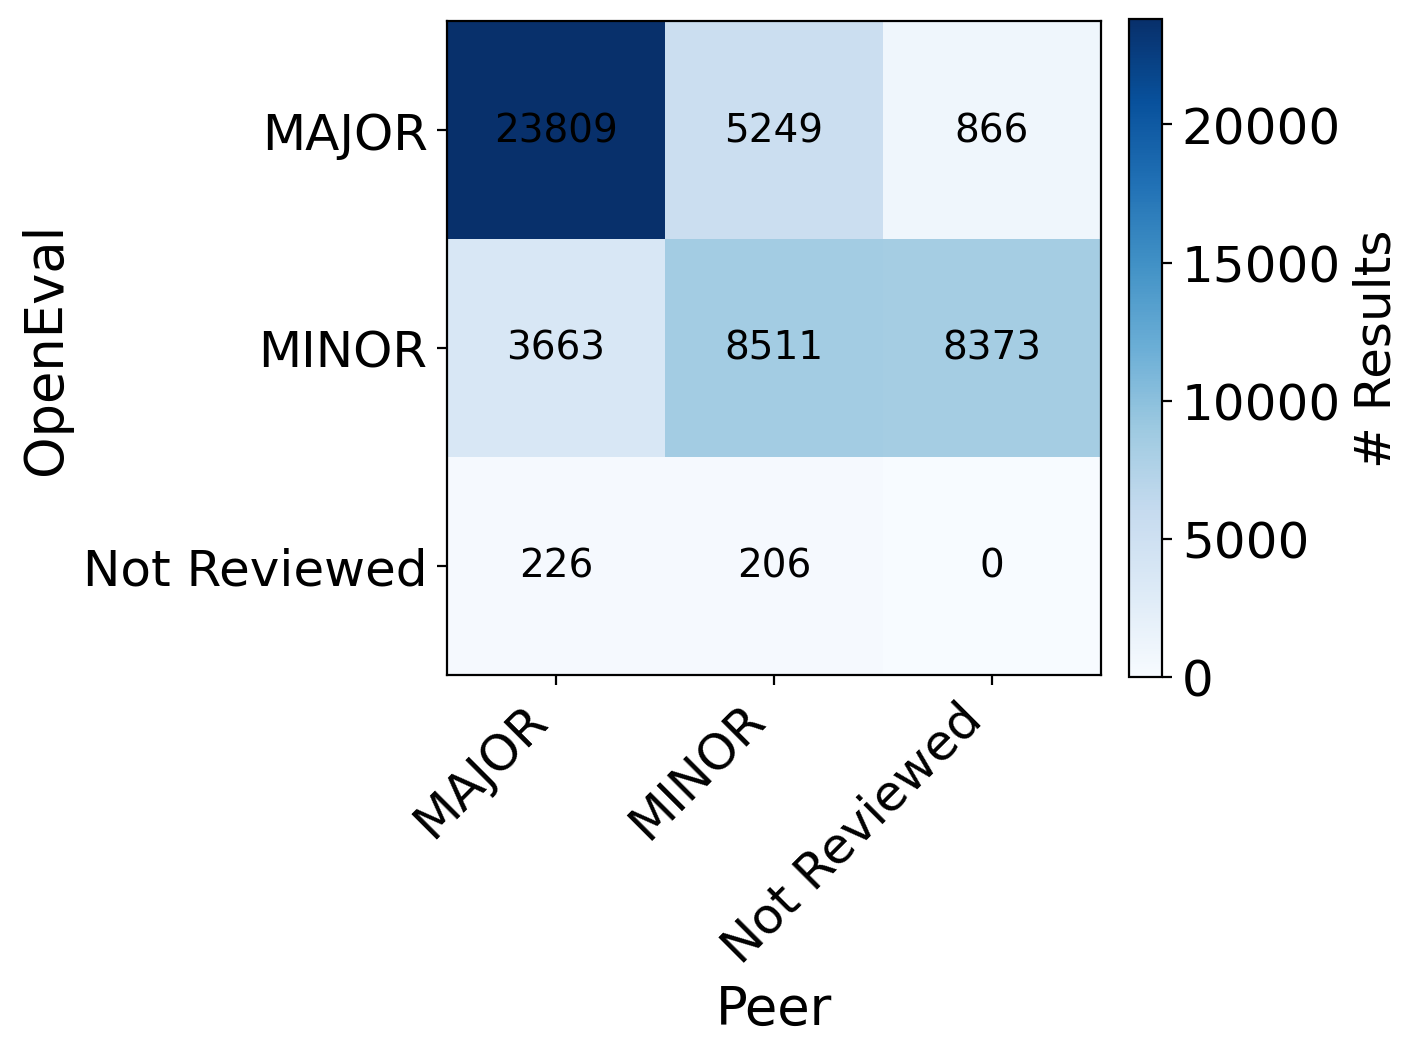

In [20]:
# Compute and print percentage agreement/disagreement (not including "Not Reviewed")
result_types = ["MAJOR", "MINOR"]

df_agree_stats = df_cmp[
    df_cmp["openeval_result_type"].isin(result_types) &
    df_cmp["peer_result_type"].isin(result_types)
]

n_total = len(df_agree_stats)
n_agreematch = (df_agree_stats["openeval_result_type"] == df_agree_stats["peer_result_type"]).sum()
n_disagree = n_total - n_agreematch

perc_agree = 100 * n_agreematch / n_total if n_total > 0 else 0
perc_disagree = 100 * n_disagree / n_total if n_total > 0 else 0

print(f"MAJOR/MINOR result type agreement (excluding Not Reviewed):")
print(f"  N results compared: {n_total:,}")
print(f"  Agreement: {n_agreematch:,} ({perc_agree:.1f}%)")
print(f"  Disagreement: {n_disagree:,} ({perc_disagree:.1f}%)")

# (Optional: Keep the joint confusion matrix for full context, if desired)
# Identify result types with NA as "Not Reviewed"
result_types_3 = ["MAJOR", "MINOR", "Not Reviewed"]

def fill_na_types(col):
    return col.where(col.isin(["MAJOR", "MINOR"]), "Not Reviewed")

peer_type = fill_na_types(df_cmp["peer_result_type"])
openeval_type = fill_na_types(df_cmp["openeval_result_type"])

confusion = pd.crosstab(
    openeval_type,
    peer_type,
    rownames=["OpenEval result type"],
    colnames=["Peer result type"],
    dropna=False
).reindex(index=result_types_3, columns=result_types_3, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(confusion, cmap="Blues", vmin=0)

# Annotate with counts
for i in range(len(result_types_3)):
    for j in range(len(result_types_3)):
        value = confusion.iloc[i, j]
        ax.text(j, i, value, ha="center", va="center", color="black", fontsize=14)

ax.set_xticks(range(len(result_types_3)))
ax.set_yticks(range(len(result_types_3)))
ax.set_xticklabels(result_types_3, fontsize=fontsize, rotation=45, ha="right")
ax.set_yticklabels(result_types_3, fontsize=fontsize)
ax.set_xlabel("Peer", fontsize=fontsize+1)
ax.set_ylabel("OpenEval", fontsize=fontsize+1)
plt.tight_layout()
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label("# Results", fontsize=fontsize)
fig.savefig("figures/1_major_minor_notreviewed_heatmap_overall.png", dpi=300, bbox_inches="tight")
plt.show()

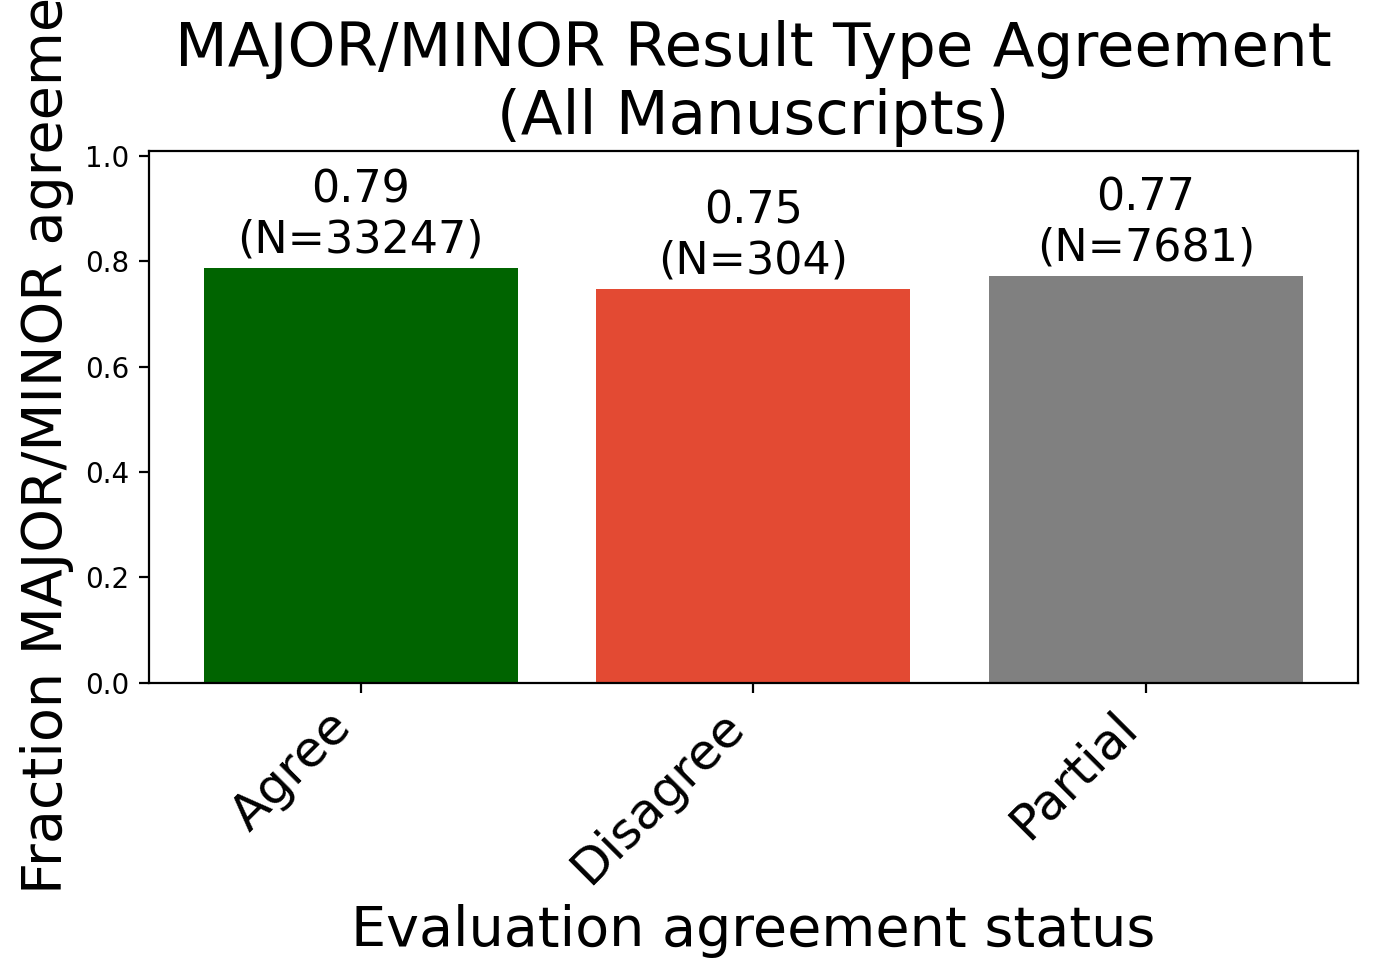

In [21]:
# Plot fraction agreement of MAJOR/MINOR between openeval and peer, per comparison_type

# Drop rows where either result_type is None (i.e., keep only MAJOR/MINOR)
df_types = df_cmp.dropna(subset=["openeval_result_type", "peer_result_type"])
df_types = df_types[
    df_types["openeval_result_type"].isin(["MAJOR", "MINOR"]) &
    df_types["peer_result_type"].isin(["MAJOR", "MINOR"])
]

# For each comparison_type, calculate the fraction where openeval_result_type == peer_result_type
type_agree = (
    df_types.assign(is_agree = lambda d: d["openeval_result_type"] == d["peer_result_type"])
    .groupby("comparison_type")["is_agree"]
    .agg(['mean', 'count'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(type_agree["comparison_type"], type_agree["mean"], color=[colors.get(ct, "gray") for ct in type_agree["comparison_type"]])
ax.set_ylim(0, 1.01)
ax.set_ylabel("Fraction MAJOR/MINOR agreement", fontsize=fontsize+2)
ax.set_xlabel("Evaluation agreement status", fontsize=fontsize+2)
ax.set_title("MAJOR/MINOR Result Type Agreement\n(All Manuscripts)", fontsize=fontsize+4)
ax.set_xticks(range(len(type_agree["comparison_type"])))
ax.set_xticklabels(type_agree["comparison_type"], rotation=45, ha="right", fontsize=fontsize)
for i, row in type_agree.iterrows():
    ax.text(i, row['mean']+0.03, f"{row['mean']:.2f}\n(N={row['count']})", ha="center", fontsize=fontsize-2)
plt.tight_layout()
fig.savefig("figures/major_minor_agreement_by_comptype_all.png", dpi=300, bbox_inches="tight")
plt.show()

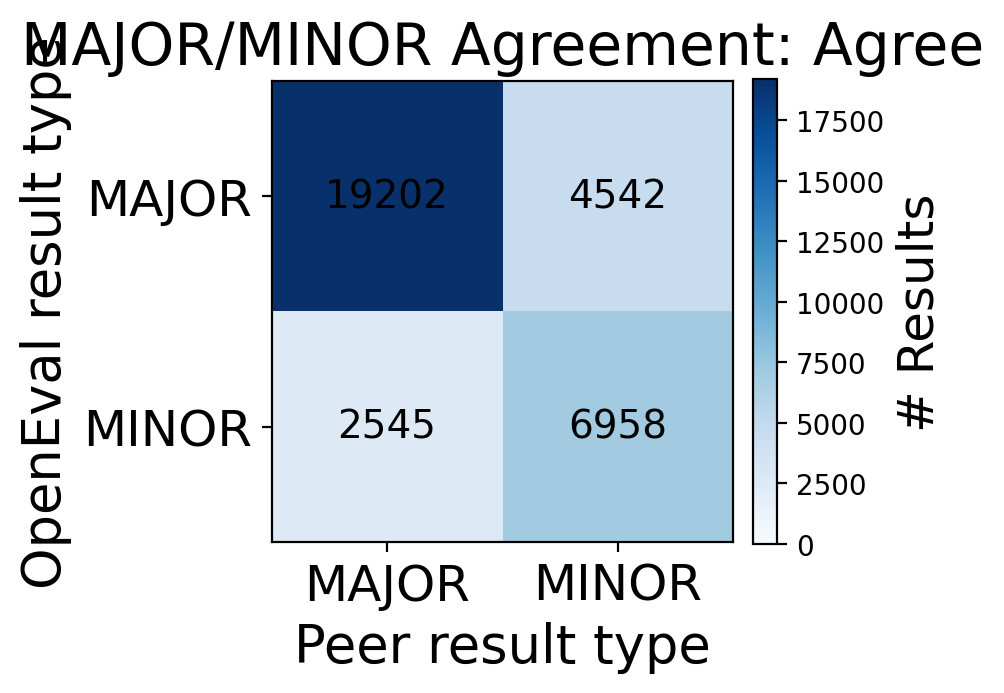

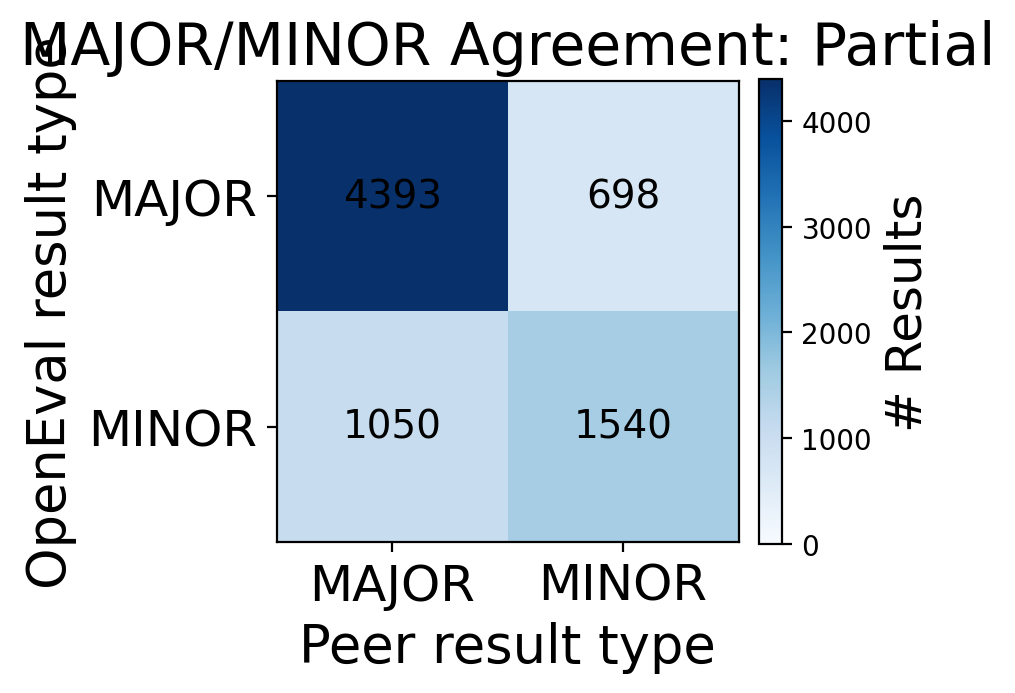

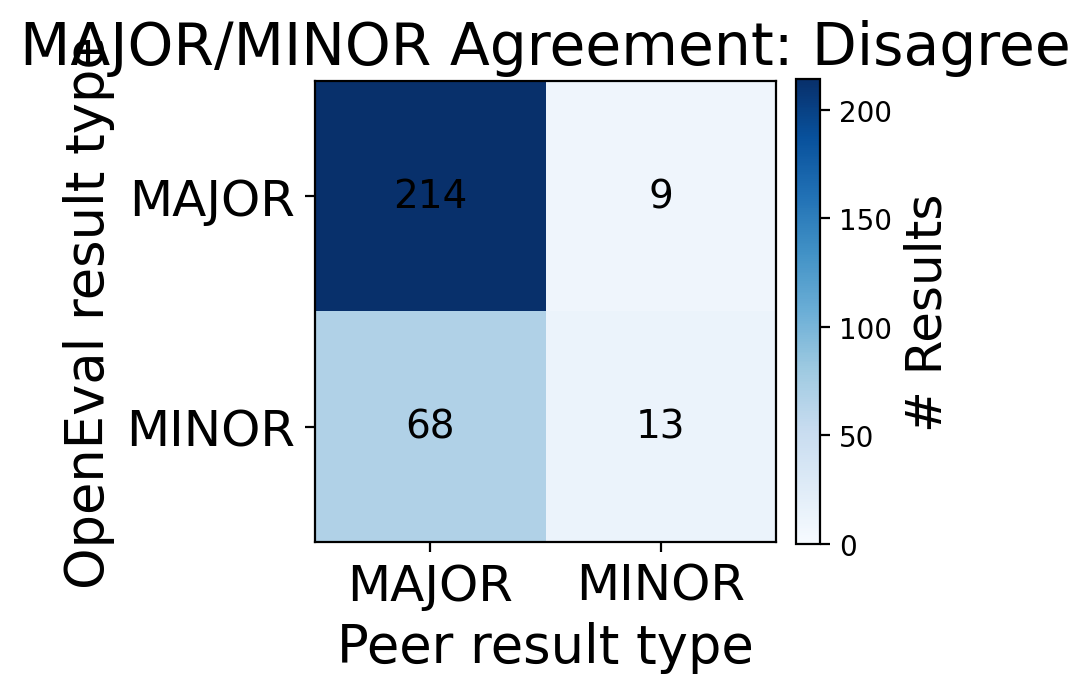

In [22]:
# Plot a heatmap of MAJOR/MINOR agreement for each comparison_type

# Drop rows where either result_type is None (i.e., keep only MAJOR/MINOR)
df_types = df_cmp.dropna(subset=["openeval_result_type", "peer_result_type"])
df_types = df_types[
    df_types["openeval_result_type"].isin(["MAJOR", "MINOR"]) &
    df_types["peer_result_type"].isin(["MAJOR", "MINOR"])
]

comparison_types_order = ["Agree", "Partial", "Disagree"]
result_types = ["MAJOR", "MINOR"]

for comparison_type in comparison_types_order:
    df_ct = df_types[df_types["comparison_type"] == comparison_type]

    confusion = pd.crosstab(
        df_ct["openeval_result_type"],
        df_ct["peer_result_type"],
        rownames=["OpenEval result type"],
        colnames=["Peer result type"],
        dropna=False
    ).reindex(index=result_types, columns=result_types, fill_value=0)

    fig, ax = plt.subplots(figsize=(4, 3.8))
    im = ax.imshow(confusion, cmap="Blues", vmin=0)

    # Annotate
    for i in range(len(result_types)):
        for j in range(len(result_types)):
            value = confusion.iloc[i, j]
            ax.text(j, i, value, ha="center", va="center", color="black", fontsize=14)

    ax.set_xticks(range(len(result_types)))
    ax.set_yticks(range(len(result_types)))
    ax.set_xticklabels(result_types, fontsize=fontsize)
    ax.set_yticklabels(result_types, fontsize=fontsize)
    ax.set_xlabel("Peer result type", fontsize=fontsize+1)
    ax.set_ylabel("OpenEval result type", fontsize=fontsize+1)
    ax.set_title(f"MAJOR/MINOR Agreement: {comparison_type}", fontsize=fontsize+3)
    plt.tight_layout()
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("# Results", fontsize=fontsize)
    fig.savefig(f"figures/major_minor_heatmap_{comparison_type.lower()}_all.png", dpi=300, bbox_inches="tight")
    plt.show()

Plot # claims per result by agreement status:

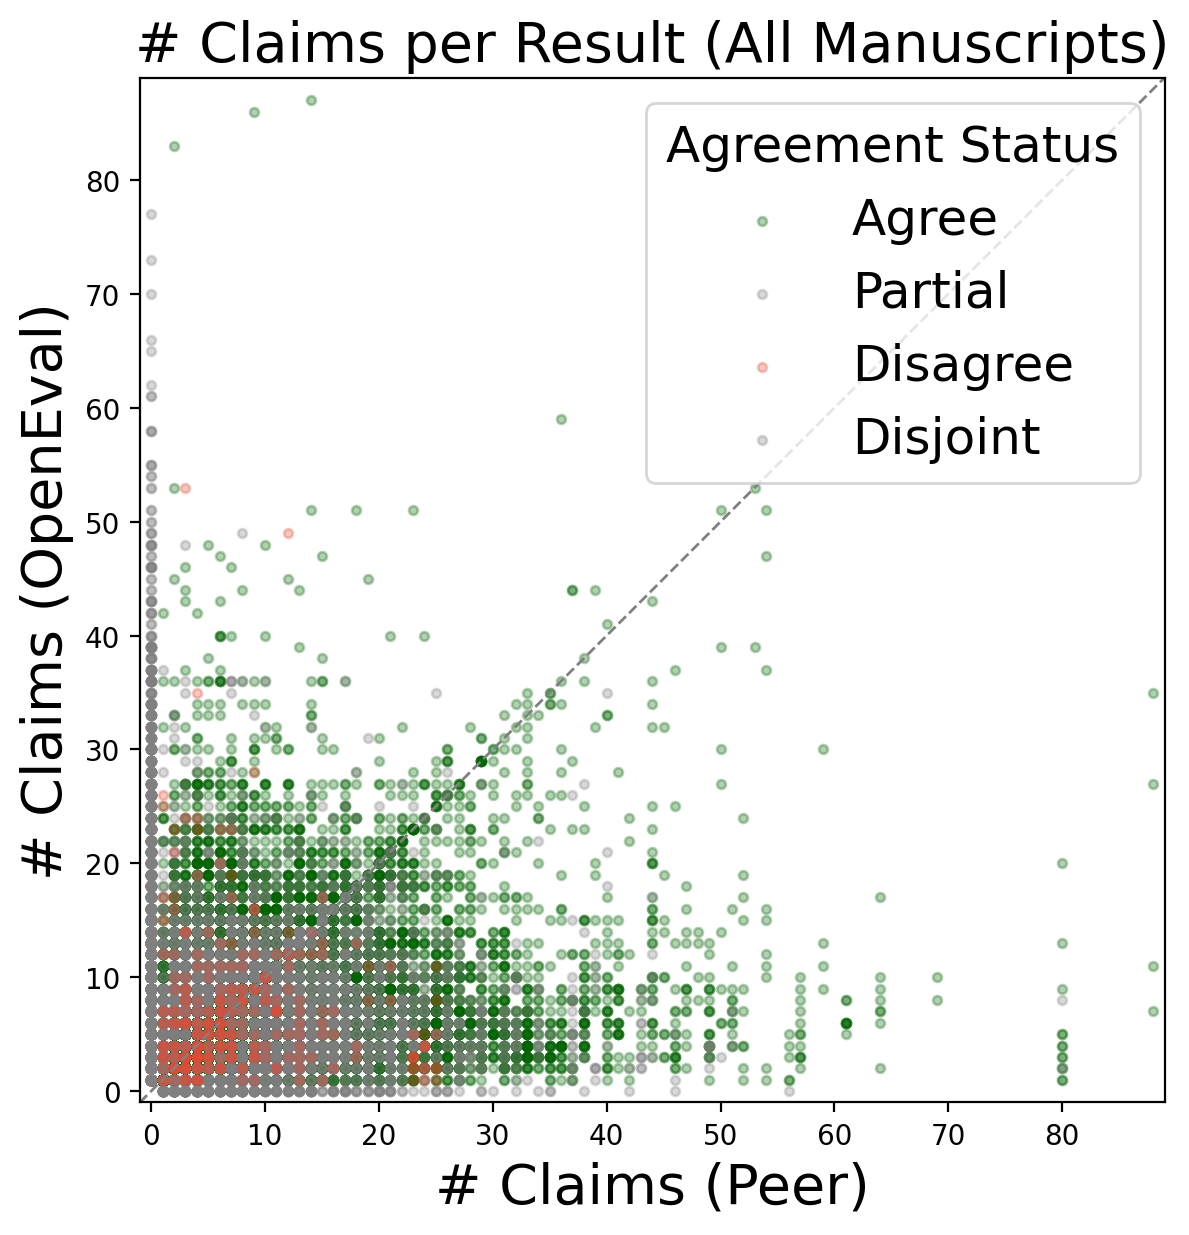

In [23]:
fig_scatter, ax_scatter = plt.subplots(figsize=(6.3, 6.3), sharey=True, sharex=True)
for status in desired_agree_order:
    group = df_cmp[df_cmp["comparison_type"] == status]
    if not group.empty:
        ax_scatter.scatter(
            group["n_peer_int"], group["n_openeval_int"], s=10,
            label=status, color=colors.get(status, "gray"),
            alpha=0.3
        )
min_val = min(df_cmp["n_peer_int"].min(), df_cmp["n_openeval_int"].min())
max_val = max(df_cmp["n_peer_int"].max(), df_cmp["n_openeval_int"].max())
xlim = (-1, max_val + 1)
ylim = (-1, max_val + 1)
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_scatter.set_aspect('equal', adjustable='box')
line_min = min(xlim[0], ylim[0])
line_max = max(xlim[1], ylim[1])
ax_scatter.plot([line_min, line_max], [line_min, line_max], "--", color="gray", lw=1, zorder=1)
ax_scatter.set_title("# Claims per Result (All Manuscripts)", fontsize=fontsize+2)
ax_scatter.set_xlabel("# Claims (Peer)", fontsize=fontsize+2)
ax_scatter.set_ylabel("# Claims (OpenEval)", fontsize=fontsize+2)

# xticks = yticks = range(int(line_min), int(line_max) + 1)
# def hide_minus1_ticklabels(ticks):
#     return ['' if str(tick) == '-1' else str(tick) for tick in ticks]
# ax_scatter.set_xticks(xticks)
# ax_scatter.set_yticks(yticks)
# ax_scatter.set_xticklabels(hide_minus1_ticklabels(xticks), fontsize=fontsize-2)
# ax_scatter.set_yticklabels(hide_minus1_ticklabels(yticks), fontsize=fontsize-2)
# ax_scatter.set_xscale("symlog")
# ax_scatter.set_yscale("symlog")

ax_scatter.legend(title="Agreement Status", fontsize=fontsize, title_fontsize=fontsize, loc="best")
plt.tight_layout()

fig_scatter.savefig("figures/claims_per_result_scatter_all.png", dpi=300, bbox_inches='tight')
plt.show()

Jaccard Index:

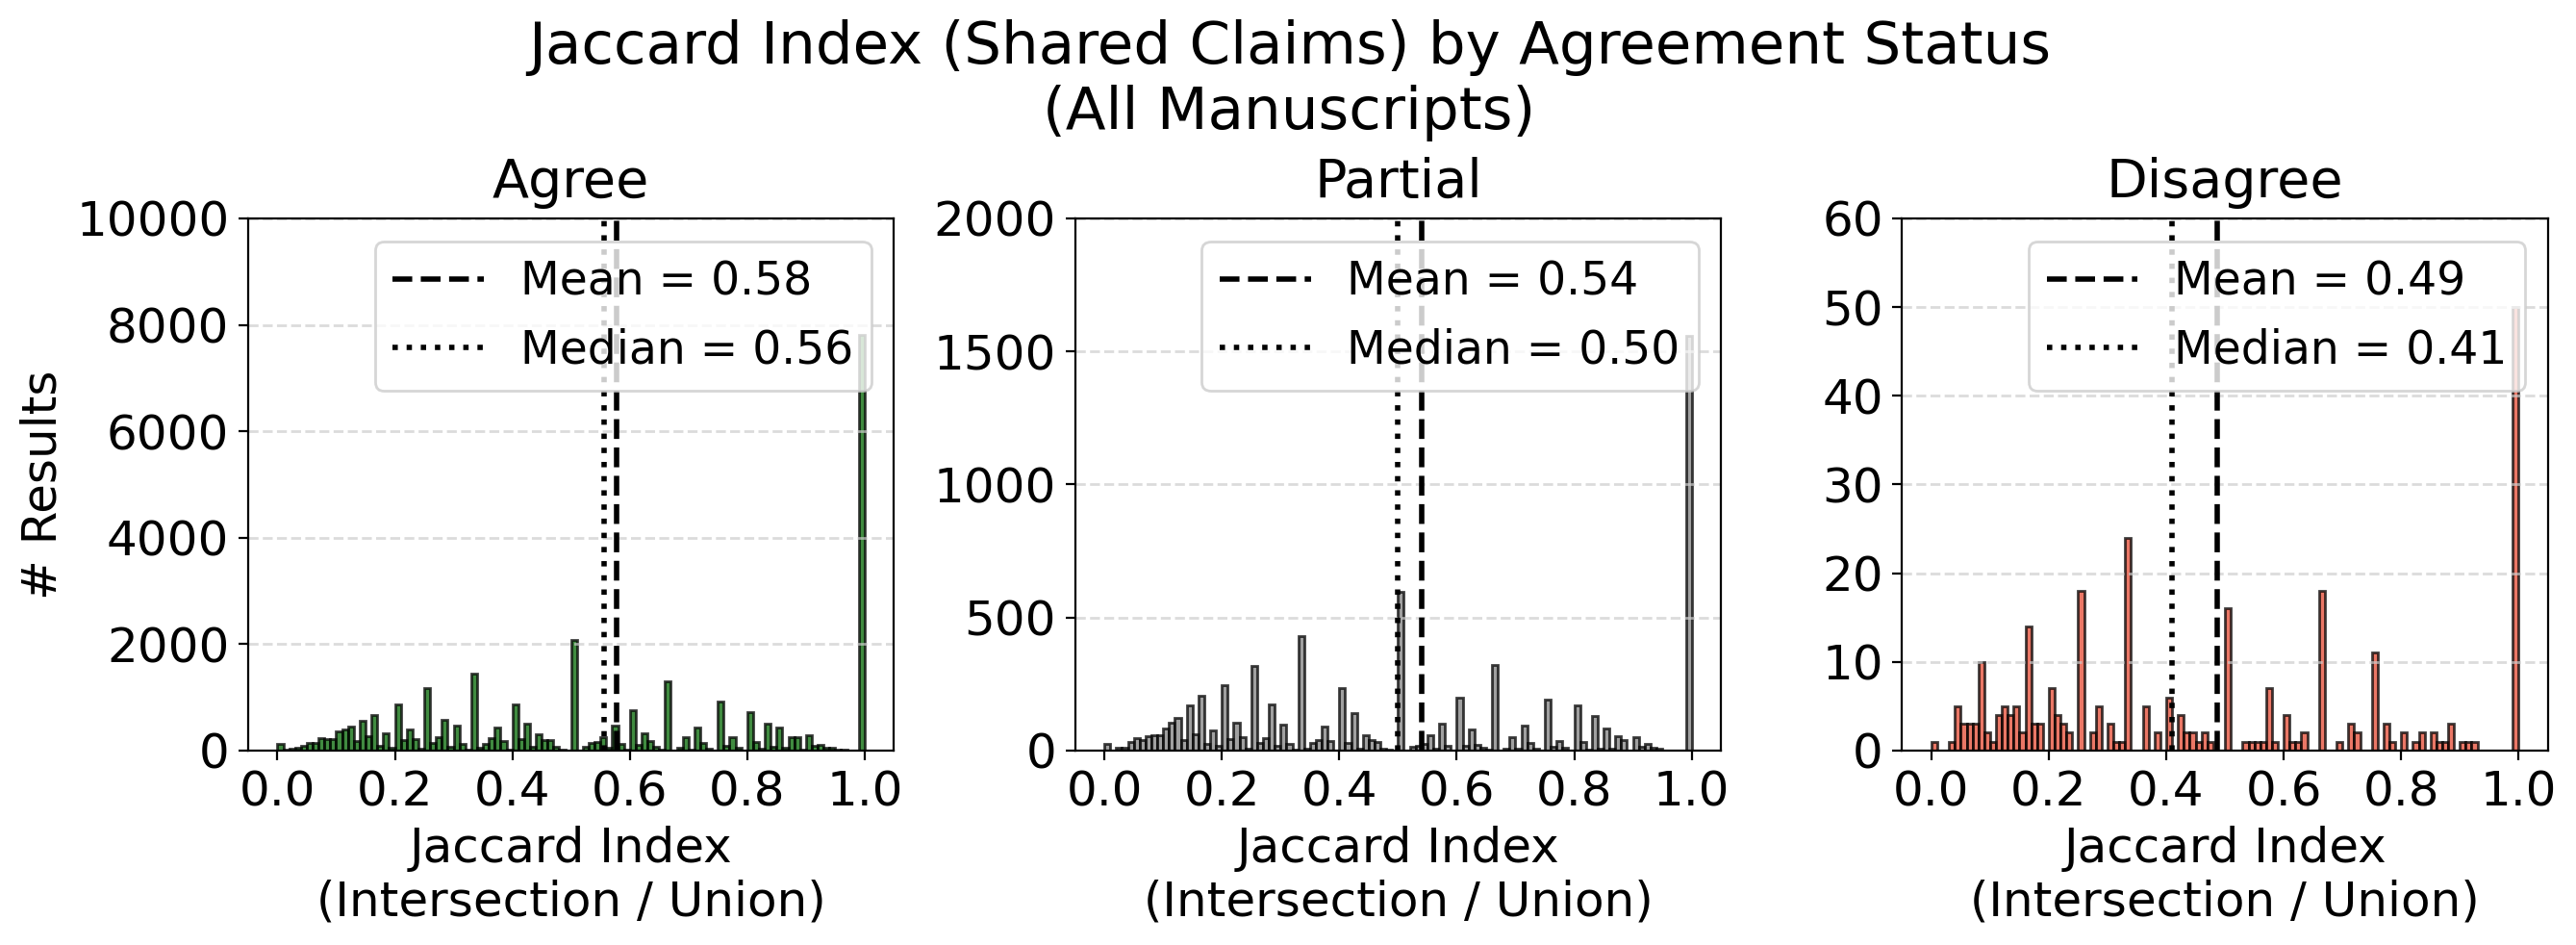

In [24]:
mask = (~df_cmp["n_peer"].isna()) & (~df_cmp["n_openeval"].isna())
df_overlap = df_cmp[mask].reset_index(drop=True)
all_statuses = ["Agree", "Partial", "Disagree"]
df_overlap = df_overlap[df_overlap["comparison_type"].isin(all_statuses)].reset_index(drop=True)
bins = np.arange(0, 1.01, 0.01)
fig_hist, axes_hist = plt.subplots(
    1, 3, figsize=(13.5, 4.5), sharey=False
)
if not isinstance(axes_hist, np.ndarray):
    axes_hist = np.array([axes_hist])
for idx, status in enumerate(all_statuses):
    subset = df_overlap[df_overlap["comparison_type"] == status]
    counts, bin_edges, _ = axes_hist[idx].hist(
        subset["intersection_fraction"], bins=bins, alpha=0.75,
        color=status_colors.get(status, "gray"),
        edgecolor="black"
    )
    mean_value = subset["intersection_fraction"].mean()
    median_value = subset["intersection_fraction"].median()
    axes_hist[idx].axvline(mean_value, color="k", linestyle="--", linewidth=2, label=f"Mean = {mean_value:.2f}")
    axes_hist[idx].axvline(median_value, color="k", linestyle=":", linewidth=2, label=f"Median = {median_value:.2f}")
    axes_hist[idx].set_title(f"{status}", fontsize=fontsize+2, pad=8)
    axes_hist[idx].set_xlabel("Jaccard Index\n(Intersection / Union)", fontsize=fontsize)
    axes_hist[idx].set_xticks(np.arange(0, 1.01, 0.2))
    axes_hist[idx].set_xticklabels([f"{b:.1f}" for b in np.arange(0, 1.01, 0.2)], fontsize=fontsize)
    axes_hist[idx].grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
    axes_hist[idx].tick_params(axis="both", labelsize=fontsize)
    yticks = axes_hist[idx].get_yticks()
    int_yticks = yticks[np.abs(yticks - np.round(yticks)) < 1e-6]
    if len(int_yticks) > 0:
        axes_hist[idx].set_yticks(int_yticks)
        axes_hist[idx].set_yticklabels([str(int(y)) for y in int_yticks], fontsize=fontsize)
    else:
        axes_hist[idx].set_yticklabels([str(int(y)) for y in yticks], fontsize=fontsize)
    if idx == 0:
        axes_hist[idx].set_ylabel("# Results", fontsize=fontsize)
    axes_hist[idx].legend(fontsize=fontsize-1, loc="upper right")
fig_hist.suptitle("Jaccard Index (Shared Claims) by Agreement Status\n(All Manuscripts)", fontsize=fontsize+4, y=1.08)
plt.tight_layout()
fig_hist.subplots_adjust(top=0.85)

fig_hist.savefig("figures/jaccard_index_histograms_by_status_all.png", dpi=300, bbox_inches="tight")

plt.show()

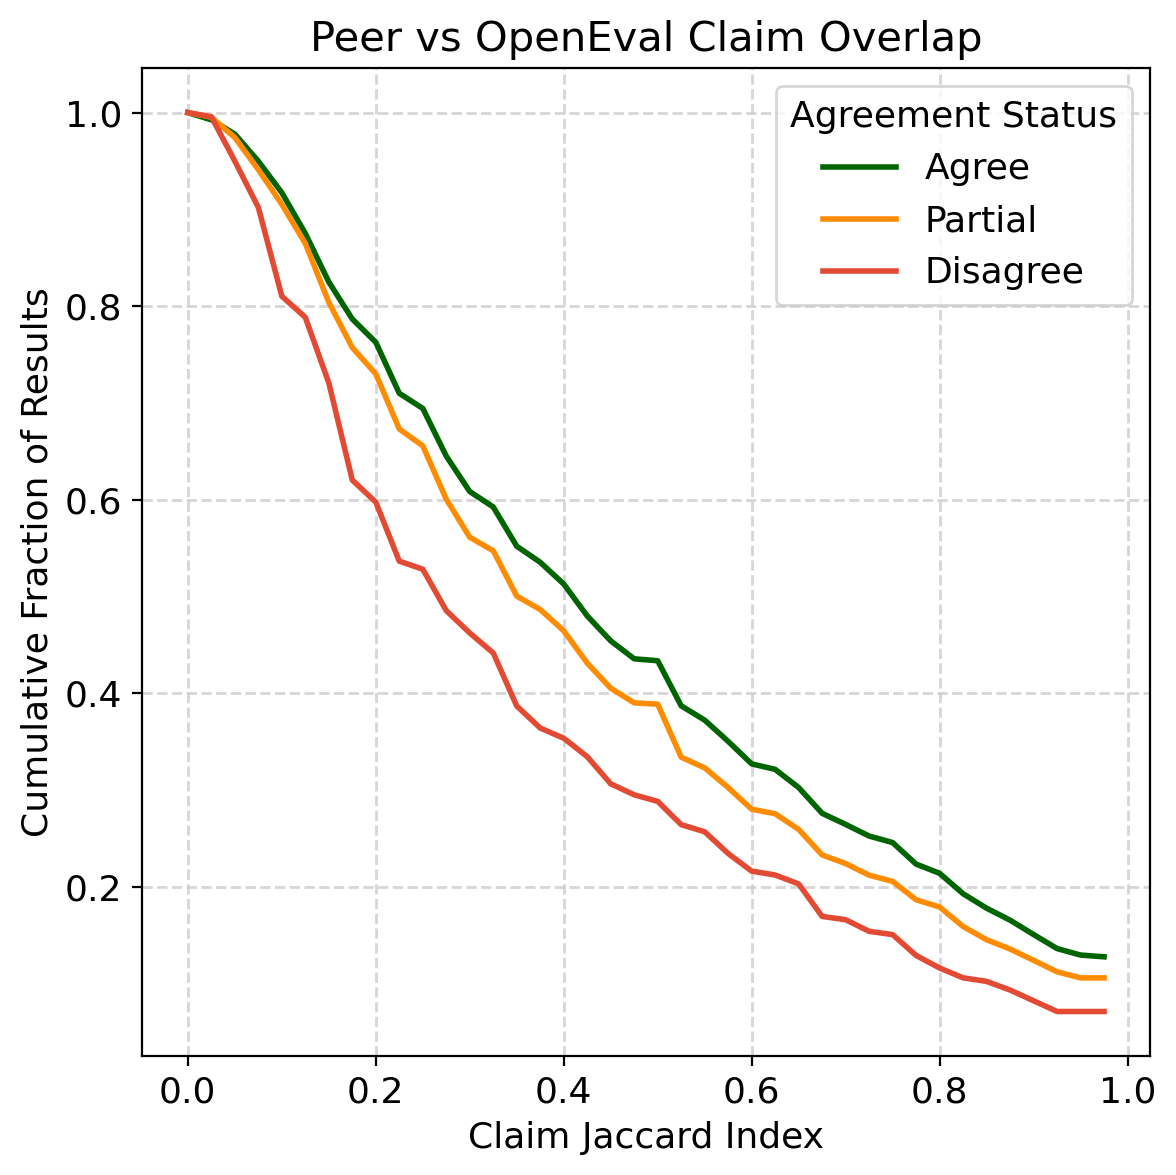

In [25]:
# Cumulative Knee plot: Jaccard index (x) vs cumulative fraction of results (union, y), with 3 lines by status

fontsize = 13  # Use this fontsize for all axis labels, ticklabels, and titles

mask = (~df_cmp["n_peer"].isna()) & (~df_cmp["n_openeval"].isna())
df_overlap = df_cmp[mask].reset_index(drop=True)
all_statuses = ["Agree", "Partial", "Disagree"]
df_overlap = df_overlap[df_overlap["comparison_type"].isin(all_statuses)].reset_index(drop=True)
# Calculate union (number of unique claims for peer or openeval result)
df_overlap["n_union"] = df_overlap["n_peer"].fillna(0) + df_overlap["n_openeval"].fillna(0) - (df_overlap["n_itx"].fillna(0))

fig, ax = plt.subplots(figsize=(6, 6))
bins = np.arange(0, 1.01, 0.025)

for status in all_statuses:
    subset = df_overlap[df_overlap["comparison_type"] == status].copy()
    n_total_union = subset["n_union"].sum()
    # Digitize Jaccard index into bins
    # For cumulative: for each bin, sum n_union for all rows with intersection_fraction >= lower edge of that bin
    cumulative_fractions = []
    for i in range(len(bins) - 1):
        lower = bins[i]
        # Select all results with Jaccard >= lower
        mask_cum = subset["intersection_fraction"] >= lower
        n_cumulative = subset.loc[mask_cum, "n_union"].sum()
        frac_cumulative = n_cumulative / n_total_union if n_total_union > 0 else 0
        cumulative_fractions.append(frac_cumulative)
    # Set color using the colors dict as defined earlier
    if status == "Agree":
        plot_color = colors.get("Agree", "gray")
    elif status == "Partial":
        plot_color = colors.get("Partial:OpenEvalUncertain", "orange")  # Use OpenEvalUncertain as default for Partial
    elif status == "Disagree":
        plot_color = colors.get("Disagree", "#e34a33")
    else:
        plot_color = "gray"
    ax.plot(
        bins[:-1],
        cumulative_fractions,
        label=status,
        color=plot_color,
        linewidth=2
    )

ax.set_xlabel("Claim Jaccard Index", fontsize=fontsize)
ax.set_ylabel("Cumulative Fraction of Results", fontsize=fontsize)
ax.set_title("Peer vs OpenEval Claim Overlap", fontsize=fontsize+2)
ax.legend(title="Agreement Status", fontsize=fontsize, title_fontsize=fontsize)
ax.grid(True, linestyle="--", color="#cccccc", linewidth=1, alpha=0.8, zorder=0)
ax.tick_params(axis="both", labelsize=fontsize)
plt.tight_layout()
fig.savefig("figures/1_claim_overlap_kneeplot_by_agreement.png", dpi=300, bbox_inches="tight")
plt.show()

Summary table:

In [26]:
summary = df_cmp.copy()
summary["comparison_type"] = summary["comparison_type"].astype(str).str.capitalize()
summary = summary.groupby("comparison_type").agg({
    "openeval_result_id": "count",
    "n_openeval": "mean", 
    "n_peer": "mean",
    "n_itx": "mean",
    "intersection_fraction": "mean"
}).rename(columns={"opneval_result_id": "n_results"}).reindex(desired_agree_order)
print("\nSummary statistics (all manuscripts):")
display(summary.round(2))



Summary statistics (all manuscripts):


,openeval_result_id,n_openeval,n_peer,n_itx,intersection_fraction
comparison_type,,,,,
Agree,33247,6.61,8.71,4.76,0.58
Partial,7681,6.03,7.82,4.05,0.54
Disagree,304,6.85,7.48,3.65,0.49
Disjoint,9239,6.51,7.61,0.00,0.00


In [27]:
# Get the paper number(s) where agreement_status is "Disagree"
disagree_papers = df_cmp[df_cmp["comparison_type"].str.lower() == "disagree"]["manuscript_id"].unique()
print("Paper numbers where agreement_status == 'Disagree':", disagree_papers)
len(disagree_papers)

Paper numbers where agreement_status == 'Disagree': ['elife-90465' 'elife-90668' 'elife-107419' 'elife-90695' 'elife-105347'
 'elife-91528' 'elife-96904' 'elife-92562' 'elife-101724' 'elife-91985'
 'elife-93241' 'elife-88638' 'elife-88855' 'elife-96445' 'elife-97335'
 'elife-90325' 'elife-95453' 'elife-90724' 'elife-100914' 'elife-102475'
 'elife-87356' 'elife-87369' 'elife-96812' 'elife-89601' 'elife-96848'
 'elife-95857' 'elife-99200' 'elife-98584' 'elife-97958' 'elife-100337'
 'elife-87115' 'elife-90532' 'elife-95272' 'elife-91289' 'elife-98903'
 'elife-95412' 'elife-89214' 'elife-90762' 'elife-102637' 'elife-92493'
 'elife-102433' 'elife-96691' 'elife-89017' 'elife-95880' 'elife-87928'
 'elife-92069' 'elife-89613' 'elife-106469' 'elife-98766' 'elife-90309'
 'elife-102852' 'elife-98351' 'elife-95229' 'elife-92457' 'elife-92525'
 'elife-96515' 'elife-93636' 'elife-100446' 'elife-95709' 'elife-89958'
 'elife-88614' 'elife-86944' 'elife-105504' 'elife-100071' 'elife-98073'
 'elife-8697

146

In [28]:
df_cmp.columns

Index(['comparison_id', 'openeval_result_id', 'peer_result_id',
       'openeval_evaluation_type', 'peer_evaluation_type',
       'openeval_result_type', 'peer_result_type', 'comparison_type',
       'comparison', 'n_openeval', 'n_peer', 'n_itx', 'manuscript_id',
       'version', 'intersection_fraction', 'n_peer_int', 'n_openeval_int',
       'agree_bar_cat'],
      dtype='object')

In [29]:
# Get all instances where openeval_evaluation_type == 'Supported' and peer_evaluation_type == 'Not supported', or vice versa.
agree_disagree = df_cmp[
    ((df_cmp["openeval_evaluation_type"].str.lower() == "supported") & (df_cmp["peer_evaluation_type"].str.lower() == "unsupported")) |
    ((df_cmp["openeval_evaluation_type"].str.lower() == "unsupported") & (df_cmp["peer_evaluation_type"].str.lower() == "supported"))
]
print("Instances where one status is Supported and the other is Not supported:")
display(agree_disagree)
print(f"Number of such instances: {len(agree_disagree)}")
agree_disagree.to_csv("figures/supported_unsupported.csv", index=False)

Instances where one status is Supported and the other is Not supported:


,comparison_id,openeval_result_id,peer_result_id,openeval_evaluation_type,peer_evaluation_type,openeval_result_type,peer_result_type,comparison_type,comparison,n_openeval,n_peer,n_itx,manuscript_id,version,intersection_fraction,n_peer_int,n_openeval_int,agree_bar_cat
148,CMP4,R9,R3,Supported,Unsupported,MAJOR,MAJOR,Disagree,"Both address claims C102, C108 regarding time-...",2.0,3.0,2,elife-90465,v1,0.666667,3,2,Disagree
149,CMP5,R4,R3,Supported,Unsupported,MINOR,MAJOR,Disagree,OpenEval R4 addresses claim C61 about noise ob...,1.0,3.0,1,elife-90465,v1,0.333333,3,1,Disagree
372,CMP3,R13,R7,Supported,Unsupported,MAJOR,MAJOR,Disagree,"Major disagreement on main conclusions (C61, C...",2.0,2.0,2,elife-90668,v1,1.000000,2,2,Disagree
422,CMP3,R3,R3,Supported,Unsupported,MAJOR,MAJOR,Disagree,"Both evaluate claims C47-C54, C78, C97 regardi...",10.0,10.0,10,elife-107419,v1,1.000000,10,10,Disagree
1313,CMP3,R5,R3,Supported,Unsupported,MAJOR,MAJOR,Disagree,"Both evaluate the same claims (C6, C47-C49) re...",4.0,4.0,4,elife-90695,v1,1.000000,4,4,Disagree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49394,CMP11,R15,R5,Supported,Unsupported,MAJOR,MAJOR,Disagree,Both evaluate major conclusions about extreme ...,5.0,4.0,3,elife-102542,v1,0.600000,4,5,Disagree
50215,CMP8,R12,R6,Supported,Unsupported,MINOR,MINOR,Disagree,Both address predation/visibility arguments as...,14.0,3.0,3,elife-87008,v1,0.214286,3,14,Disagree
50259,CMP7,R7,R5,Unsupported,Supported,MAJOR,MAJOR,Disagree,Strong disagreement on claim C29. OpenEval rat...,1.0,8.0,1,elife-99790,v1,0.125000,8,1,Disagree
50265,CMP13,R13,R9,Unsupported,Supported,MAJOR,MAJOR,Disagree,Strong disagreement on claims C55-C58 regardin...,4.0,10.0,4,elife-99790,v1,0.400000,10,4,Disagree


Number of such instances: 304


In [30]:
# Get all instances where either says 'Not supported'
agree_unsupported = df_cmp[
    ((df_cmp["openeval_evaluation_type"].str.lower() == "unsupported") | (df_cmp["peer_evaluation_type"].str.lower() == "unsupported"))
]
print("Instances where both say Not supported:")
display(agree_unsupported)
print(f"Number of such instances: {len(agree_unsupported)}")
agree_unsupported.to_csv("figures/either_unsupported.csv", index=False)

Instances where both say Not supported:


,comparison_id,openeval_result_id,peer_result_id,openeval_evaluation_type,peer_evaluation_type,openeval_result_type,peer_result_type,comparison_type,comparison,n_openeval,n_peer,n_itx,manuscript_id,version,intersection_fraction,n_peer_int,n_openeval_int,agree_bar_cat
148,CMP4,R9,R3,Supported,Unsupported,MAJOR,MAJOR,Disagree,"Both address claims C102, C108 regarding time-...",2.0,3.0,2,elife-90465,v1,0.666667,3,2,Disagree
149,CMP5,R4,R3,Supported,Unsupported,MINOR,MAJOR,Disagree,OpenEval R4 addresses claim C61 about noise ob...,1.0,3.0,1,elife-90465,v1,0.333333,3,1,Disagree
372,CMP3,R13,R7,Supported,Unsupported,MAJOR,MAJOR,Disagree,"Major disagreement on main conclusions (C61, C...",2.0,2.0,2,elife-90668,v1,1.000000,2,2,Disagree
422,CMP3,R3,R3,Supported,Unsupported,MAJOR,MAJOR,Disagree,"Both evaluate claims C47-C54, C78, C97 regardi...",10.0,10.0,10,elife-107419,v1,1.000000,10,10,Disagree
1112,CMP15,R14,R8,Unsupported,Uncertain,MINOR,MINOR,Partial,Both address speculative claim C86 about cappi...,1.0,2.0,1,elife-87884,v1,0.500000,2,1,Partial:PeerUncertain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50259,CMP7,R7,R5,Unsupported,Supported,MAJOR,MAJOR,Disagree,Strong disagreement on claim C29. OpenEval rat...,1.0,8.0,1,elife-99790,v1,0.125000,8,1,Disagree
50265,CMP13,R13,R9,Unsupported,Supported,MAJOR,MAJOR,Disagree,Strong disagreement on claims C55-C58 regardin...,4.0,10.0,4,elife-99790,v1,0.400000,10,4,Disagree
50640,CMP13,R14,R10,Uncertain,Unsupported,MAJOR,MAJOR,Partial,"Both evaluate novelty claims (C79-C80, C92-C93...",4.0,3.0,3,elife-92712,v1,0.750000,3,4,Partial:OpenEvalUncertain
50751,CMP8,R7,R9,Uncertain,Unsupported,MAJOR,MAJOR,Partial,Related to F1 analysis methodology (C86-C89). ...,10.0,5.0,4,elife-93062,v1,0.400000,5,10,Partial:OpenEvalUncertain


Number of such instances: 399


In [31]:
# Get all instances where both say 'Not supported'
agree_unsupported = df_cmp[
    ((df_cmp["openeval_evaluation_type"].str.lower() == "unsupported") & (df_cmp["peer_evaluation_type"].str.lower() == "unsupported"))
]
print("Instances where both say Not supported:")
display(agree_unsupported)
print(f"Number of such instances: {len(agree_unsupported)}")
agree_unsupported.to_csv("figures/both_unsupported.csv", index=False)

Instances where both say Not supported:


,comparison_id,openeval_result_id,peer_result_id,openeval_evaluation_type,peer_evaluation_type,openeval_result_type,peer_result_type,comparison_type,comparison,n_openeval,n_peer,n_itx,manuscript_id,version,intersection_fraction,n_peer_int,n_openeval_int,agree_bar_cat
29673,CMP7,R6,R4,Unsupported,Unsupported,MINOR,MAJOR,Agree,Both address cross-trial comparison claims (C4...,6.0,4.0,4,elife-101583,v1,0.666667,4,6,Agree
42213,CMP4,R6,R3,Unsupported,Unsupported,MINOR,MINOR,Agree,Both critique statistical methodology (C70-71)...,3.0,2.0,2,elife-95678,v1,0.666667,2,3,Agree


Number of such instances: 2


In [32]:
disagree_missed = df_cmp[
    ((df_cmp["openeval_evaluation_type"].str.lower() == "unsupported") & (df_cmp["peer_evaluation_type"] == "Not reviewed")) |
    ((df_cmp["peer_evaluation_type"].str.lower() == "unsupported") & (df_cmp["openeval_evaluation_type"] == "Not reviewed"))
]
print("Instances where one status is Unsupported and the result was not reviewed by the other:")
print(disagree_missed["comparison_type"].unique())
display(disagree_missed)
print(f"Number of such instances: {len(disagree_missed)}")
disagree_missed.to_csv("figures/disagree_missed.csv", index=False)

Instances where one status is Unsupported and the result was not reviewed by the other:
['Disjoint']


,comparison_id,openeval_result_id,peer_result_id,openeval_evaluation_type,peer_evaluation_type,openeval_result_type,peer_result_type,comparison_type,comparison,n_openeval,n_peer,n_itx,manuscript_id,version,intersection_fraction,n_peer_int,n_openeval_int,agree_bar_cat
8444,CMP16,R11,None,Unsupported,Not reviewed,MINOR,None,Disjoint,OpenEval identifies C99 as unsupported due to ...,1.0,NaN,0,elife-95267,v1,0.0,0,1,Disjoint:OpenEvalOnly
10078,CMP16,R12,None,Unsupported,Not reviewed,MINOR,None,Disjoint,OpenEval evaluates claim C46 about broad appli...,1.0,NaN,0,elife-102840,v1,0.0,0,1,Disjoint:OpenEvalOnly
10878,CMP20,None,R3,Not reviewed,Unsupported,None,MAJOR,Disjoint,Peer reviewers evaluate physiological relevanc...,NaN,4.0,0,elife-96848,v1,0.0,4,0,Disjoint:PeerOnly
12586,CMP17,R16,None,Unsupported,Not reviewed,MINOR,None,Disjoint,OpenEval rates DNA transposon circularization ...,1.0,NaN,0,elife-87115,v1,0.0,0,1,Disjoint:OpenEvalOnly
12587,CMP18,R17,None,Unsupported,Not reviewed,MINOR,None,Disjoint,OpenEval rates potential eccDNA functions (C12...,4.0,NaN,0,elife-87115,v1,0.0,0,4,Disjoint:OpenEvalOnly
15291,CMP22,R17,None,Unsupported,Not reviewed,MINOR,None,Disjoint,OpenEval rates UNSUPPORTED for mechanistic mod...,2.0,NaN,0,elife-96662,v1,0.0,0,2,Disjoint:OpenEvalOnly
16626,CMP15,R13,None,Unsupported,Not reviewed,MINOR,None,Disjoint,OpenEval marks PUMA enhancement mechanism (C12...,1.0,NaN,0,elife-106469,v1,0.0,0,1,Disjoint:OpenEvalOnly
16627,CMP16,R14,None,Unsupported,Not reviewed,MINOR,None,Disjoint,OpenEval marks autophagy and ER stress claims ...,3.0,NaN,0,elife-106469,v1,0.0,0,3,Disjoint:OpenEvalOnly
16628,CMP17,R15,None,Unsupported,Not reviewed,MINOR,None,Disjoint,OpenEval marks conformational change and NLS m...,2.0,NaN,0,elife-106469,v1,0.0,0,2,Disjoint:OpenEvalOnly
18396,CMP28,None,R10,Not reviewed,Unsupported,None,MAJOR,Disjoint,Peer R10 includes claim C10 in evaluation of r...,NaN,7.0,0,elife-95229,v1,0.0,7,0,Disjoint:PeerOnly


Number of such instances: 15


### Plot of the length of the manuscript.md vs the number of claims:

In [33]:
# Create a new dataframe with number of unique claims per manuscript
claims_per_manuscript = (
    df_claims.groupby('manuscript_id')['claim_id']
    .nunique()
    .reset_index()
    .rename(columns={'claim_id': 'n_claims'})
)

# Count number of unique result_ids for each manuscript in df_llm
n_results_llm = (
    df_llm.groupby('manuscript_id')['result_id']
    .nunique()
    .reset_index()
    .rename(columns={'result_id': 'n_results_llm'})
)

# Count number of unique result_ids for each manuscript in df_peer
n_results_peer = (
    df_peer.groupby('manuscript_id')['result_id']
    .nunique()
    .reset_index()
    .rename(columns={'result_id': 'n_results_peer'})
)

# Merge into claims_per_manuscript
claims_per_manuscript = claims_per_manuscript.merge(n_results_llm, on='manuscript_id', how='left')
claims_per_manuscript = claims_per_manuscript.merge(n_results_peer, on='manuscript_id', how='left')

claims_per_manuscript

,manuscript_id,n_claims,n_results_llm,n_results_peer
0,elife-100000,96,15,7
1,elife-100002,142,22,16
2,elife-100011,194,21,11
3,elife-100037,83,12,13
4,elife-100041,91,15,12
...,...,...,...,...
2487,elife-99986,110,17,9
2488,elife-99988,82,21,21
2489,elife-99989,135,13,13
2490,elife-99997,80,14,12


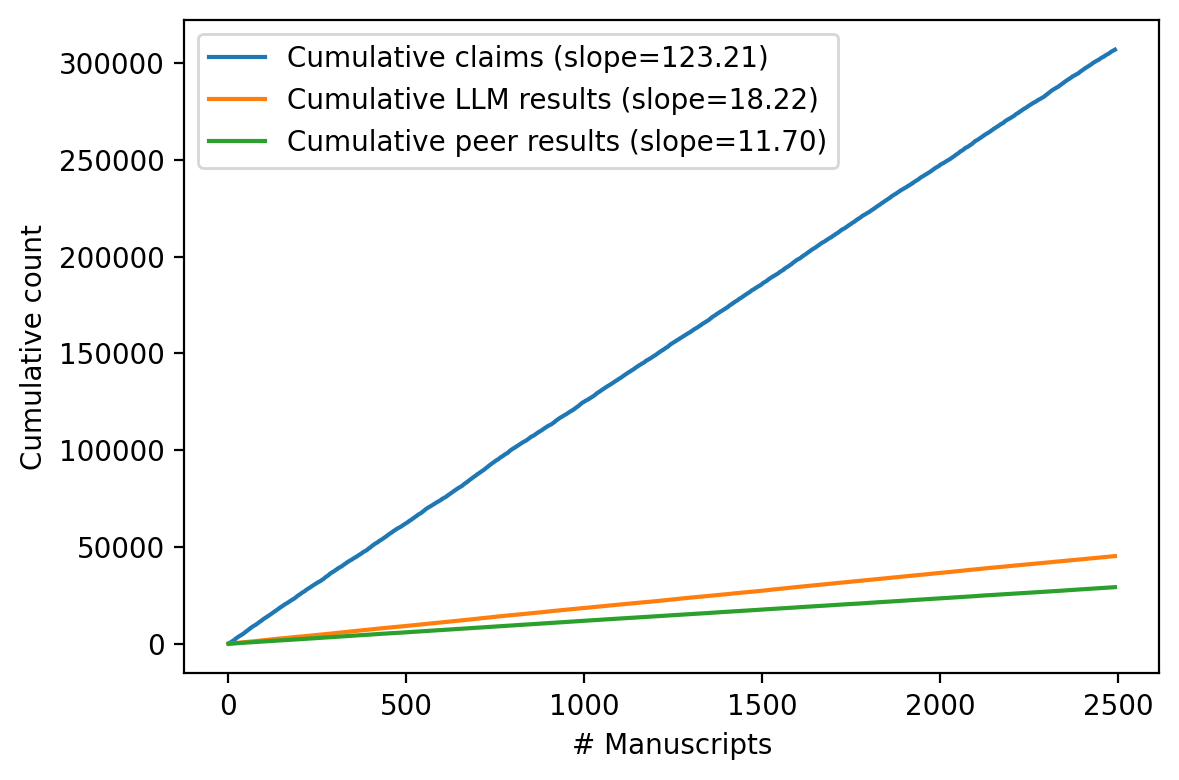

In [34]:
# sort by paper
claims_per_manuscript = claims_per_manuscript.sort_values("manuscript_id").reset_index(drop=True)

# cumulative sums
claims_per_manuscript["cum_claims"] = claims_per_manuscript["n_claims"].cumsum()
claims_per_manuscript["cum_results_llm"] = claims_per_manuscript["n_results_llm"].cumsum()
claims_per_manuscript["cum_results_peer"] = claims_per_manuscript["n_results_peer"].cumsum()

x = claims_per_manuscript.index + 1
y_claims = claims_per_manuscript["cum_claims"]
y_llm = claims_per_manuscript["cum_results_llm"]
y_peer = claims_per_manuscript["cum_results_peer"]

fig, ax = plt.subplots(figsize=(6,4))

# Plot each and add slopes in the legends
line1, = ax.plot(x, y_claims, label="Cumulative claims")
line2, = ax.plot(x, y_llm, label="Cumulative LLM results")
line3, = ax.plot(x, y_peer, label="Cumulative peer results")

# Calculate and show slope for each line (using simple linear fit: np.polyfit)
slope_claims = np.polyfit(x, y_claims, 1)[0]
slope_llm = np.polyfit(x, y_llm, 1)[0]
slope_peer = np.polyfit(x, y_peer, 1)[0]

# Set legend with slopes
ax.legend([
    f"Cumulative claims (slope={slope_claims:.2f})", 
    f"Cumulative LLM results (slope={slope_llm:.2f})", 
    f"Cumulative peer results (slope={slope_peer:.2f})"
])

ax.set_xlabel("# Manuscripts")
ax.set_ylabel("Cumulative count")

plt.tight_layout()
plt.show()

R^2 (number of claims vs manuscript length): 0.023


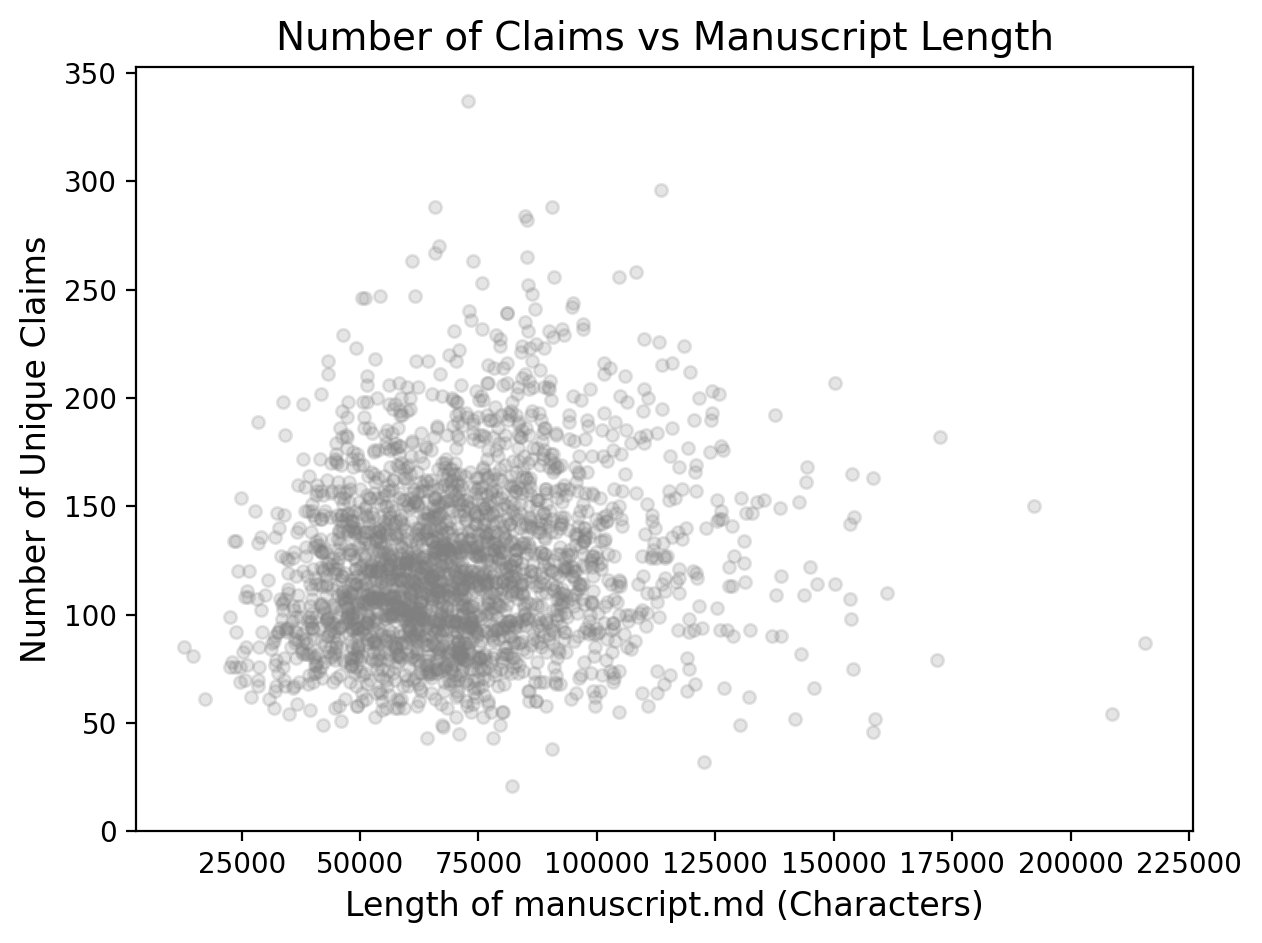

In [35]:
# Set dot color and size here
dot_color = 'grey'
dot_size = 20

# Path to directory containing manuscript.md files in the given structure
md_base_dir = "../manuscripts"

# Get all unique (manuscript_id, version) pairs from df_claims
if "manuscript_id" in df_claims.columns and "version" in df_claims.columns:
    manuscript_versions = df_claims[["manuscript_id", "version"]].drop_duplicates().values
else:
    # fallback: just manuscript_id, assume v1
    manuscript_versions = [(mid, "v1") for mid in df_claims["manuscript_id"].unique()]

manuscript_lengths = []
num_claims = []
manuscript_ids_found = []

for manuscript_id, version in manuscript_versions:
    md_path = os.path.join(md_base_dir, manuscript_id, version, "manuscript.md")
    if not os.path.isfile(md_path):
        continue

    with open(md_path, "r", encoding="utf-8") as f:
        md_text = f.read()
        length = len(md_text)

    # Get number of unique claims for this manuscript_id and version:
    if "manuscript_id" in df_claims.columns and "claim_id" in df_claims.columns and "version" in df_claims.columns:
        df_this_claims = df_claims[
            (df_claims["manuscript_id"] == manuscript_id) & (df_claims["version"] == version)
        ]
        n_claims = df_this_claims["claim_id"].nunique()
    else:
        n_claims = None  # Fallback if columns are missing

    manuscript_lengths.append(length)
    num_claims.append(n_claims)
    manuscript_ids_found.append(f"{manuscript_id} ({version})")

# Sort the data by manuscript length
sorted_data = sorted(zip(manuscript_lengths, num_claims, manuscript_ids_found), key=lambda x: x[0])
manuscript_lengths_sorted = [x[0] for x in sorted_data]
num_claims_sorted = [x[1] for x in sorted_data]
manuscript_ids_sorted = [x[2] for x in sorted_data]

plt.scatter(manuscript_lengths_sorted, num_claims_sorted, color=dot_color, s=dot_size, alpha=0.2)

# --- Add r2 computation and print ---
import numpy as np
from sklearn.metrics import r2_score

# Only use entries where num_claims is not None
x = np.array([ml for ml, nc in zip(manuscript_lengths_sorted, num_claims_sorted) if nc is not None])
y = np.array([nc for nc in num_claims_sorted if nc is not None])

if len(x) > 1:
    coeffs = np.polyfit(x, y, 1)
    poly1d_fn = np.poly1d(coeffs)
    x_line = np.linspace(x.min(), x.max(), 100)
    # plt.plot(x_line, poly1d_fn(x_line), color='black', linestyle='--', alpha=0.7, label='Linear fit')
    # plt.legend()
    # Calculate r2
    y_pred = poly1d_fn(x)
    r2 = r2_score(y, y_pred)
    print(f"R^2 (number of claims vs manuscript length): {r2:.3f}")

plt.xlabel("Length of manuscript.md (Characters)", fontsize=12)
plt.ylabel("Number of Unique Claims", fontsize=12)
plt.title("Number of Claims vs Manuscript Length", fontsize=14)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Plot evaluation for each claim evidence type 

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_39433/2962996368.py:200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([cat.capitalize() for cat in summary_llm["evidence_cat"]],
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_39433/2962996368.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


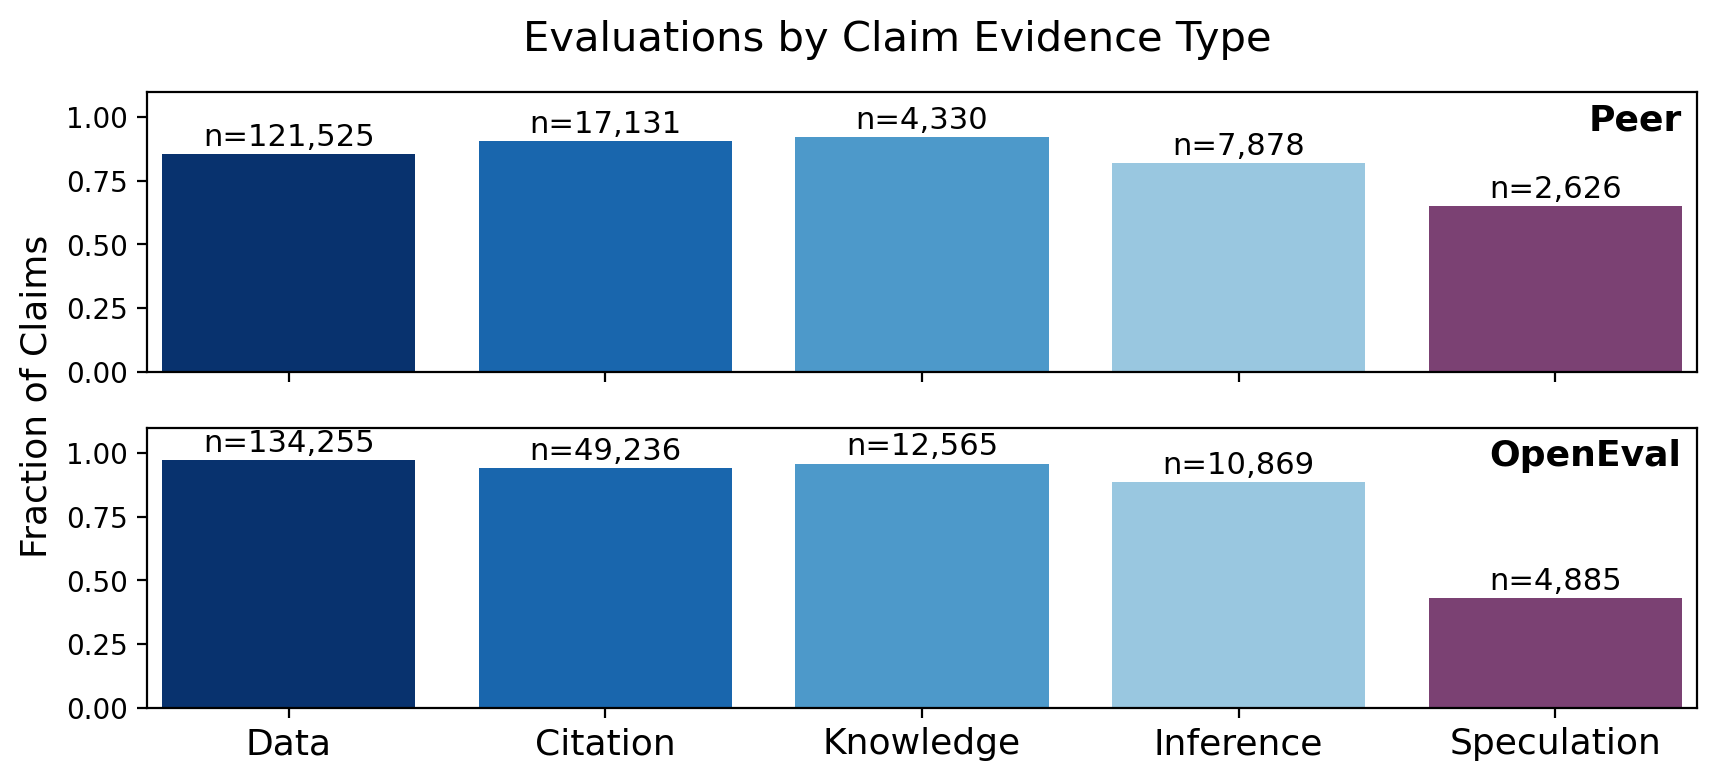

In [36]:
import ast

# ----- Use color palette from 3_entire_corpus_analysis.ipynb -----
palette = [
    plt.get_cmap('Blues')(0.99),
    plt.get_cmap('Blues')(0.79),
    plt.get_cmap('Blues')(0.59),
    plt.get_cmap('Blues')(0.39),
    "#7b4173",
    "#a55194",
    "#ce6dbd",
    "#de9ed6",
]

# ---------- parsers ----------
def parse_claim_ids(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            s = x.strip().strip("[]")
            if not s:
                return []
            return [t.strip().strip("'").strip('"') for t in s.split(",")]
    return []

def parse_bracket_list(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple, set)):
        return [str(v).strip() for v in x if str(v).strip()]
    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        inner = s[1:-1].strip()
        if not inner:
            return []
        return [t.strip() for t in inner.split(",") if t.strip()]
    return [s] if s else []

def count_listlike(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 0
    if isinstance(val, (list, tuple, set)):
        return len(val)
    s = str(val).strip().strip("[]").strip()
    if not s:
        return 0
    return len([t for t in (x.strip() for x in s.split(",")) if t])

# -----------------------
# 1) Peer review -> claim_key level supported
# -----------------------
peer = df_peer.copy()
peer["claim_id_list"] = peer["claim_ids"].apply(parse_claim_ids)
peer = peer.explode("claim_id_list", ignore_index=True).rename(columns={"claim_id_list": "claim_id"})

peer["claim_id"] = peer["claim_id"].astype(str).str.strip()
peer["manuscript_id"] = peer["manuscript_id"].astype(str).str.strip()

# UNIQUE KEY
peer["claim_key"] = peer["manuscript_id"] + "::" + peer["claim_id"]

# ---------- NEW: exclude claims contributing to >1 result ----------
peer_claim_counts = peer.groupby("claim_key").size()
single_result_peer_claims = peer_claim_counts[peer_claim_counts == 1].index
peer = peer[peer["claim_key"].isin(single_result_peer_claims)].copy()
# ---------------------------------------------------------------

rank = {"SUPPORTED": 2, "UNCERTAIN": 1}
peer["eval_rank"] = peer["evaluation_type"].map(rank).fillna(0).astype(int)

claim_eval_peer = (
    peer.groupby("claim_key", as_index=False)["eval_rank"].max()
)
claim_eval_peer["is_supported_any"] = claim_eval_peer["eval_rank"].eq(2)

# -----------------------
# 1b) LLM review -> claim_key level supported
# -----------------------
llm = df_llm.copy()
llm["claim_id_list"] = llm["claim_ids"].apply(parse_claim_ids)
llm = llm.explode("claim_id_list", ignore_index=True).rename(columns={"claim_id_list": "claim_id"})

llm["claim_id"] = llm["claim_id"].astype(str).str.strip()
llm["manuscript_id"] = llm["manuscript_id"].astype(str).str.strip()

llm["claim_key"] = llm["manuscript_id"] + "::" + llm["claim_id"]

# ---------- NEW: exclude claims contributing to >1 result ----------
llm_claim_counts = llm.groupby("claim_key").size()
single_result_llm_claims = llm_claim_counts[llm_claim_counts == 1].index
llm = llm[llm["claim_key"].isin(single_result_llm_claims)].copy()
# ---------------------------------------------------------------

llm["eval_rank"] = llm["evaluation_type"].map(rank).fillna(0).astype(int)

claim_eval_llm = (
    llm.groupby("claim_key", as_index=False)["eval_rank"].max()
)
claim_eval_llm["is_supported_any"] = claim_eval_llm["eval_rank"].eq(2)

# -----------------------
# 2) Claims -> claim_key and filter to only single-evidence-type claims
# -----------------------
claims = df_claims.copy()
claims["claim_id"] = claims["claim_id"].astype(str).str.strip()
claims["manuscript_id"] = claims["manuscript_id"].astype(str).str.strip()
claims["claim_key"] = claims["manuscript_id"] + "::" + claims["claim_id"]

claims["evidence_list"] = claims["evidence_type"].apply(parse_bracket_list)
claims["evidence_count"] = claims["evidence_list"].apply(count_listlike)
claims_single_evidence = claims[claims["evidence_count"] == 1].copy()

claims_single_evidence["evidence_cat"] = claims_single_evidence["evidence_list"].apply(
    lambda x: x[0] if len(x) == 1 else ""
)
claims_single_evidence["evidence_cat"] = claims_single_evidence["evidence_cat"].astype(str).str.strip()
claims_single_evidence = claims_single_evidence[claims_single_evidence["evidence_cat"].ne("")]

# join peer outcome
claims_peer = claims_single_evidence.merge(
    claim_eval_peer[["claim_key", "is_supported_any"]],
    on="claim_key",
    how="left"
)
claims_peer_reviewed = claims_peer.dropna(subset=["is_supported_any"]).copy()

# join llm outcome
claims_llm = claims_single_evidence.merge(
    claim_eval_llm[["claim_key", "is_supported_any"]],
    on="claim_key",
    how="left"
)
claims_llm_reviewed = claims_llm.dropna(subset=["is_supported_any"]).copy()

# -----------------------
# 3) Summarize (single-evidence, single-result only)
# -----------------------
summary_peer = (
    claims_peer_reviewed.groupby("evidence_cat", as_index=False)
    .agg(
        n_claims=("claim_key", "nunique"),
        p_supported=("is_supported_any", "mean"),
    )
)
summary_llm = (
    claims_llm_reviewed.groupby("evidence_cat", as_index=False)
    .agg(
        n_claims=("claim_key", "nunique"),
        p_supported=("is_supported_any", "mean"),
    )
)

# Specify plotting order
desired_order = ["DATA", "CITATION", "KNOWLEDGE", "INFERENCE", "SPECULATION"]
evidence_types_present = [cat for cat in desired_order if cat in summary_peer["evidence_cat"].values]

summary_peer = summary_peer.set_index("evidence_cat").reindex(evidence_types_present).reset_index()
summary_llm = summary_llm.set_index("evidence_cat").reindex(evidence_types_present).reset_index()

bar_colors = palette[:len(evidence_types_present)]

# -----------------------
# 4) Plot
# -----------------------
fig, axs = plt.subplots(
    2, 1, figsize=(10, 4), sharex=True,
    gridspec_kw={'height_ratios': [1, 1], 'wspace': 0.05}
)

fontsize = 13
fig.text(0.07, 0.5, "Fraction of Claims", va='center',
         rotation='vertical', fontsize=fontsize, ha='center')

# Peer
ax = axs[0]
ax.bar(summary_peer["evidence_cat"], summary_peer["p_supported"], color=bar_colors)
ax.set_ylim(0, 1.1)
fig.suptitle("Evaluations by Claim Evidence Type", fontsize=fontsize + 2, y=0.97)
ax.text(0.99, 0.96, "Peer", ha='right', va='top',
        fontsize=fontsize, transform=ax.transAxes, fontweight='bold')

for i, row in summary_peer.iterrows():
    ax.text(i, row["p_supported"] + 0.01, f"n={int(row['n_claims']):,}",
            ha="center", va="bottom", fontsize=fontsize - 2)

ax.margins(x=0.01)
ax.tick_params(axis="x", labelsize=fontsize)
ax.set_xlabel("")

# LLM
ax2 = axs[1]
ax2.bar(summary_llm["evidence_cat"], summary_llm["p_supported"], color=bar_colors)
ax2.set_ylim(0, 1.1)
ax2.text(0.99, 0.96, "OpenEval", ha='right', va='top',
         fontsize=fontsize, transform=ax2.transAxes, fontweight='bold')

ax2.set_xticklabels([cat.capitalize() for cat in summary_llm["evidence_cat"]],
                     fontsize=fontsize)

for i, row in summary_llm.iterrows():
    ax2.text(i, row["p_supported"] + 0.01, f"n={int(row['n_claims']):,}",
             ha="center", va="bottom", fontsize=fontsize - 2)

ax2.margins(x=0.01)
ax2.tick_params(axis="x", labelsize=fontsize)

plt.tight_layout()
# fig.savefig("figures/1_peer_vs_openeval_by_evidence_type.png", dpi=300, bbox_inches="tight")
plt.show()


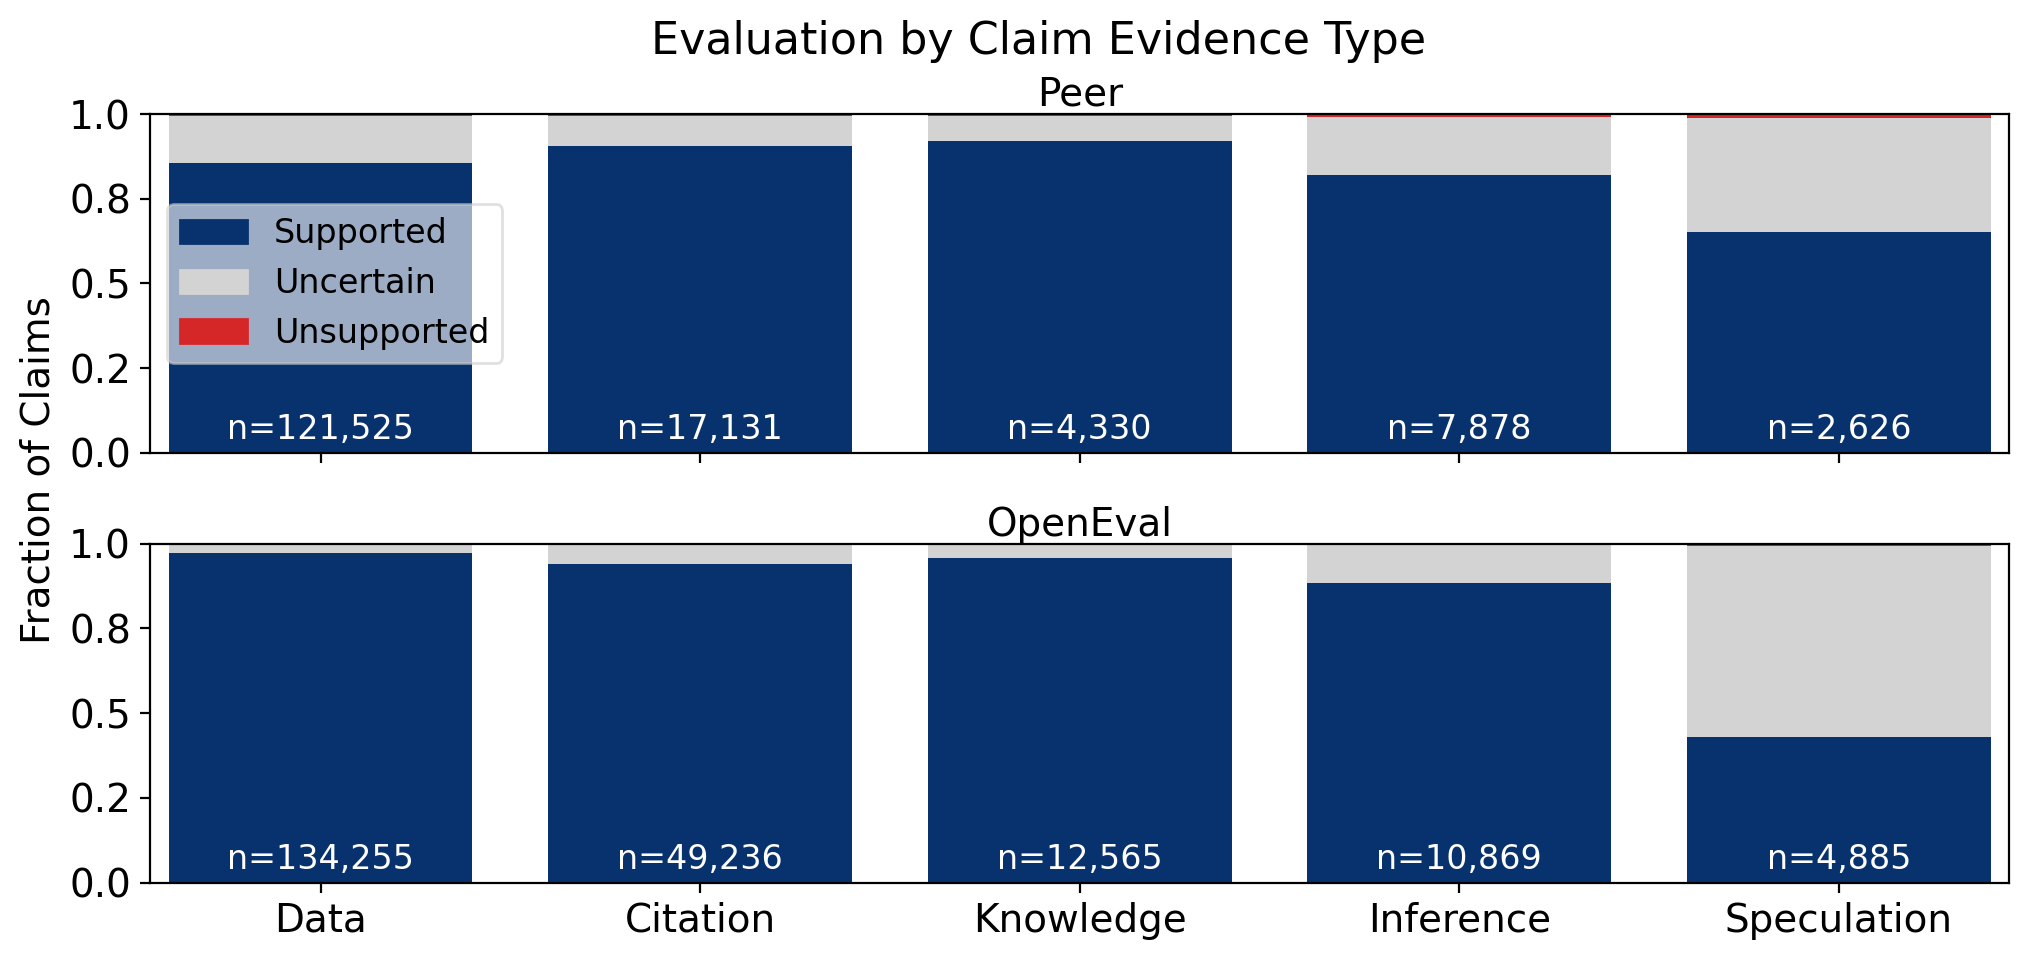

In [37]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Helper Functions ----------
def parse_claim_ids(x):
    """Parse a string or iterable of claim IDs into a flat list of strings."""
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            s = x.strip().strip("[]")
            if not s:
                return []
            return [t.strip().strip("'\"") for t in s.split(",") if t.strip()]
    return []

def parse_bracket_list(x):
    """Parse a bracketed string or iterable into a list of stripped strings."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple, set)):
        return [str(v).strip() for v in x if str(v).strip()]
    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()
        if not s:
            return []
        return [t.strip() for t in s.split(",") if t.strip()]
    return [s] if s else []

def count_listlike(val):
    """Count number of elements in a list-like object or comma-separated string."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 0
    if isinstance(val, (list, tuple, set)):
        return len(val)
    s = str(val).strip().strip("[]")
    if not s:
        return 0
    return len([t for t in (x.strip() for x in s.split(",")) if t])

def normalize_eval(s):
    """Normalize evaluation_type to SUPPORTED / UNCERTAIN / UNSUPPORTED."""
    s = str(s).strip().upper()
    if s == "SUPPORTED":
        return "SUPPORTED"
    if s == "UNCERTAIN":
        return "UNCERTAIN"
    # Everything else goes to UNSUPPORTED (incl. NOT_SUPPORTED / REFUTED / etc.)
    return "UNSUPPORTED"

# Rank mapping for evaluation prioritization
EVAL_RANK = {"SUPPORTED": 2, "UNCERTAIN": 1, "UNSUPPORTED": 0}
EVAL_LABELS = {2: "SUPPORTED", 1: "UNCERTAIN", 0: "UNSUPPORTED"}

# ---------- Step 1: Peer and LLM Claim-Level Label Normalization ----------
def prep_evals(df, normalize_eval_func, rank_map):
    """Explode claim_ids, build claim_key, normalize & rank evaluation, single-result only."""
    df = df.copy()
    df["claim_id_list"] = df["claim_ids"].apply(parse_claim_ids)
    df = df.explode("claim_id_list", ignore_index=True).rename(columns={"claim_id_list": "claim_id"})
    df["claim_id"] = df["claim_id"].astype(str).str.strip()
    df["manuscript_id"] = df["manuscript_id"].astype(str).str.strip()
    df["claim_key"] = df["manuscript_id"] + "::" + df["claim_id"]

    # Only claims contributing to a single result
    claim_counts = df.groupby("claim_key").size()
    single_result_claims = claim_counts[claim_counts == 1].index
    df = df[df["claim_key"].isin(single_result_claims)].copy()

    df["eval_norm"] = df["evaluation_type"].apply(normalize_eval_func)
    df["eval_rank"] = df["eval_norm"].map(rank_map).astype(int)

    # For claims with more than one eval (shouldn't be, after filtering): take max rank
    claim_eval = df.groupby("claim_key", as_index=False)["eval_rank"].max()
    claim_eval["evaluation"] = claim_eval["eval_rank"].map(EVAL_LABELS)
    return claim_eval

claim_eval_peer = prep_evals(df_peer, normalize_eval, EVAL_RANK)
claim_eval_llm  = prep_evals(df_llm, normalize_eval, EVAL_RANK)

# ---------- Step 2: Claims Table to Single-Evidence-Type Claims ----------
claims = df_claims.copy()
claims["claim_id"] = claims["claim_id"].astype(str).str.strip()
claims["manuscript_id"] = claims["manuscript_id"].astype(str).str.strip()
claims["claim_key"] = claims["manuscript_id"] + "::" + claims["claim_id"]

claims["evidence_list"] = claims["evidence_type"].apply(parse_bracket_list)
claims["evidence_count"] = claims["evidence_list"].apply(count_listlike)
claims_single_evidence = claims[claims["evidence_count"] == 1].copy()
claims_single_evidence["evidence_cat"] = (
    claims_single_evidence["evidence_list"].apply(lambda x: x[0] if x else "")
)
claims_single_evidence["evidence_cat"] = claims_single_evidence["evidence_cat"].astype(str).str.strip()
claims_single_evidence = claims_single_evidence[claims_single_evidence["evidence_cat"].ne("")]

# Join peer and LLM labels; drop unreviewed claims
claims_peer_reviewed = (
    claims_single_evidence.merge(claim_eval_peer[["claim_key", "evaluation"]], on="claim_key", how="left")
    .dropna(subset=["evaluation"])
    .copy()
)
claims_llm_reviewed = (
    claims_single_evidence.merge(claim_eval_llm[["claim_key", "evaluation"]], on="claim_key", how="left")
    .dropna(subset=["evaluation"])
    .copy()
)

# ---------- Step 3: Summarize by Evidence Type ----------
def summarize_fractions(df, cat_col="evidence_cat", eval_col="evaluation"):
    """Group by evidence_cat and evaluation, output fractions and claim counts."""
    counts = (
        df.groupby([cat_col, eval_col])["claim_key"]
          .nunique()
          .unstack(eval_col, fill_value=0)
    )
    # Guarantee columns order and existence
    for col in EVAL_LABELS.values():
        if col not in counts.columns:
            counts[col] = 0
    counts = counts[list(EVAL_LABELS.values())]
    fracs = counts.div(counts.sum(axis=1), axis=0)
    n_total = counts.sum(axis=1).rename("n_claims")
    return fracs.join(n_total)

summary_peer = summarize_fractions(claims_peer_reviewed)
summary_llm  = summarize_fractions(claims_llm_reviewed)

# Plotting order
desired_order = ["DATA", "CITATION", "KNOWLEDGE", "INFERENCE", "SPECULATION"]
evidence_types_present = [c for c in desired_order if c in summary_peer.index]
summary_peer = summary_peer.reindex(evidence_types_present)
summary_llm  = summary_llm.reindex(evidence_types_present)

# ---------- Step 4: Plot ----------
def plot_stacked_bar(ax, summary, title, fontsize=14, label_bar_color="white", color_map=None):
    x = np.arange(len(summary.index))
    bottom = np.zeros_like(x, dtype=float)
    default_color_map = {
        "SUPPORTED": plt.get_cmap('Blues')(0.99),
        "UNCERTAIN": "lightgrey",
        "UNSUPPORTED": "tab:red",
    }
    # Allow passing a color_map for legend consistency
    color_map = color_map if color_map is not None else default_color_map
    for eval_name in ["SUPPORTED", "UNCERTAIN", "UNSUPPORTED"]:
        vals = summary[eval_name].to_numpy()
        ax.bar(x, vals, bottom=bottom, color=color_map[eval_name],
               label=eval_name if title == "Peer" else None)
        bottom += vals
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=fontsize, pad=0)
    for i, n in enumerate(summary["n_claims"].astype(int).to_numpy()):
        ax.text(i, 0.02, f"n={n:,}", ha="center", va="bottom",
                fontsize=fontsize-2, color=label_bar_color)
    ax.set_xticks(x)
    ax.margins(x=0.01)
    # Format y ticks to only one decimal
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}"))

fontsize = 14

# Consistent color map for bars and legend
legend_color_map = {
    "SUPPORTED": plt.get_cmap('Blues')(0.99),
    "UNCERTAIN": "lightgrey",
    "UNSUPPORTED": "tab:red",
}

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
fig.text(0, 0.5, "Fraction of Claims", va='center', rotation='vertical', fontsize=fontsize, ha='center')
fig.suptitle("Evaluation by Claim Evidence Type", fontsize=fontsize + 2, y=0.95)

plot_stacked_bar(axs[0], summary_peer, "Peer", fontsize, color_map=legend_color_map)
plot_stacked_bar(axs[1], summary_llm, "OpenEval", fontsize, color_map=legend_color_map)

xtick_labels = [c.capitalize() for c in summary_peer.index]
axs[1].set_xticklabels(xtick_labels, rotation=0, fontsize=fontsize)
for ax in axs:
    ax.tick_params(axis="both", labelsize=fontsize)
    # Ensure one decimal on y-ticklabels (in case of existing ticks)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}"))

# Single legend (top axis only) - use exact colors from the bar plot
handles = [
    plt.Rectangle((0, 0), 1, 1, color=legend_color_map["SUPPORTED"]),
    plt.Rectangle((0, 0), 1, 1, color=legend_color_map["UNCERTAIN"]),
    plt.Rectangle((0, 0), 1, 1, color=legend_color_map["UNSUPPORTED"]),
]
labels = ["Supported", "Uncertain", "Unsupported"]
# Set legend framealpha lower for more transparent background
axs[0].legend(handles, labels, loc="center left", frameon=True, fontsize=fontsize-2, framealpha=0.6)

plt.tight_layout()
fig.savefig("figures/1_peer_vs_openeval_by_evidence_type.png", dpi=300, bbox_inches="tight")
plt.show()


In [46]:
import pandas as pd

def percent_multi_result_claims(df, name="df"):
    # explode so each claim is a row
    exploded = df.explode("claim_ids")

    # for each manuscript + claim, count how many unique results it appears in
    claim_result_counts = (
        exploded
        .groupby(["manuscript_id", "claim_ids"])["result_id"]
        .nunique()
    )

    # claims contributing to >1 result *within the same manuscript*
    multi_result_claims = claim_result_counts[claim_result_counts > 1]

    percent = 100 * len(multi_result_claims) / len(claim_result_counts)

    print(
        f"{name}: {percent:.2f}% "
        f"({len(multi_result_claims)} / {len(claim_result_counts)} manuscript-claim pairs)"
    )

# run for both dataframes
percent_multi_result_claims(df_llm, name="df_llm")
percent_multi_result_claims(df_peer, name="df_peer")


df_llm: 0.53% (1476 / 280408 manuscript-claim pairs)
df_peer: 0.42% (851 / 203162 manuscript-claim pairs)


### Timeseries

Add manuscript publication dates to cmp_df:

In [199]:
def get_pub_date(manuscript_id, version=None):
    """
    Given a manuscript_id and optional version, locate and return the publication date
    from manuscript_metadata.json. If version is None, search across all v* versions.
    """

    base_dir = "../manuscripts"
    manuscript_dir = os.path.join(base_dir, manuscript_id)
    if version is not None:
        glob_pattern = os.path.join(manuscript_dir, f"v{version}", "manuscript_metadata.json")
    else:
        glob_pattern = os.path.join(manuscript_dir, "v*", "manuscript_metadata.json")
    meta_files = glob.glob(glob_pattern)
    # Sort for deterministic behavior; pick the first if multiple versions
    meta_files = sorted(meta_files)
    for meta_path in meta_files:
        if os.path.exists(meta_path):
            try:
                with open(meta_path, "r") as f:
                    metadata = json.load(f)
                return metadata.get("pub_date", None)
            except Exception as e:
                return None
    return None

# Avoid duplicated work by memorizing manuscript_id -> pub_date
pubdate_cache = {}

pub_dates = []
for manuscript_id in df_cmp["manuscript_id"]:
    if manuscript_id in pubdate_cache:
        pub_date = pubdate_cache[manuscript_id]
    else:
        pub_date = get_pub_date(manuscript_id)
        pubdate_cache[manuscript_id] = pub_date
    pub_dates.append(pub_date)

df_cmp = df_cmp.copy()
df_cmp["pub_date"] = pub_dates

df_cmp

,comparison_id,openeval_result_id,peer_result_id,openeval_evaluation_type,peer_evaluation_type,openeval_result_type,peer_result_type,comparison_type,comparison,n_openeval,n_peer,n_itx,manuscript_id,version,intersection_fraction,n_peer_int,n_openeval_int,agree_bar_cat,pub_date,month
0,CMP1,R2,R2,Supported,Supported,MAJOR,MAJOR,Agree,"Perfect agreement on claims C4, C40-C42 regard...",4.0,4.0,4,elife-91771,v1,1.000000,4,4,Agree,2025-06-03,NaT
1,CMP2,R1,R1,Supported,Supported,MAJOR,MAJOR,Agree,"Strong agreement on claims C3, C36-C38 regardi...",7.0,5.0,4,elife-91771,v1,0.571429,5,7,Agree,2025-06-03,NaT
2,CMP3,R3,R3,Supported,Supported,MAJOR,MAJOR,Agree,"Agreement on claims C5, C43-C44 regarding corr...",3.0,5.0,3,elife-91771,v1,0.600000,5,3,Agree,2025-06-03,NaT
3,CMP4,R6,R7,Supported,Supported,MAJOR,MINOR,Agree,"Agreement on claims C31-C32, C57, C59-C60 rega...",7.0,6.0,5,elife-91771,v1,0.714286,6,7,Agree,2025-06-03,NaT
4,CMP5,R7,R4,Supported,Uncertain,MAJOR,MAJOR,Partial,Disagreement on inverted-U relationship claims...,5.0,6.0,4,elife-91771,v1,0.666667,6,5,Partial:PeerUncertain,2025-06-03,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50898,CMP16,R6,R12,Supported,Supported,MAJOR,MINOR,Agree,"Both address parallelism analysis claims (C39,...",4.0,3.0,2,elife-87039,v1,0.500000,3,4,Agree,2023-11-22,NaT
50899,CMP17,R3,R10,Supported,Supported,MINOR,MAJOR,Agree,Both address metabolome coverage limitation (C...,8.0,4.0,1,elife-87039,v1,0.125000,4,8,Agree,2023-11-22,NaT
50900,CMP18,R2,R13,Supported,Supported,MINOR,MINOR,Agree,Overlap on experimental design details (C112-C...,11.0,10.0,5,elife-87039,v1,0.454545,10,11,Agree,2023-11-22,NaT
50901,CMP19,R4,R13,Supported,Supported,MAJOR,MINOR,Agree,Minor overlap on PCA details (C35-C36). OpenEv...,11.0,10.0,2,elife-87039,v1,0.181818,10,11,Agree,2023-11-22,NaT


In [200]:
sorted(pd.to_datetime(df_cmp["pub_date"].unique()).dropna())

[Timestamp('2023-06-02 00:00:00'),
 Timestamp('2023-06-07 00:00:00'),
 Timestamp('2023-06-13 00:00:00'),
 Timestamp('2023-06-16 00:00:00'),
 Timestamp('2023-06-21 00:00:00'),
 Timestamp('2023-06-23 00:00:00'),
 Timestamp('2023-06-26 00:00:00'),
 Timestamp('2023-06-27 00:00:00'),
 Timestamp('2023-06-29 00:00:00'),
 Timestamp('2023-06-30 00:00:00'),
 Timestamp('2023-07-04 00:00:00'),
 Timestamp('2023-07-05 00:00:00'),
 Timestamp('2023-07-06 00:00:00'),
 Timestamp('2023-07-07 00:00:00'),
 Timestamp('2023-07-13 00:00:00'),
 Timestamp('2023-07-14 00:00:00'),
 Timestamp('2023-07-18 00:00:00'),
 Timestamp('2023-07-19 00:00:00'),
 Timestamp('2023-07-20 00:00:00'),
 Timestamp('2023-07-25 00:00:00'),
 Timestamp('2023-07-26 00:00:00'),
 Timestamp('2023-07-28 00:00:00'),
 Timestamp('2023-08-02 00:00:00'),
 Timestamp('2023-08-03 00:00:00'),
 Timestamp('2023-08-07 00:00:00'),
 Timestamp('2023-08-08 00:00:00'),
 Timestamp('2023-08-17 00:00:00'),
 Timestamp('2023-08-23 00:00:00'),
 Timestamp('2023-08-

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_56620/3131354467.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


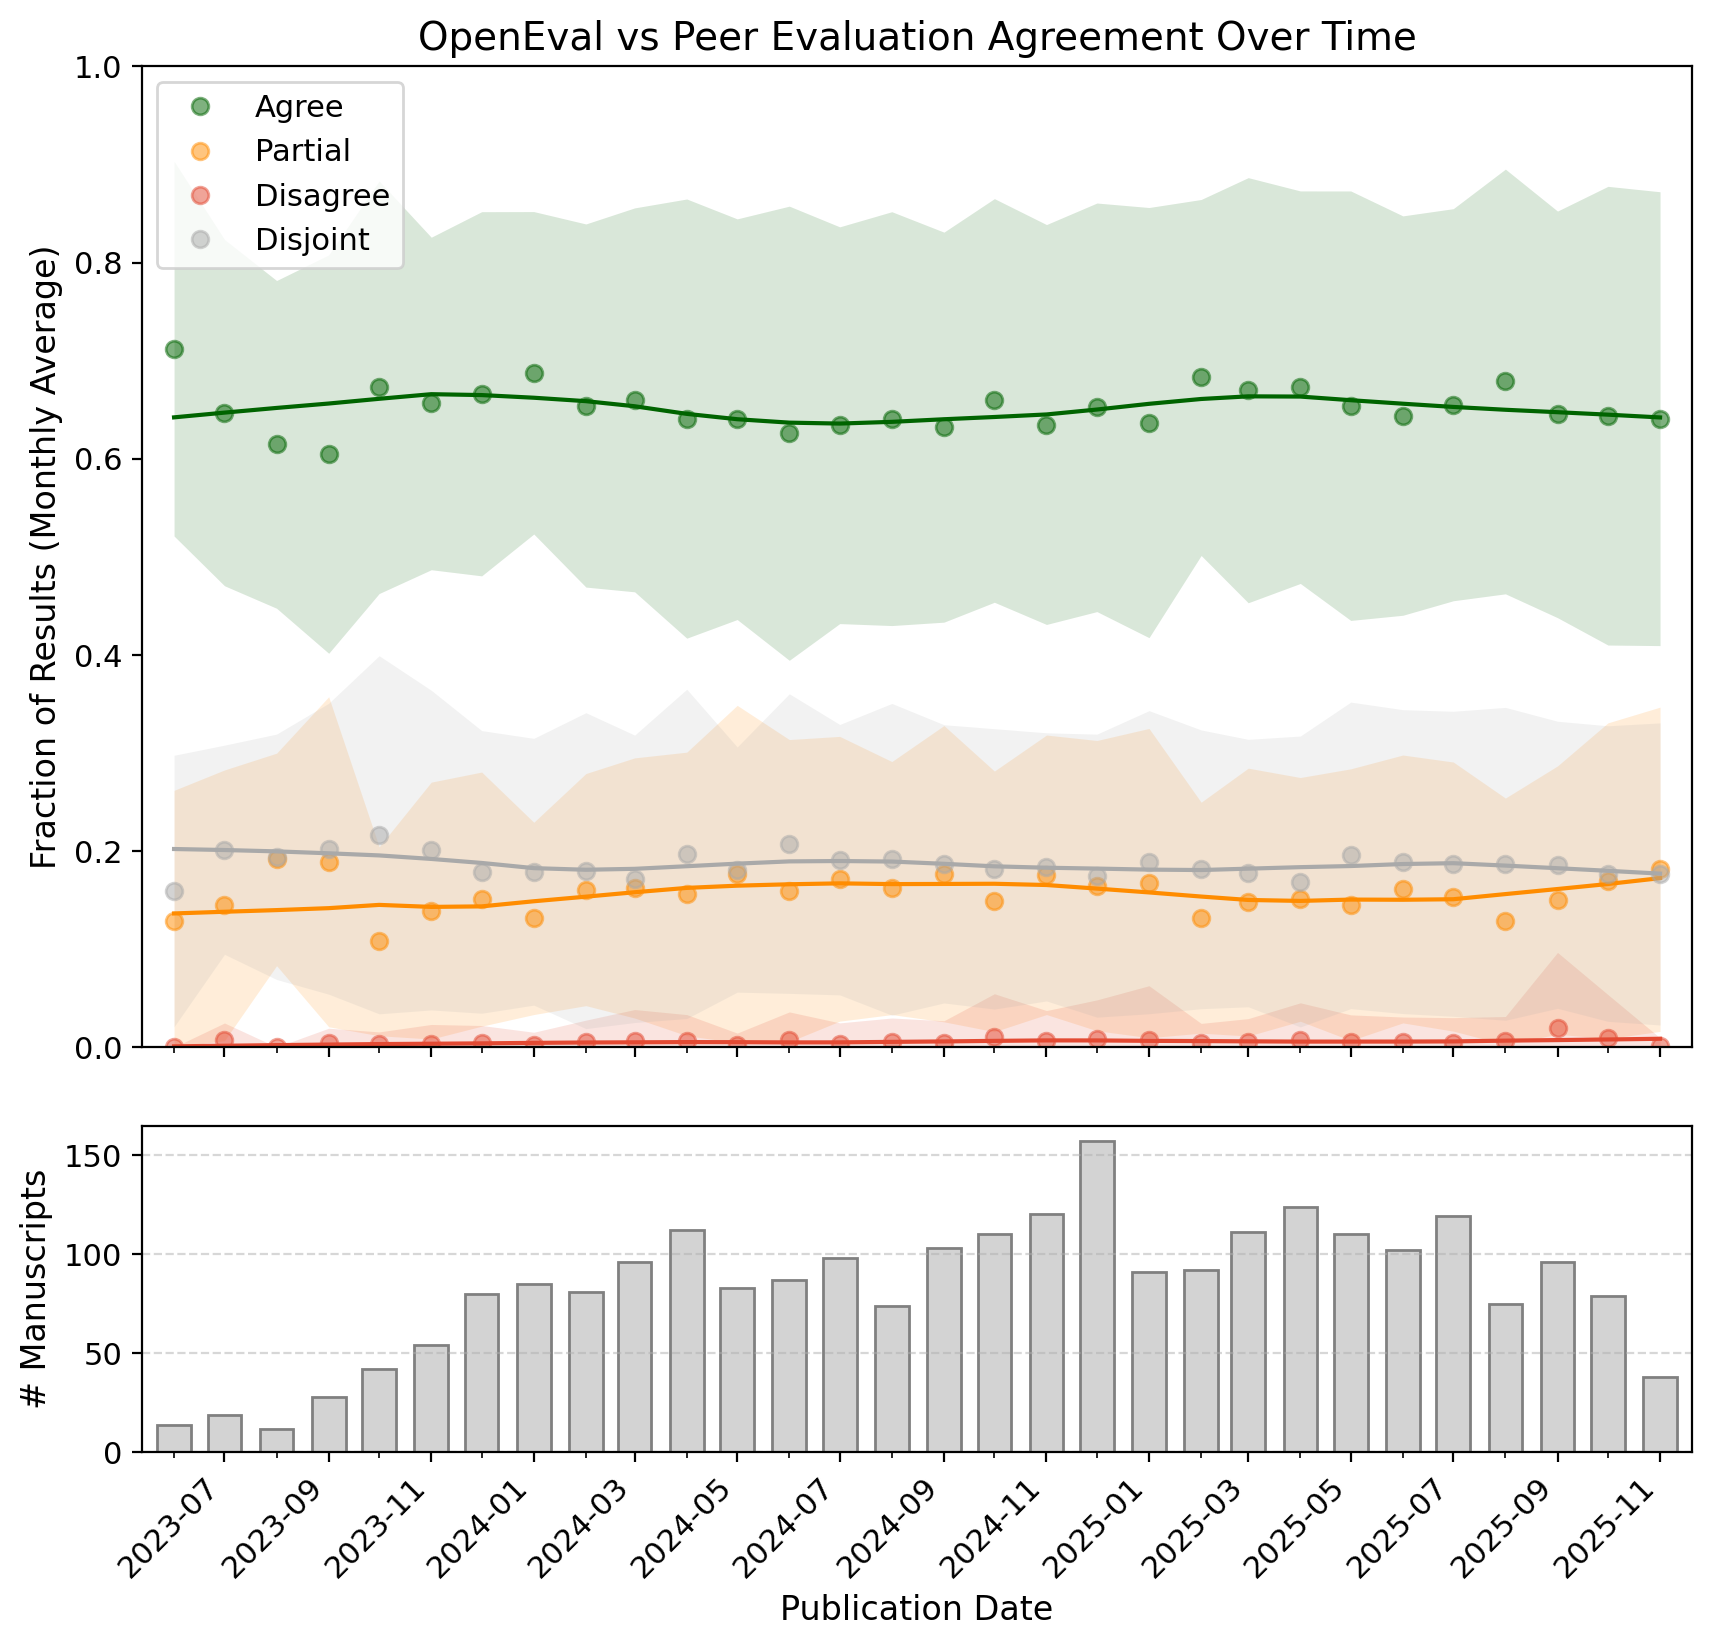

In [201]:
fontsize = 12

# Ensure 'pub_date' is parsed as datetime
df_cmp["pub_date"] = pd.to_datetime(df_cmp["pub_date"])

type_col = "comparison_type"

# Group by month (year and month)
df_cmp["month"] = df_cmp["pub_date"].dt.to_period("M")

# Compute the total count for each category per month
counts_table = (
    df_cmp.groupby(["month", type_col])
    .size()
    .unstack(fill_value=0)
)

# Normalize each row to sum to 1 (show the fraction per month)
comparison_counts = counts_table.div(counts_table.sum(axis=1), axis=0)

# Use the first day of the month as the x-axis alignment for plotting
comparison_counts.index = comparison_counts.index.to_timestamp(how="start")
counts_table.index = counts_table.index.to_timestamp(how="start")  # align for n_t lookup

# Calculate unique manuscript counts per month
manuscripts_per_month = (
    df_cmp.drop_duplicates(subset=["manuscript_id", "month"])
    .groupby("month")["manuscript_id"]
    .nunique()
)
manuscripts_per_month.index = manuscripts_per_month.index.to_timestamp(how="start")

# --- per-manuscript-per-month fractions and monthly mean/SD (Option 1) ---
ms_tab = (
    df_cmp.groupby(["month", "manuscript_id", type_col])
    .size()
    .unstack(fill_value=0)
)
ms_tab["n"] = ms_tab.sum(axis=1)  # total comparisons per manuscript-month

def per_month_stats_for(cat):
    # p_i for each manuscript in the month (fraction in this category)
    if cat in ms_tab.columns:
        p = ms_tab[cat] / ms_tab["n"]
    else:
        p = pd.Series(0.0, index=ms_tab.index)
    stats = (
        p.reset_index()
         .groupby("month")[0]
         .agg(mean="mean", sd="std", n="count")
         .sort_index()
    )
    # Convert Period index to timestamps at month start for plotting
    stats.index = stats.index.to_timestamp(how="start")
    return stats

# Plotting: Two rows, top for fractions, bottom for barplot
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

fig = plt.figure(figsize=(10, 9))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.12)
ax = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1], sharex=ax)

for cat in desired_agree_order:
    color_match = next((v for k, v in colors.items() if cat in k), "#000000")
    # Use per-manuscript monthly mean and SD
    stats = per_month_stats_for(cat)
    if not stats.empty:
        mean = stats["mean"]
        sd = stats["sd"].fillna(0.0)  # if only one manuscript that month, SD is NaN → use 0
        upper = (mean + sd).clip(0, 1)
        lower = (mean - sd).clip(0, 1)

        # Connected band: mean ± 1 SD across manuscripts
        ax.fill_between(
            stats.index,
            lower,
            upper,
            color=color_match,
            alpha=0.15,
            linewidth=0
        )
        # Mean line (with markers) on top of the band
        ax.plot(
            stats.index,
            mean,
            color=color_match,
            # linewidth=2,
            marker='o',
            # markersize=3,
            label=cat,
            ls="",
            alpha=0.5
        )

        # Optional LOWESS on monthly means (trend only, no CI band)
        x_dates = stats.index
        x = np.array([d.value for d in x_dates])  # integer nanosecond timestamps
        y = mean.values
        valid_idx = ~np.isnan(y)
        if valid_idx.sum() > 1:
            x_valid = x[valid_idx]
            y_valid = y[valid_idx]
            loess = sm.nonparametric.lowess(y_valid, x_valid, frac=0.3, return_sorted=True)
            lowess_x = [pd.Timestamp(int(ts)) for ts in loess[:, 0]]
            ax.plot(
                lowess_x,
                loess[:, 1],
                color=color_match,
                linewidth=1.5,
                # alpha=0.7
            )

# Add vertical lines and annotations for major model releases
chatgpt_release_events = [
    # {"label": "ChatGPT-3.5", "date": pd.Timestamp("2022-11-30"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95}, # "ChatGPT-3.5 (Nov 2022)"
    # {"label": "ChatGPT-4", "date": pd.Timestamp("2023-03-14"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95}, # "ChatGPT-4 (Mar 2023)"
    # {"label": "GPT-4o", "date": pd.Timestamp("2024-05-13"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95}, # "GPT-4o (May 2024)"
    # {"label": "ELife restructuring", "date": pd.Timestamp("2023-01-31"), "color": "grey", "ha": "center", "va": "top", "pos": 0.75}, # Elife restructuring
]
for event in chatgpt_release_events:
    ax.axvline(event["date"], color=event["color"], linestyle="--", linewidth=1)
    if event["label"] is not None:
        y_lims = ax.get_ylim()
        pos = event.get("pos", 0.95)
        ax.text(
            event["date"],
            y_lims[1] * pos,
            event["label"],
            color=event["color"],
            rotation=90,
            ha=event.get("ha", "right"),
            va=event.get("va", "top"),
            fontsize=fontsize-2,
            bbox=dict(facecolor="white", edgecolor="none", alpha=1, boxstyle="round,pad=0"),
        )

ax.margins(x=0.01)
ax.set_ylim(0, 1)

ax.set_ylabel("Fraction of Results (Monthly Average)", fontsize=fontsize)
ax.set_title("OpenEval vs Peer Evaluation Agreement Over Time", fontsize=fontsize+2)
ax.legend(loc="upper left", fontsize=fontsize-1)

# --- Set x-ticks and labels (bottom axis) ---
# Make sure ticks are visible and not blank

# Choose a sensible x-tick frequency for months
ax_bar.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax_bar.xaxis.set_minor_locator(mdates.MonthLocator())
ax_bar.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax_bar.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize-1)
plt.setp(ax_bar.get_yticklabels(), fontsize=fontsize-1)

# Remove top plot's xticklabels (but not set to [])
plt.setp(ax.get_xticklabels(), visible=False)
plt.setp(ax.get_yticklabels(), fontsize=fontsize-1)

# Barplot for manuscript count per month
ax_bar.bar(manuscripts_per_month.index, manuscripts_per_month.values, 
           width=20, align="center", color="lightgray", edgecolor="gray")
ax_bar.set_xlabel("Publication Date", fontsize=fontsize)
ax_bar.set_ylabel("# Manuscripts", fontsize=fontsize)
ax_bar.set_xlim(ax.get_xlim())
ax_bar.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig("figures/1_peer_vs_openeval_agreement_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [192]:
# # Ensure 'pub_date' is parsed as datetime
# df_cmp["pub_date"] = pd.to_datetime(df_cmp["pub_date"])

# type_col = "comparison_type"

# # Compute per-manuscript agreement fractions (each manuscript is a point)
# per_ms_counts = (
#     df_cmp
#     .groupby(['manuscript_id', 'pub_date', type_col])
#     .size()
#     .unstack(fill_value=0)
# )

# # Compute totals per manuscript
# per_ms_counts_total = per_ms_counts.sum(axis=1)
# per_ms_frac = per_ms_counts.div(per_ms_counts_total, axis=0)

# # Manuscript pubdate for x axis
# ms_pubdate = per_ms_counts.index.get_level_values('pub_date')

# import matplotlib.gridspec as gridspec
# import matplotlib.dates as mdates

# fig = plt.figure(figsize=(10, 8))
# gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.12)
# ax = fig.add_subplot(gs[0])
# ax_bar = fig.add_subplot(gs[1], sharex=ax)

# for cat in desired_agree_order:
#     color_match = next((v for k, v in colors.items() if cat in k), "#000000")
#     if cat in per_ms_frac.columns:
#         # Scatter: Each manuscript is a point
#         ax.plot(
#             ms_pubdate, 
#             per_ms_frac[cat], 
#             marker='o', 
#             # label=cat,
#             color=color_match,
#             linestyle='',
#             alpha=0.1,
#         )
#         # LOWESS fit (x and y sorted by pub date, ensure proper alignment)
#         # Construct a DataFrame so that y values and pub_date are correctly aligned
#         scatter_df = per_ms_frac[cat].copy()
#         scatter_df = scatter_df.reset_index()
#         scatter_df = scatter_df.sort_values("pub_date")
#         # Now x_dates and y_vals are guaranteed to match
#         x_dates = scatter_df["pub_date"].values
#         y_vals = scatter_df[cat].values

#         # Convert datetime to ordinal for LOWESS (use datetime64[ns])
#         x = np.array([pd.Timestamp(d).toordinal() for d in x_dates])
#         valid_idx = ~np.isnan(y_vals)
#         if valid_idx.sum() > 1:
#             x_valid = x[valid_idx]
#             y_valid = y_vals[valid_idx]
#             loess = sm.nonparametric.lowess(y_valid, x_valid, frac=0.3, return_sorted=True)
#             # Convert ordinals back to Timestamps for plotting
#             lowess_x = [pd.Timestamp.fromordinal(int(ts)) for ts in loess[:, 0]]

#             ax.plot(
#                 lowess_x,
#                 loess[:, 1],
#                 color=color_match,
#                 linewidth=2,
#                 label=cat
#             )
#             # Confidence intervals: Binomial, per manuscript, aggregated by LOWESS smoothing
#             p = y_valid
#             ms_idx = scatter_df.loc[valid_idx, ["manuscript_id", "pub_date"]]
#             ms_idx_tuples = list(ms_idx.itertuples(index=False, name=None))
#             per_ms_counts_total_idx = pd.Series(per_ms_counts_total.values, index=per_ms_counts_total.index)
#             n_valid = per_ms_counts_total_idx.loc[ms_idx_tuples].values
#             mask_nz = n_valid > 0
#             se = np.full_like(n_valid, np.nan, dtype="float")
#             with np.errstate(invalid='ignore', divide='ignore'):
#                 se[mask_nz] = np.sqrt(np.clip(p[mask_nz] * (1 - p[mask_nz]) / n_valid[mask_nz], 0, None))
#             z = norm.ppf(0.975)
#             from scipy.interpolate import interp1d
#             interp_se = interp1d(
#                 x_valid.astype(float), se,
#                 kind="linear", fill_value=np.nan, bounds_error=False, assume_sorted=True
#             )
#             se_lo = interp_se(loess[:, 0])
#             upper = np.clip(loess[:, 1] + z * se_lo, 0, 1)
#             lower = np.clip(loess[:, 1] - z * se_lo, 0, 1)
#             if not np.all(np.isnan(se_lo)):
#                 ax.fill_between(
#                     lowess_x,
#                     lower,
#                     upper,
#                     color=color_match,
#                     alpha=0.1,
#                     linewidth=0
#                 )

# # Add vertical lines and annotations for major model releases
# chatgpt_release_events = [
#     # {"label": "ChatGPT-3.5", "date": pd.Timestamp("2022-11-30"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
#     # {"label": "ChatGPT-4", "date": pd.Timestamp("2023-03-14"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
#     # {"label": "GPT-4o", "date": pd.Timestamp("2024-05-13"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
#     # {"label": "ELife restructuring", "date": pd.Timestamp("2023-01-31"), "color": "grey", "ha": "center", "va": "top", "pos": 0.75},
# ]
# for event in chatgpt_release_events:
#     ax.axvline(event["date"], color=event["color"], linestyle="--", linewidth=1)
#     if event["label"] is not None:
#         y_lims = ax.get_ylim()
#         pos = event.get("pos", 0.95)
#         ax.text(
#             event["date"],
#             y_lims[1] * pos,
#             event["label"],
#             color=event["color"],
#             rotation=90,
#             ha=event.get("ha", "right"),
#             va=event.get("va", "top"),
#             fontsize=9,
#             bbox=dict(facecolor="white", edgecolor="none", alpha=1, boxstyle="round,pad=0"),
#         )

# ax.margins(x=0.02)

# ax.set_ylabel("Fraction of Results")
# ax.set_title("Evaluation Agreement")
# ax.legend(loc="upper left")

# # --- Set x-ticks and labels (bottom axis) ---
# # Set sensible ticks for clarity, use monthly ticks as before
# ax_bar.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# ax_bar.xaxis.set_minor_locator(mdates.MonthLocator())
# ax_bar.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# plt.setp(ax_bar.get_xticklabels(), rotation=45, ha='right')

# # Remove top plot's xticklabels (but not set to [])
# plt.setp(ax.get_xticklabels(), visible=False)

# # Barplot: Group manuscript counts by month for the bar plot
# # Floor pub_date to the first of the month
# ms_month = ms_pubdate.to_period('M').to_timestamp()
# manuscripts_per_month = pd.Series(1, index=ms_month).groupby(ms_month).count().sort_index()
# ax_bar.bar(manuscripts_per_month.index, manuscripts_per_month.values, 
#            width=20, align="center", color="lightgray", edgecolor="gray")
# ax_bar.set_xlabel("Publication Date")
# ax_bar.set_ylabel("# Manuscripts")
# ax_bar.set_xlim(ax.get_xlim())
# ax_bar.grid(False)

# plt.tight_layout()
# plt.show()

In [193]:
# fontsize = 12

# # Ensure 'pub_date' and 'month' are present
# df_cmp["pub_date"] = pd.to_datetime(df_cmp["pub_date"])
# df_cmp["month"] = df_cmp["pub_date"].dt.to_period("M")

# # color_list = ["darkblue", "cornflowerblue", "purple", "grey"]
# color_list = ["#0e3179", "#3183bd", "purple", "grey"]

# type_cols = [
#     "openeval_evaluation_type",
#     "peer_evaluation_type"
# ]

# # (Unused now) Function to compute local weighted standard error (simple approx)
# def moving_std(x, y, window_frac=0.3):
#     """
#     For each point in x, compute weighted standard deviation and count in a window.
#     """
#     N = len(x)
#     stds = np.zeros(N)
#     counts = np.zeros(N)
#     width = int(np.ceil(window_frac*N))
#     for i in range(N):
#         # Determine window
#         left = max(0, i-width//2)
#         right = min(N, i+width//2+1)
#         window = y[left:right]
#         valid = ~np.isnan(window)
#         if valid.sum() > 1:
#             stds[i] = np.nanstd(window)
#             counts[i] = valid.sum()
#         else:
#             stds[i] = np.nan
#             counts[i] = np.nan
#     return stds, counts

# def per_month_stats_for(ms_tab, cat):
#     """Compute monthly mean and SD across manuscripts for a given category."""
#     if cat in ms_tab.columns:
#         p = ms_tab[cat] / ms_tab["n"]
#     else:
#         p = pd.Series(0.0, index=ms_tab.index)  # manuscripts with 0 in this cat → 0 fraction
#     stats = (
#         p.reset_index()
#          .groupby("month")[0]
#          .agg(mean="mean", sd="std", n="count")
#          .sort_index()
#     )
#     stats.index = stats.index.to_timestamp(how="start")
#     return stats

# # Create two subplots, one for OpenEval, one for Peer
# fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

# for i, type_col in enumerate(type_cols):
#     ax = axs[i]

#     # Pooled monthly (not used for error now, but harmless to keep)
#     counts_table = (
#         df_cmp.groupby(["month", type_col])
#         .size()
#         .unstack(fill_value=0)
#     )
#     comparison_counts = counts_table.div(counts_table.sum(axis=1), axis=0)
#     comparison_counts.index = comparison_counts.index.to_timestamp(how="start")
#     counts_table.index = counts_table.index.to_timestamp(how="start")

#     # --- NEW: per-manuscript-per-month fractions and monthly mean/SD (Option 1) ---
#     ms_tab = (
#         df_cmp.groupby(["month", "manuscript_id", type_col])
#         .size()
#         .unstack(fill_value=0)
#     )
#     ms_tab["n"] = ms_tab.sum(axis=1)  # total comparisons per manuscript-month

#     # Which suffix for legend label
#     legend_suffix = "OpenEval" if type_col == "openeval_evaluation_type" else "Peer Review"

#     # Ensure time is numeric for optional LOWESS on the monthly means
#     for cat_idx, cat in enumerate(ordered_statuses):
#         if cat in comparison_counts.columns:  # plot only categories that exist in pooled table
#             stats = per_month_stats_for(ms_tab, cat)
#             if stats.empty:
#                 continue

#             mean = stats["mean"]
#             sd = stats["sd"].fillna(0.0)  # if only one manuscript that month, SD is NaN → 0
#             upper = (mean + sd).clip(0, 1)
#             lower = (mean - sd).clip(0, 1)

#             # Connected band: mean ± 1 SD across manuscripts
#             ax.fill_between(
#                 stats.index,
#                 lower,
#                 upper,
#                 color=color_list[cat_idx],
#                 alpha=0.15,
#                 linewidth=0
#             )

#             # Mean line with markers on top of the band
#             ax.plot(
#                 stats.index,
#                 mean,
#                 color=color_list[cat_idx],
#                 linewidth=2,
#                 marker='o',
#                 # markersize=3,
#                 label=cat,
#                 ls="",
#                 alpha=0.5
#             )

#             # Optional LOWESS on monthly means (trend only, no CI band)
#             x_dates = stats.index
#             if len(x_dates) > 1:
#                 x_num = np.array([d.value for d in x_dates])  # integer ns timestamps
#                 y = mean.values
#                 valid_idx = ~np.isnan(y)
#                 if valid_idx.sum() > 1:
#                     x_valid = x_num[valid_idx]
#                     y_valid = y[valid_idx]
#                     loess = sm.nonparametric.lowess(y_valid, x_valid, frac=0.3, return_sorted=True)
#                     lowess_x = [pd.Timestamp(int(ts)) for ts in loess[:, 0]]
#                     ax.plot(
#                         lowess_x,
#                         loess[:, 1],
#                         color=color_list[cat_idx],
#                         linewidth=1.5,
#                         # alpha=0.7
#                     )

#     # Add vertical lines and annotations for major model releases
#     chatgpt_release_events = [
#         # {"label": "ChatGPT-3.5", "date": pd.Timestamp("2022-11-30"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
#         # {"label": "ChatGPT-4", "date": pd.Timestamp("2023-03-14"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
#         # {"label": "GPT-4o", "date": pd.Timestamp("2024-05-13"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
#         # {"label": "ELife restructuring", "date": pd.Timestamp("2023-01-31"), "color": "grey", "ha": "center", "va": "top", "pos": 0.75},
#     ]
#     for event in chatgpt_release_events:
#         ax.axvline(event["date"], color={}.get("color","gray"), linestyle="--", linewidth=1)
#         if event.get("label") is not None:
#             y_lims = ax.get_ylim()
#             pos = event.get("pos", 0.95)
#             ax.text(
#                 event["date"],
#                 y_lims[1] * pos,
#                 event["label"],
#                 color=event["color"],
#                 rotation=90,
#                 ha=event.get("ha", "right"),
#                 va=event.get("va", "top"),
#                 fontsize=fontsize,  # Use fontsize here
#                 bbox=dict(facecolor="white", edgecolor="none", alpha=1, boxstyle="round,pad=0"),
#             )

#     ax.margins(x=0.01)
#     ax.set_ylabel("Fraction of Results (Monthly Average)", fontsize=fontsize)
#     ax.set_title(f"Evaluation ({legend_suffix})", fontsize=fontsize+2)

#     # Set tick label font sizes for axes
#     ax.tick_params(axis='both', which='major', labelsize=fontsize)
#     ax.tick_params(axis='both', which='minor', labelsize=fontsize)

#     # Set legend font size
#     if i == 0:
#         ax.legend(loc="center left", fontsize=fontsize)
#     # elif i == 1:
#     #     ax.legend(loc="upper left", fontsize=fontsize)

# # Set xlabel and xtick font size for bottom axis
# axs[-1].set_xlabel("Publication date", fontsize=fontsize)
# axs[-1].tick_params(axis='x', which='major', labelsize=fontsize)
# axs[-1].tick_params(axis='x', which='minor', labelsize=fontsize)

# plt.tight_layout()
# plt.show()


/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_56620/3113256618.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cmp.groupby(["month", type_col])
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_56620/3113256618.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cmp.groupby(["month", "manuscript_id", type_col])
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_56620/3113256618.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to a

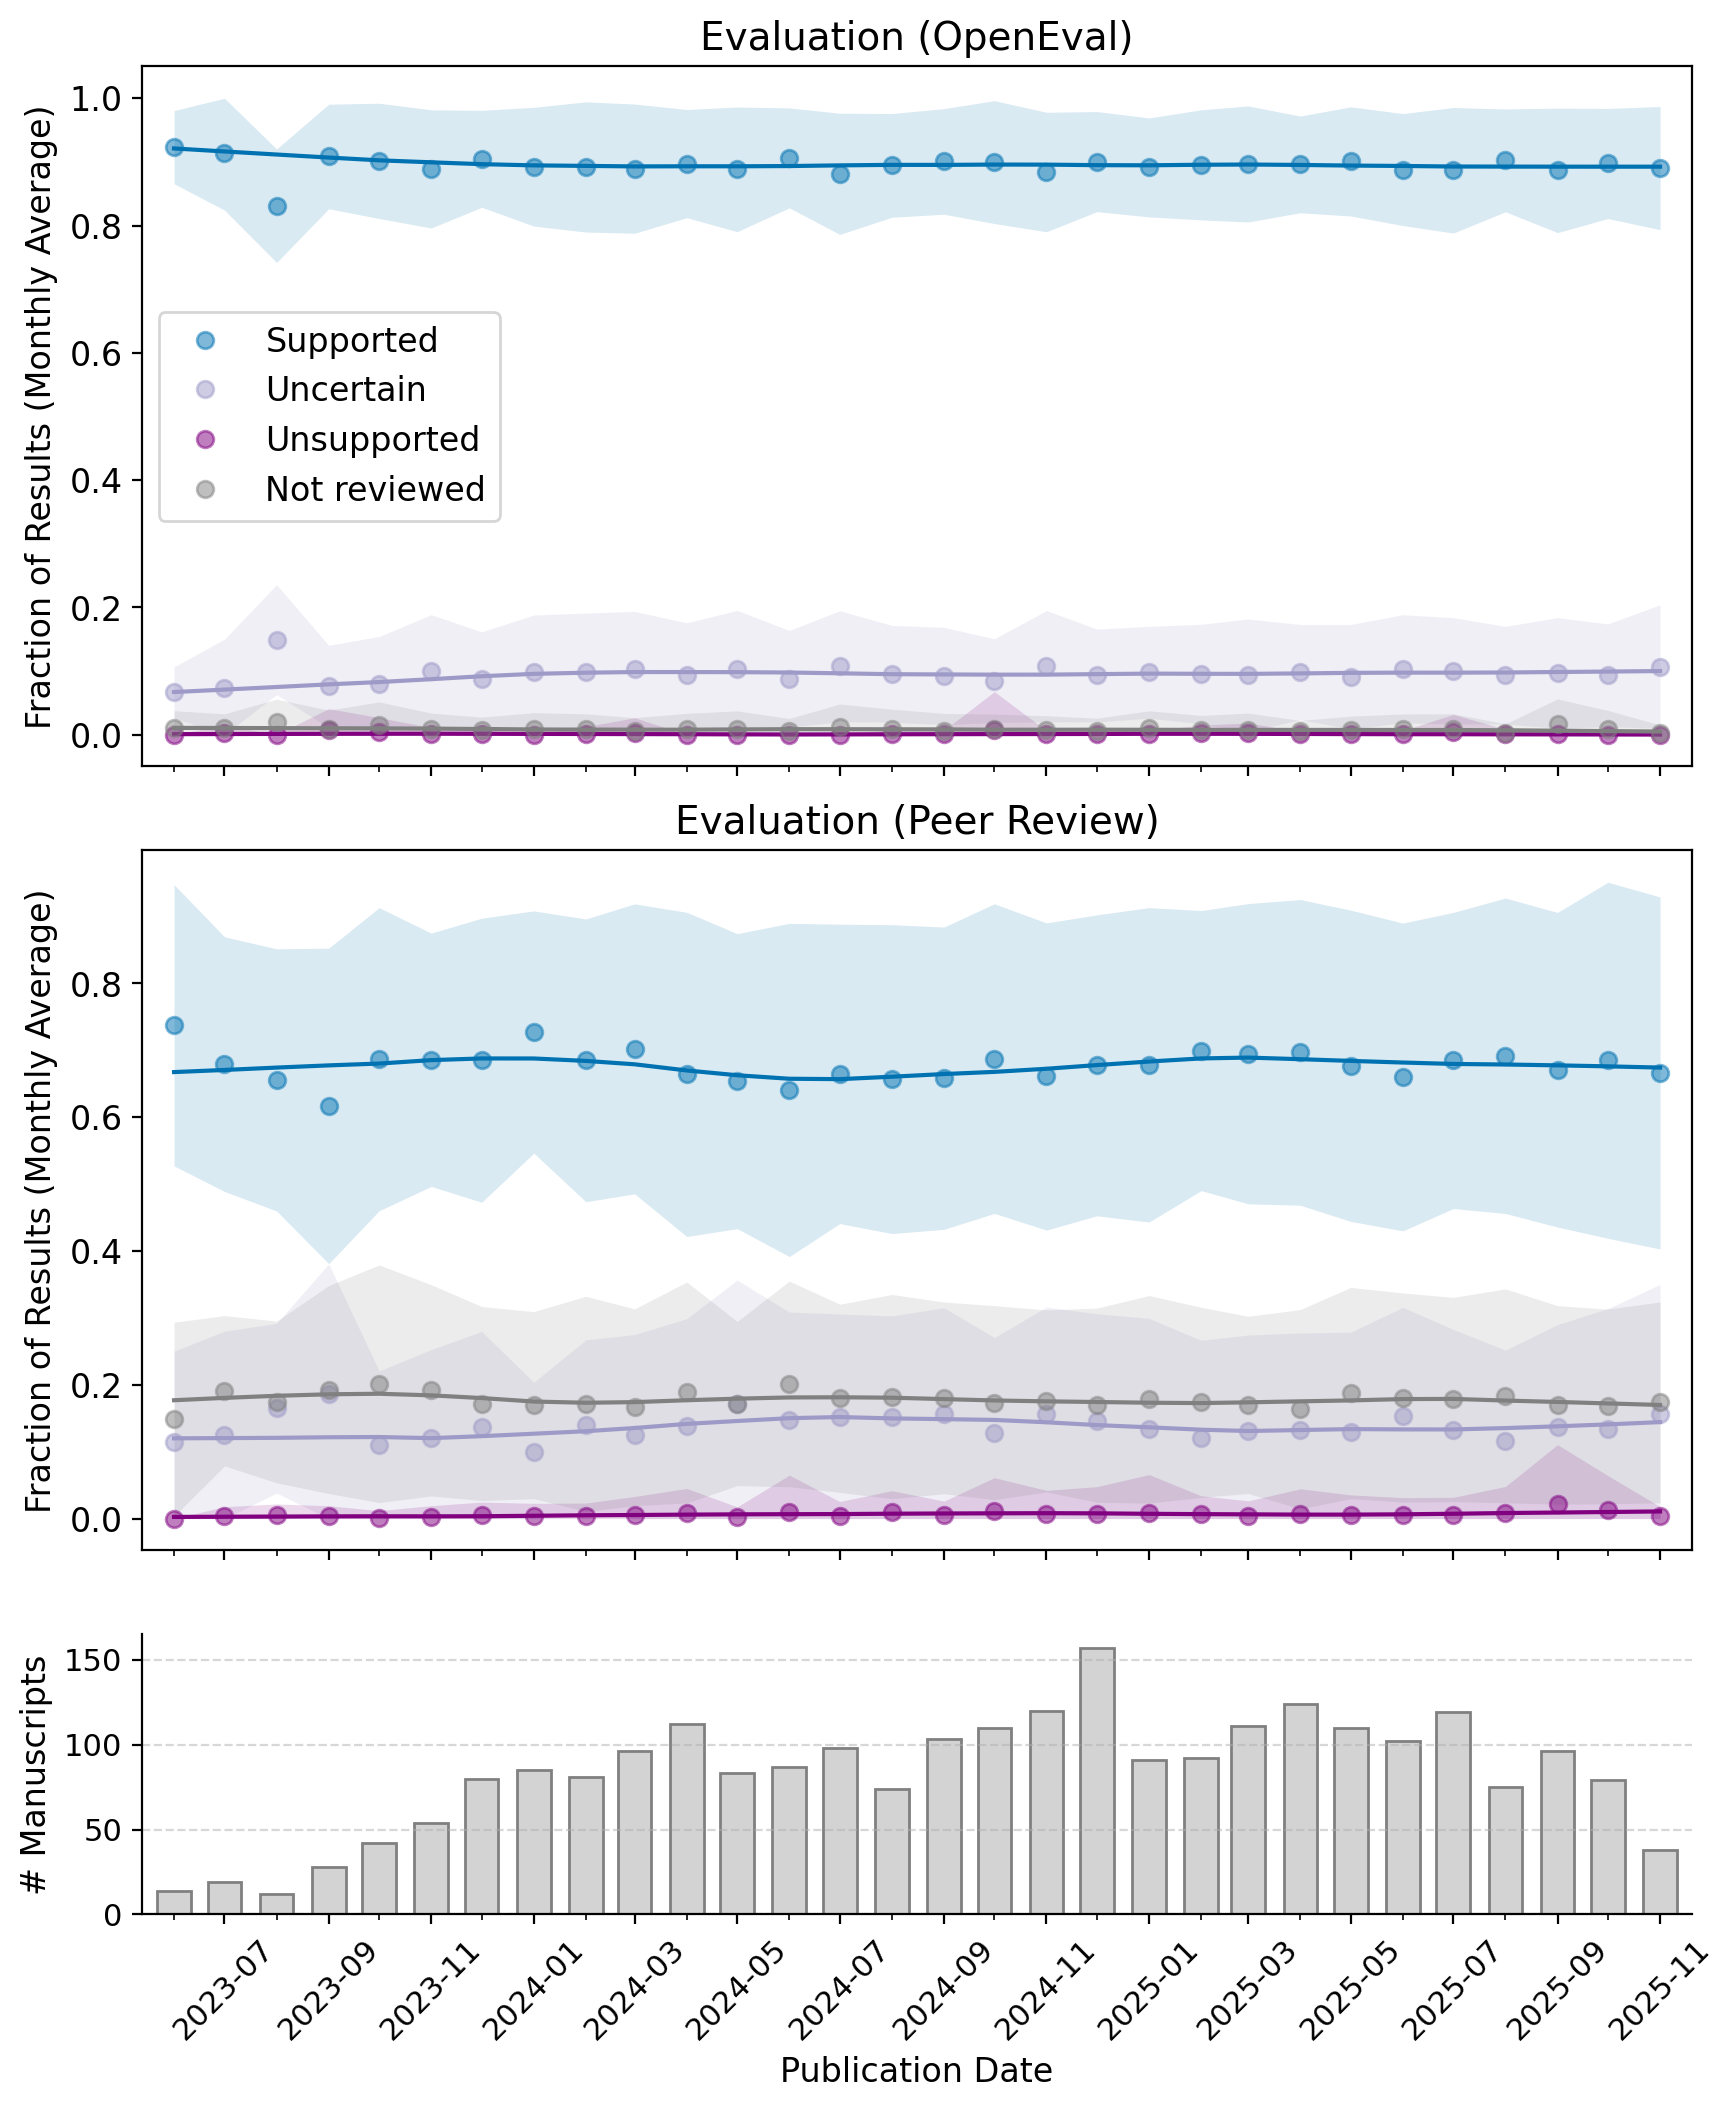

In [202]:
fontsize = 12

# Ensure 'pub_date' and 'month' are present
df_cmp["pub_date"] = pd.to_datetime(df_cmp["pub_date"])
df_cmp["month"] = df_cmp["pub_date"].dt.to_period("M")

blues_cmap = plt.get_cmap("Blues")
darkest_blue = blues_cmap(1.0)
middle_blue = blues_cmap(0.4)

# Use purple colors from the Purples colormap
purples_cmap = plt.get_cmap("Purples")
darkest_purple = purples_cmap(1.0)
middle_purple = purples_cmap(0.5)

color_list = ["#0072B2", middle_purple, "purple", "grey"]
type_cols = [
    "openeval_evaluation_type",
    "peer_evaluation_type"
]

# (Unused now) Function to compute local weighted standard error (simple approx)
def moving_std(x, y, window_frac=0.3):
    N = len(x)
    stds = np.zeros(N)
    counts = np.zeros(N)
    width = int(np.ceil(window_frac*N))
    for i in range(N):
        left = max(0, i-width//2)
        right = min(N, i+width//2+1)
        window = y[left:right]
        valid = ~np.isnan(window)
        if valid.sum() > 1:
            stds[i] = np.nanstd(window)
            counts[i] = valid.sum()
        else:
            stds[i] = np.nan
            counts[i] = np.nan
    return stds, counts

def per_month_stats_for(ms_tab, cat):
    """Compute monthly mean and SD across manuscripts for a given category."""
    if cat in ms_tab.columns:
        p = ms_tab[cat] / ms_tab["n"]
    else:
        p = pd.Series(0.0, index=ms_tab.index)  # manuscripts with 0 in this cat → 0 fraction
    stats = (
        p.reset_index()
         .groupby("month")[0]
         .agg(mean="mean", sd="std", n="count")
         .sort_index()
    )
    stats.index = stats.index.to_timestamp(how="start")
    return stats

# --- Barplot: Total number of unique manuscripts per publication month ---
manuscripts_per_month = (
    df_cmp.drop_duplicates(subset=["manuscript_id", "month"])
    .groupby("month")["manuscript_id"]
    .nunique()
)
manuscripts_per_month.index = manuscripts_per_month.index.to_timestamp(how="start")

# Create a 3-row subplot: top 2 for lines, bottom for manuscript count barplot
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(3, 1, height_ratios=[3, 3, 1.2], hspace=0.15)

# Instead of sharing x-axis by constructing a new ax, use sharex only once across all 3 axes
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax2 = fig.add_subplot(gs[2], sharex=ax0)
axs = [ax0, ax1, ax2]

for i, type_col in enumerate(type_cols):
    ax = axs[i]

    # Pooled monthly (not used for error now, but harmless to keep)
    counts_table = (
        df_cmp.groupby(["month", type_col])
        .size()
        .unstack(fill_value=0)
    )
    comparison_counts = counts_table.div(counts_table.sum(axis=1), axis=0)
    comparison_counts.index = comparison_counts.index.to_timestamp(how="start")
    counts_table.index = counts_table.index.to_timestamp(how="start")

    # --- NEW: per-manuscript-per-month fractions and monthly mean/SD (Option 1) ---
    ms_tab = (
        df_cmp.groupby(["month", "manuscript_id", type_col])
        .size()
        .unstack(fill_value=0)
    )
    ms_tab["n"] = ms_tab.sum(axis=1)  # total comparisons per manuscript-month

    # Which suffix for legend label
    legend_suffix = "OpenEval" if type_col == "openeval_evaluation_type" else "Peer Review"

    # Ensure time is numeric for optional LOWESS on the monthly means
    for cat_idx, cat in enumerate(ordered_statuses):
        if cat in comparison_counts.columns:  # plot only categories that exist in pooled table
            stats = per_month_stats_for(ms_tab, cat)
            if stats.empty:
                continue

            mean = stats["mean"]
            sd = stats["sd"].fillna(0.0)  # if only one manuscript that month, SD is NaN → 0
            upper = (mean + sd).clip(0, 1)
            lower = (mean - sd).clip(0, 1)

            # Connected band: mean ± 1 SD across manuscripts
            ax.fill_between(
                stats.index,
                lower,
                upper,
                color=color_list[cat_idx],
                alpha=0.15,
                linewidth=0
            )

            # Mean line with markers on top of the band
            ax.plot(
                stats.index,
                mean,
                color=color_list[cat_idx],
                linewidth=2,
                marker='o',
                label=cat,
                ls="",
                alpha=0.5
            )

            # Optional LOWESS on monthly means (trend only, no CI band)
            x_dates = stats.index
            if len(x_dates) > 1:
                x_num = np.array([d.value for d in x_dates])  # integer ns timestamps
                y = mean.values
                valid_idx = ~np.isnan(y)
                if valid_idx.sum() > 1:
                    x_valid = x_num[valid_idx]
                    y_valid = y[valid_idx]
                    loess = sm.nonparametric.lowess(y_valid, x_valid, frac=0.3, return_sorted=True)
                    lowess_x = [pd.Timestamp(int(ts)) for ts in loess[:, 0]]
                    ax.plot(
                        lowess_x,
                        loess[:, 1],
                        color=color_list[cat_idx],
                        linewidth=1.5,
                    )

    # Add vertical lines and annotations for major model releases
    chatgpt_release_events = [
        # {"label": "ChatGPT-3.5", "date": pd.Timestamp("2022-11-30"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
        # {"label": "ChatGPT-4", "date": pd.Timestamp("2023-03-14"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
        # {"label": "GPT-4o", "date": pd.Timestamp("2024-05-13"), "color": "gray", "ha": "center", "va": "top", "pos": 0.95},
        # {"label": "ELife restructuring", "date": pd.Timestamp("2023-01-31"), "color": "grey", "ha": "center", "va": "top", "pos": 0.75},
    ]
    for event in chatgpt_release_events:
        ax.axvline(event["date"], color=event.get("color", "gray"), linestyle="--", linewidth=1)
        if event.get("label") is not None:
            y_lims = ax.get_ylim()
            pos = event.get("pos", 0.95)
            ax.text(
                event["date"],
                y_lims[1] * pos,
                event["label"],
                color=event["color"],
                rotation=90,
                ha=event.get("ha", "right"),
                va=event.get("va", "top"),
                fontsize=fontsize,
                bbox=dict(facecolor="white", edgecolor="none", alpha=1, boxstyle="round,pad=0"),
            )

    ax.margins(x=0.01)
    ax.set_ylabel("Fraction of Results (Monthly Average)", fontsize=fontsize)
    ax.set_title(f"Evaluation ({legend_suffix})", fontsize=fontsize+2)

    # Set tick label font sizes for axes
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.tick_params(axis='both', which='minor', labelsize=fontsize)

    # Set legend font size
    if i == 0:
        ax.legend(loc="center left", fontsize=fontsize)

# --- Add total manuscript barplot on bottom subplot ---
ax_bar = axs[2]
ax_bar.bar(manuscripts_per_month.index, manuscripts_per_month.values,
           width=20, align="center", color="lightgray", edgecolor="gray")
ax_bar.set_ylabel("# Manuscripts", fontsize=fontsize)
ax_bar.set_xlabel("Publication Date", fontsize=fontsize)
ax_bar.set_xlim(axs[0].get_xlim())
ax_bar.grid(axis='y', linestyle='--', alpha=0.5)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.tick_params(axis='both', which='major', labelsize=fontsize-1)
ax_bar.tick_params(axis='x', which='major', rotation=45)

# Set sensible x-ticks for months
ax_bar.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax_bar.xaxis.set_minor_locator(mdates.MonthLocator())
ax_bar.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Remove x tick labels from the top 2 plots
plt.setp(axs[0].get_xticklabels(), visible=False)
plt.setp(axs[1].get_xticklabels(), visible=False)

plt.tight_layout()
plt.show()


In [195]:
# Plot the average supported fraction per month for OpenEval vs Peer Review

def fraction_supported_per_manuscript_per_month(df, evaluation_col, supported_val="Supported"):
    """
    Compute the fraction of 'Supported' results, per manuscript, per month.
    Returns DataFrame with index (month, manuscript_id) and a column 'supported_frac'.
    """
    # Get supported boolean
    supported = df[evaluation_col].astype(str).str.lower() == supported_val.lower()
    grouped = df.groupby(["month", "manuscript_id"])
    frac_supported = grouped.apply(lambda d: (d[evaluation_col].astype(str).str.lower() == supported_val.lower()).mean())
    return frac_supported.rename("supported_frac")

# Get per-manuscript-per-month fractions for both
peer_per_ms = fraction_supported_per_manuscript_per_month(df_cmp, "peer_evaluation_type")
llm_per_ms = fraction_supported_per_manuscript_per_month(df_cmp, "openeval_evaluation_type")

# Now average across manuscripts for each month
peer_monthly = peer_per_ms.groupby("month").mean()
llm_monthly = llm_per_ms.groupby("month").mean()

# Only keep months with data for both (inner join)
shared_months = peer_monthly.index.intersection(llm_monthly.index)
peer_monthly = peer_monthly.loc[shared_months]
llm_monthly = llm_monthly.loc[shared_months]

# Make a new scatterplot: Each point is a month (label), x=peer, y=openeval
plt.figure(figsize=(7,7))
plt.scatter(peer_monthly.values, llm_monthly.values, s=60, color='purple', edgecolor='k', alpha=0.8)
# plt.plot([0,1],[0,1],'--',color='gray', linewidth=1)
# for m, x, y in zip(shared_months.to_timestamp(), peer_monthly, llm_monthly):
#     plt.text(x+0.01, y+0.01, m.strftime("%Y-%m"), fontsize=9, alpha=0.6)  # nudge for clarity

plt.xlabel("Avg Fraction Peer Supported")
plt.ylabel("Avg Fraction OpenEval Supported")
plt.title("Average Supported Fraction per Month\nOpenEval vs Peer Review")
# plt.xlim(0,1)
# plt.ylim(0,1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_56620/3259373813.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  frac_supported = grouped.apply(lambda d: (d[evaluation_col].astype(str).str.lower() == supported_val.lower()).mean())


TypeError: Index(...) must be called with a collection of some kind, 'supported_frac' was passed

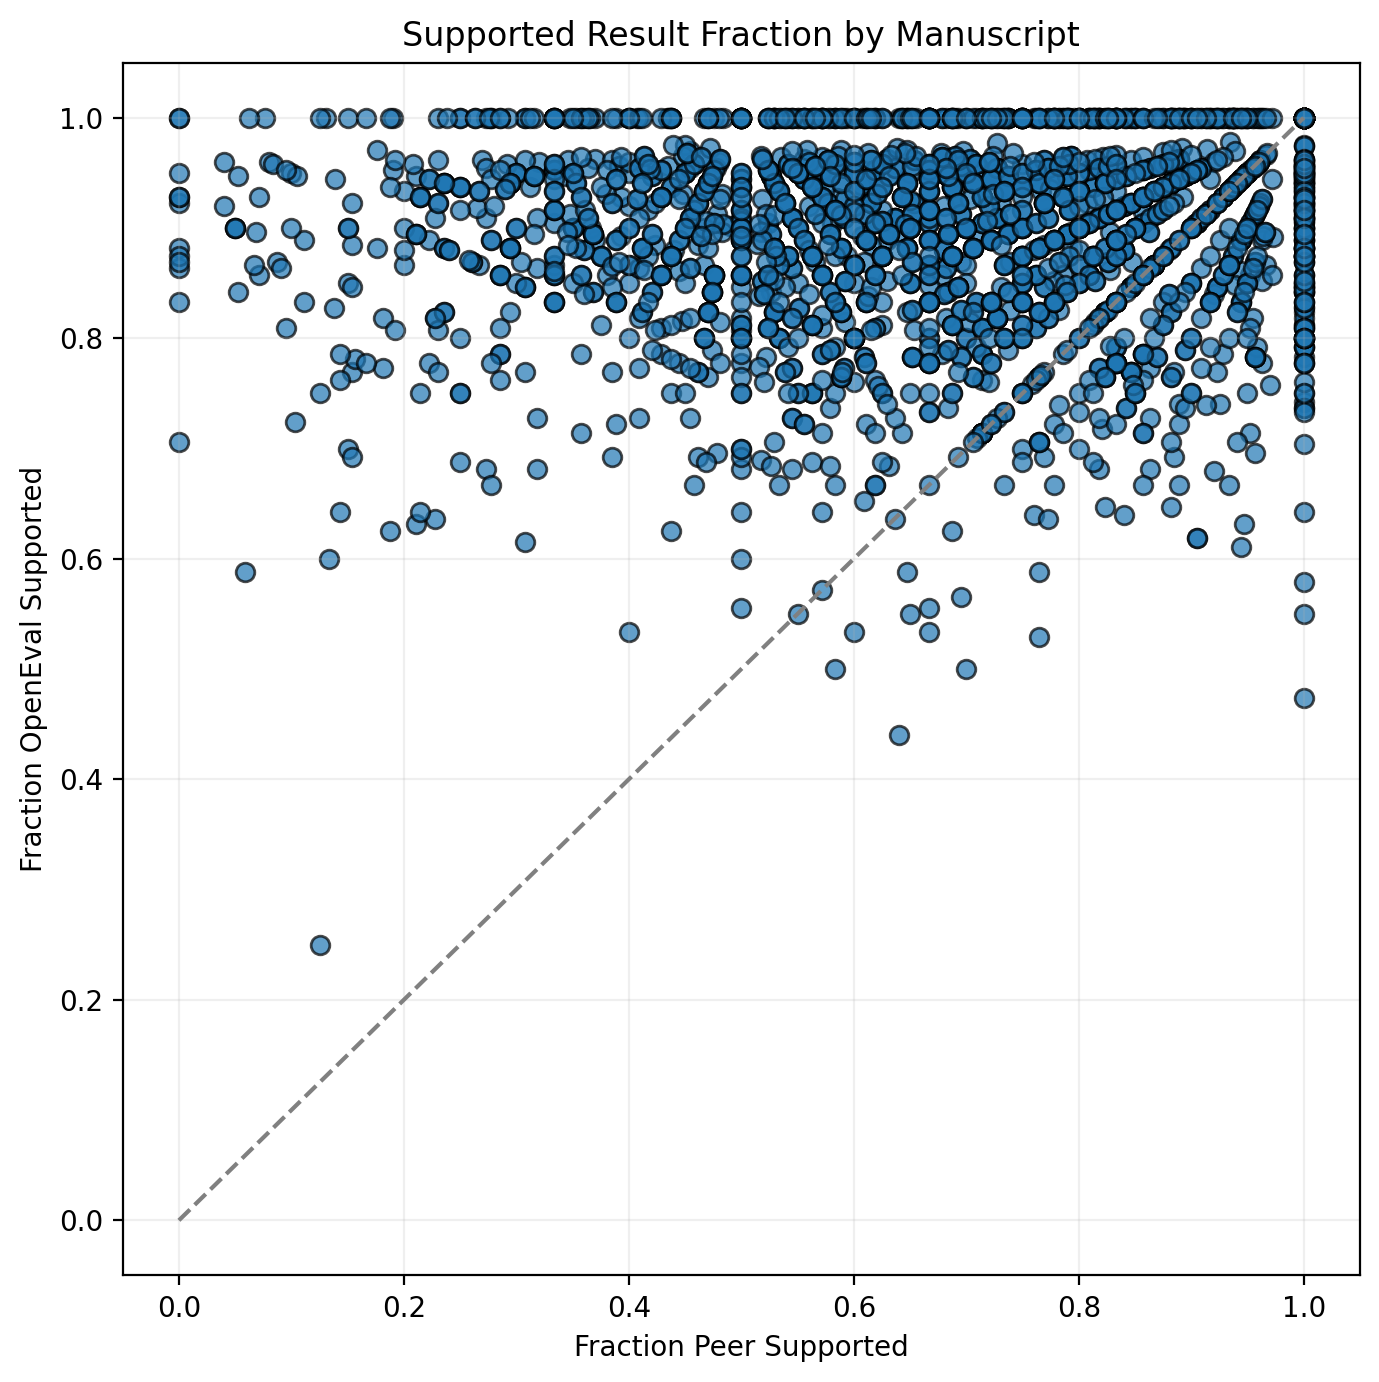

In [ ]:
def get_fraction_supported(df, id_col, evaluation_col, supported_val="Supported"):
    """
    Count for each manuscript_id the fraction that are 'Supported' according to evaluation_col.
    """
    # Get boolean Series: True where supported, else False
    supported = df[evaluation_col].astype(str).str.lower() == supported_val.lower()
    # Groupby id_col, aggregate by mean on the boolean Series
    frac_supported = supported.groupby(df[id_col]).mean()
    return frac_supported

peer_frac = get_fraction_supported(df_cmp, "manuscript_id", "peer_evaluation_type")
llm_frac = get_fraction_supported(df_cmp, "manuscript_id", "openeval_evaluation_type")

# Make sure to include only manuscripts present in both
df_scatter = (
    pd.DataFrame({
        "Fraction Peer Supported": peer_frac,
        "Fraction OpenEval Supported": llm_frac
    })
    .dropna()
)

plt.figure(figsize=(7, 7))
plt.scatter(df_scatter["Fraction Peer Supported"], df_scatter["Fraction OpenEval Supported"],
            s=45, edgecolor="k", alpha=0.7)
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("Fraction Peer Supported")
plt.ylabel("Fraction OpenEval Supported")
plt.title("Supported Result Fraction by Manuscript")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [ ]:
df_scatter.sort_values(["Fraction OpenEval Supported", "Fraction Peer Supported"], ascending=True)

,Fraction Peer Supported,Fraction OpenEval Supported
manuscript_id,,
elife-95678,0.125000,0.250000
elife-92645,0.640000,0.440000
elife-91985,1.000000,0.473684
elife-89376,0.583333,0.500000
elife-101583,0.700000,0.500000
...,...,...
elife-98818,1.000000,1.000000
elife-98827,1.000000,1.000000
elife-99210,1.000000,1.000000


Plot Cramer's V:

Cramér's V (OpenEval MAJOR/MINOR vs Elife significance) = 0.015
Cramér's V (Peer MAJOR/MINOR vs Elife significance) = 0.011
Cramér's V (OpenEval evidence vs Elife evidence) = 0.013
Cramér's V (Peer evidence vs Elife evidence) = 0.233


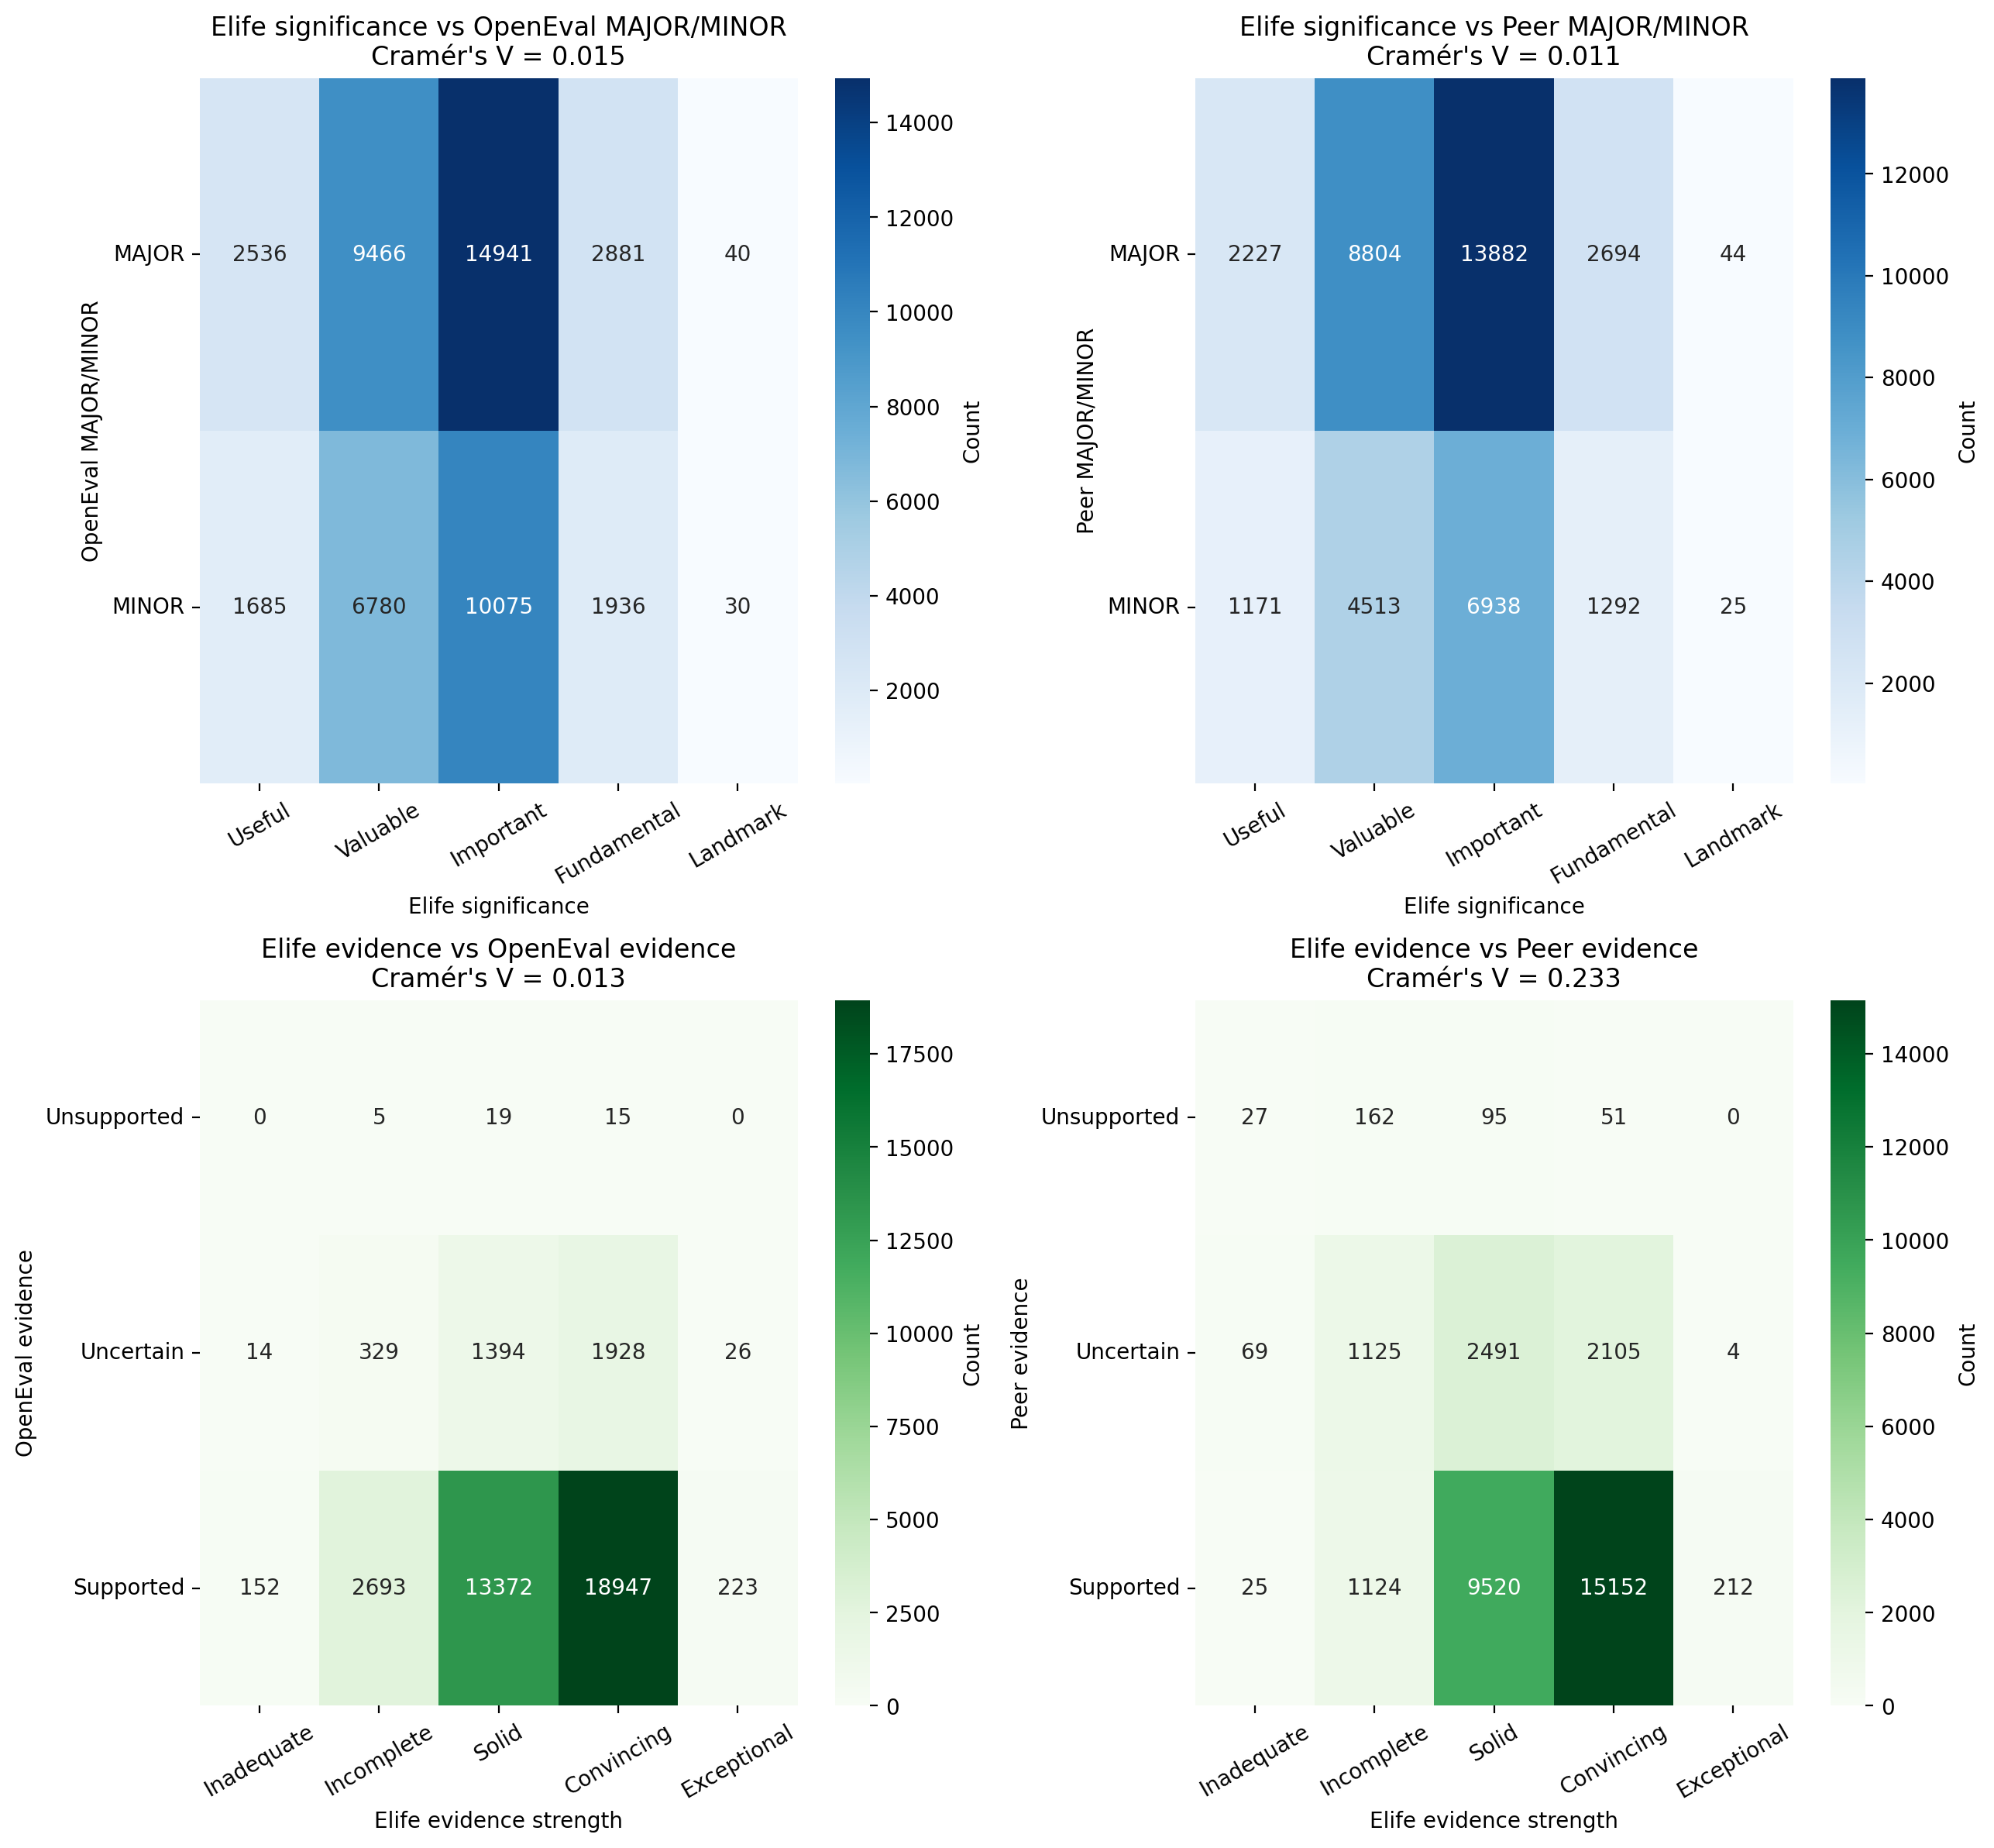

In [ ]:
from scipy.stats import chi2_contingency

# 1. Load the human ratings from prc_classifications.tsv
df_human = pd.read_csv("../prc_classifications.tsv", sep="\t")

# 2. Define categorical orderings and mappings for scores
signif_order = ["Useful", "Valuable", "Important", "Fundamental", "Landmark"]
evid_order   = ["Inadequate", "Incomplete", "Solid", "Convincing", "Exceptional"]

signif_scale = {"Useful":1, "Valuable":2, "Important":3, "Fundamental":4, "Landmark":5}
evid_scale   = {"Inadequate":1, "Incomplete":2, "Solid":3, "Convincing":4, "Exceptional":5}

# 3. Merge classification data so each result has a human score
# We'll use manuscript_id from df_cmp and paper_id from df_human to join

# Ensure keys are compatible
df_cmp['manuscript_id'] = df_cmp['manuscript_id'].astype(str)
df_human['paper_id'] = df_human['paper_id'].astype(str)

# Select relevant columns
df_human = df_human[["paper_id", "claim_importance", "evidence_strength"]].copy()

# Merge to get human data on each manuscript
df_cmp_annot = pd.merge(
    df_cmp,
    df_human,
    left_on="manuscript_id",
    right_on="paper_id",
    how="left"
)

# Map the human rating strings to scores (for plotting)
df_cmp_annot["claim_importance_score"] = df_cmp_annot["claim_importance"].map(signif_scale)
df_cmp_annot["evidence_strength_score"] = df_cmp_annot["evidence_strength"].map(evid_scale)

def cramers_v(contingency: pd.DataFrame) -> float:
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))

# --- Compare significance/importance ---

major_minor_levels = ["MAJOR", "MINOR"]

# OpenEval significance v. Elife significance
ct_oe_signif = pd.crosstab(
    df_cmp_annot['openeval_result_type'],
    df_cmp_annot['claim_importance'],
).reindex(index=major_minor_levels, columns=signif_order)

v_oe_signif = cramers_v(ct_oe_signif)

# Peer significance v. Elife significance
ct_peer_signif = pd.crosstab(
    df_cmp_annot['peer_result_type'],
    df_cmp_annot['claim_importance'],
).reindex(index=major_minor_levels, columns=signif_order)

v_peer_signif = cramers_v(ct_peer_signif)

print(f"Cramér's V (OpenEval MAJOR/MINOR vs Elife significance) = {v_oe_signif:.3f}")
print(f"Cramér's V (Peer MAJOR/MINOR vs Elife significance) = {v_peer_signif:.3f}")

# --- Compare evidence_strength/uncertainty ---

# Define label sets for evidence
evidence_levels = ["Unsupported", "Uncertain", "Supported"]

# OpenEval evidence vs Elife evidence
ct_oe_evid = pd.crosstab(
    df_cmp_annot['openeval_evaluation_type'],
    df_cmp_annot['evidence_strength'],
).reindex(index=evidence_levels, columns=evid_order)

v_oe_evid = cramers_v(ct_oe_evid)

# Peer evidence vs Elife evidence
ct_peer_evid = pd.crosstab(
    df_cmp_annot['peer_evaluation_type'],
    df_cmp_annot['evidence_strength'],
).reindex(index=evidence_levels, columns=evid_order)

v_peer_evid = cramers_v(ct_peer_evid)

print(f"Cramér's V (OpenEval evidence vs Elife evidence) = {v_oe_evid:.3f}")
print(f"Cramér's V (Peer evidence vs Elife evidence) = {v_peer_evid:.3f}")

# --- Plots: Heatmaps ---

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
plt.subplots_adjust(wspace=0.25, hspace=0.35)

# Top row: significance/importance heatmaps
sns.heatmap(
    ct_oe_signif,
    annot=True, fmt='d', cmap='Blues',
    ax=axes[0,0], cbar_kws={'label': 'Count'}
)
axes[0,0].set_title(f"Elife significance vs OpenEval MAJOR/MINOR\nCramér's V = {v_oe_signif:.3f}")
axes[0,0].set_xlabel("Elife significance")
axes[0,0].set_ylabel("OpenEval MAJOR/MINOR")
axes[0,0].set_xticklabels(signif_order, rotation=30)
axes[0,0].set_yticklabels(major_minor_levels, rotation=0)

sns.heatmap(
    ct_peer_signif,
    annot=True, fmt='d', cmap='Blues',
    ax=axes[0,1], cbar_kws={'label': 'Count'}
)
axes[0,1].set_title(f"Elife significance vs Peer MAJOR/MINOR\nCramér's V = {v_peer_signif:.3f}")
axes[0,1].set_xlabel("Elife significance")
axes[0,1].set_ylabel("Peer MAJOR/MINOR")
axes[0,1].set_xticklabels(signif_order, rotation=30)
axes[0,1].set_yticklabels(major_minor_levels, rotation=0)

# Bottom row: evidence heatmaps
sns.heatmap(
    ct_oe_evid,
    annot=True, fmt='d', cmap='Greens',
    ax=axes[1,0], cbar_kws={'label': 'Count'}
)
axes[1,0].set_title(f"Elife evidence vs OpenEval evidence\nCramér's V = {v_oe_evid:.3f}")
axes[1,0].set_xlabel("Elife evidence strength")
axes[1,0].set_ylabel("OpenEval evidence")
axes[1,0].set_xticklabels(evid_order, rotation=30)
axes[1,0].set_yticklabels(evidence_levels, rotation=0)

sns.heatmap(
    ct_peer_evid,
    annot=True, fmt='d', cmap='Greens',
    ax=axes[1,1], cbar_kws={'label': 'Count'}
)
axes[1,1].set_title(f"Elife evidence vs Peer evidence\nCramér's V = {v_peer_evid:.3f}")
axes[1,1].set_xlabel("Elife evidence strength")
axes[1,1].set_ylabel("Peer evidence")
axes[1,1].set_xticklabels(evid_order, rotation=30)
axes[1,1].set_yticklabels(evidence_levels, rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import chi2_contingency

# ========= Inputs assumed present =========
# df_cmp : result-level dataframe with columns like:
#   manuscript_id, openeval_result_type in {"MAJOR","MINOR"},
#   peer_result_type in {"MAJOR","MINOR"},
#   openeval_evaluation_type in {"Unsupported","Uncertain","Supported"},
#   peer_evaluation_type in {"Unsupported","Uncertain","Supported"}
#
# df_human : manuscript-level dataframe with columns:
#   paper_id (string), claim_importance (eLife significance),
#   evidence_strength (eLife evidence)

# ---------- Setup & merge ----------
signif_order = ["Useful", "Valuable", "Important", "Fundamental", "Landmark"]
evid_order   = ["Inadequate", "Incomplete", "Solid", "Convincing", "Exceptional"]

major_minor_levels = ["MAJOR", "MINOR"]
evidence_levels    = ["Unsupported", "Uncertain", "Supported"]

# Ensure keys are strings
df_cmp['manuscript_id'] = df_cmp['manuscript_id'].astype(str)

df_human = df_human[["paper_id", "claim_importance", "evidence_strength"]].copy()
df_human['paper_id'] = df_human['paper_id'].astype(str)

# Keep one row per manuscript with eLife labels
df_elife = df_human.drop_duplicates(subset=['paper_id']).rename(columns={'paper_id':'manuscript_id'})
df_elife = df_elife[
    df_elife['claim_importance'].isin(signif_order) &
    df_elife['evidence_strength'].isin(evid_order)
].copy()

# Optionally restrict df_cmp to only manuscripts that have eLife ratings
df_cmp = df_cmp[df_cmp['manuscript_id'].isin(df_elife['manuscript_id'])].copy()

# ---------- Helpers ----------
def frac_by_manuscript(df, col, levels, id_col="manuscript_id"):
    """
    For a categorical column 'col' on result-level rows, compute per-manuscript
    fractions over the provided 'levels'. Returns a DataFrame with one row per manuscript
    and columns named exactly as 'levels', summing to 1 across those level columns for rows
    with at least one result in 'df' for that manuscript. Manuscripts with no rows are dropped.
    Missing levels get fraction 0.
    """
    # Count per manuscript per level
    counts = (
        df.groupby([id_col, col])
          .size()
          .unstack(fill_value=0)
          .reindex(columns=levels, fill_value=0)
    )
    # Total results per manuscript (across the levels only)
    totals = counts.sum(axis=1)
    counts = counts[totals > 0]  # drop manuscripts with no results in these levels
    fracs = counts.div(totals[totals > 0], axis=0)
    fracs.index.name = id_col
    return fracs.reset_index()

def cramers_v_from_table(ct):
    """
    Cramér's V on a contingency 'table' where entries are positive reals
    (fractional "equivalent counts"). The grand total is used as n.
    """
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, k = ct.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))

def build_fraction_contingency(fracs_df, elife_df, elife_col, row_levels, col_levels):
    """
    Sum manuscript-level fractions into a 2D table against an eLife manuscript label.
    For manuscripts in each eLife category (columns), sum their fractions across row_levels.
    Each manuscript contributes total weight 1, so column totals equal # manuscripts in that eLife category.
    """
    # Merge to align each manuscript's fractions with its eLife category
    merged = pd.merge(fracs_df, elife_df[['manuscript_id', elife_col]],
                      on='manuscript_id', how='inner')
    # Initialize the table with zeros
    ct = pd.DataFrame(0.0, index=row_levels, columns=col_levels)
    # For each eLife column category, add up row-wise fractions from the manuscripts in that category
    for col_cat in col_levels:
        subset = merged[merged[elife_col] == col_cat]
        if subset.empty:
            continue
        # Sum fractions across manuscripts (each manuscript row sums to 1 across row_levels)
        summed = subset[row_levels].sum(axis=0)
        ct.loc[row_levels, col_cat] = summed.values
    return ct

# ---------- Compute per-manuscript fractions ----------
# Significance: MAJOR/MINOR
oe_signif_frac = frac_by_manuscript(df_cmp, 'openeval_result_type', major_minor_levels)
peer_signif_frac = frac_by_manuscript(df_cmp, 'peer_result_type', major_minor_levels)

# Evidence: Unsupported/Uncertain/Supported
oe_evid_frac = frac_by_manuscript(df_cmp, 'openeval_evaluation_type', evidence_levels)
peer_evid_frac = frac_by_manuscript(df_cmp, 'peer_evaluation_type', evidence_levels)

# ---------- Build "equivalent count" tables (sum of fractions) ----------
ct_oe_signif_frac = build_fraction_contingency(
    oe_signif_frac, df_elife, 'claim_importance',
    row_levels=major_minor_levels, col_levels=signif_order
)

ct_peer_signif_frac = build_fraction_contingency(
    peer_signif_frac, df_elife, 'claim_importance',
    row_levels=major_minor_levels, col_levels=signif_order
)

ct_oe_evid_frac = build_fraction_contingency(
    oe_evid_frac, df_elife, 'evidence_strength',
    row_levels=evidence_levels, col_levels=evid_order
)

ct_peer_evid_frac = build_fraction_contingency(
    peer_evid_frac, df_elife, 'evidence_strength',
    row_levels=evidence_levels, col_levels=evid_order
)

# ---------- Cramér's V on fractional tables ----------
v_oe_signif = cramers_v_from_table(ct_oe_signif_frac)
v_peer_signif = cramers_v_from_table(ct_peer_signif_frac)
v_oe_evid = cramers_v_from_table(ct_oe_evid_frac)
v_peer_evid = cramers_v_from_table(ct_peer_evid_frac)

print(f"Cramér's V (OpenEval frac MAJOR/MINOR vs eLife significance) = {v_oe_signif:.3f}")
print(f"Cramér's V (Peer frac MAJOR/MINOR vs eLife significance) = {v_peer_signif:.3f}")
print(f"Cramér's V (OpenEval frac evidence vs eLife evidence) = {v_oe_evid:.3f}")
print(f"Cramér's V (Peer frac evidence vs eLife evidence) = {v_peer_evid:.3f}")

Cramér's V (OpenEval frac MAJOR/MINOR vs eLife significance) = 0.021
Cramér's V (Peer frac MAJOR/MINOR vs eLife significance) = 0.022
Cramér's V (OpenEval frac evidence vs eLife evidence) = 0.019
Cramér's V (Peer frac evidence vs eLife evidence) = 0.217


/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_36823/1504274442.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([id_col, col])
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_36823/1504274442.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([id_col, col])


NameError: name 'oe_signif_pct' is not defined

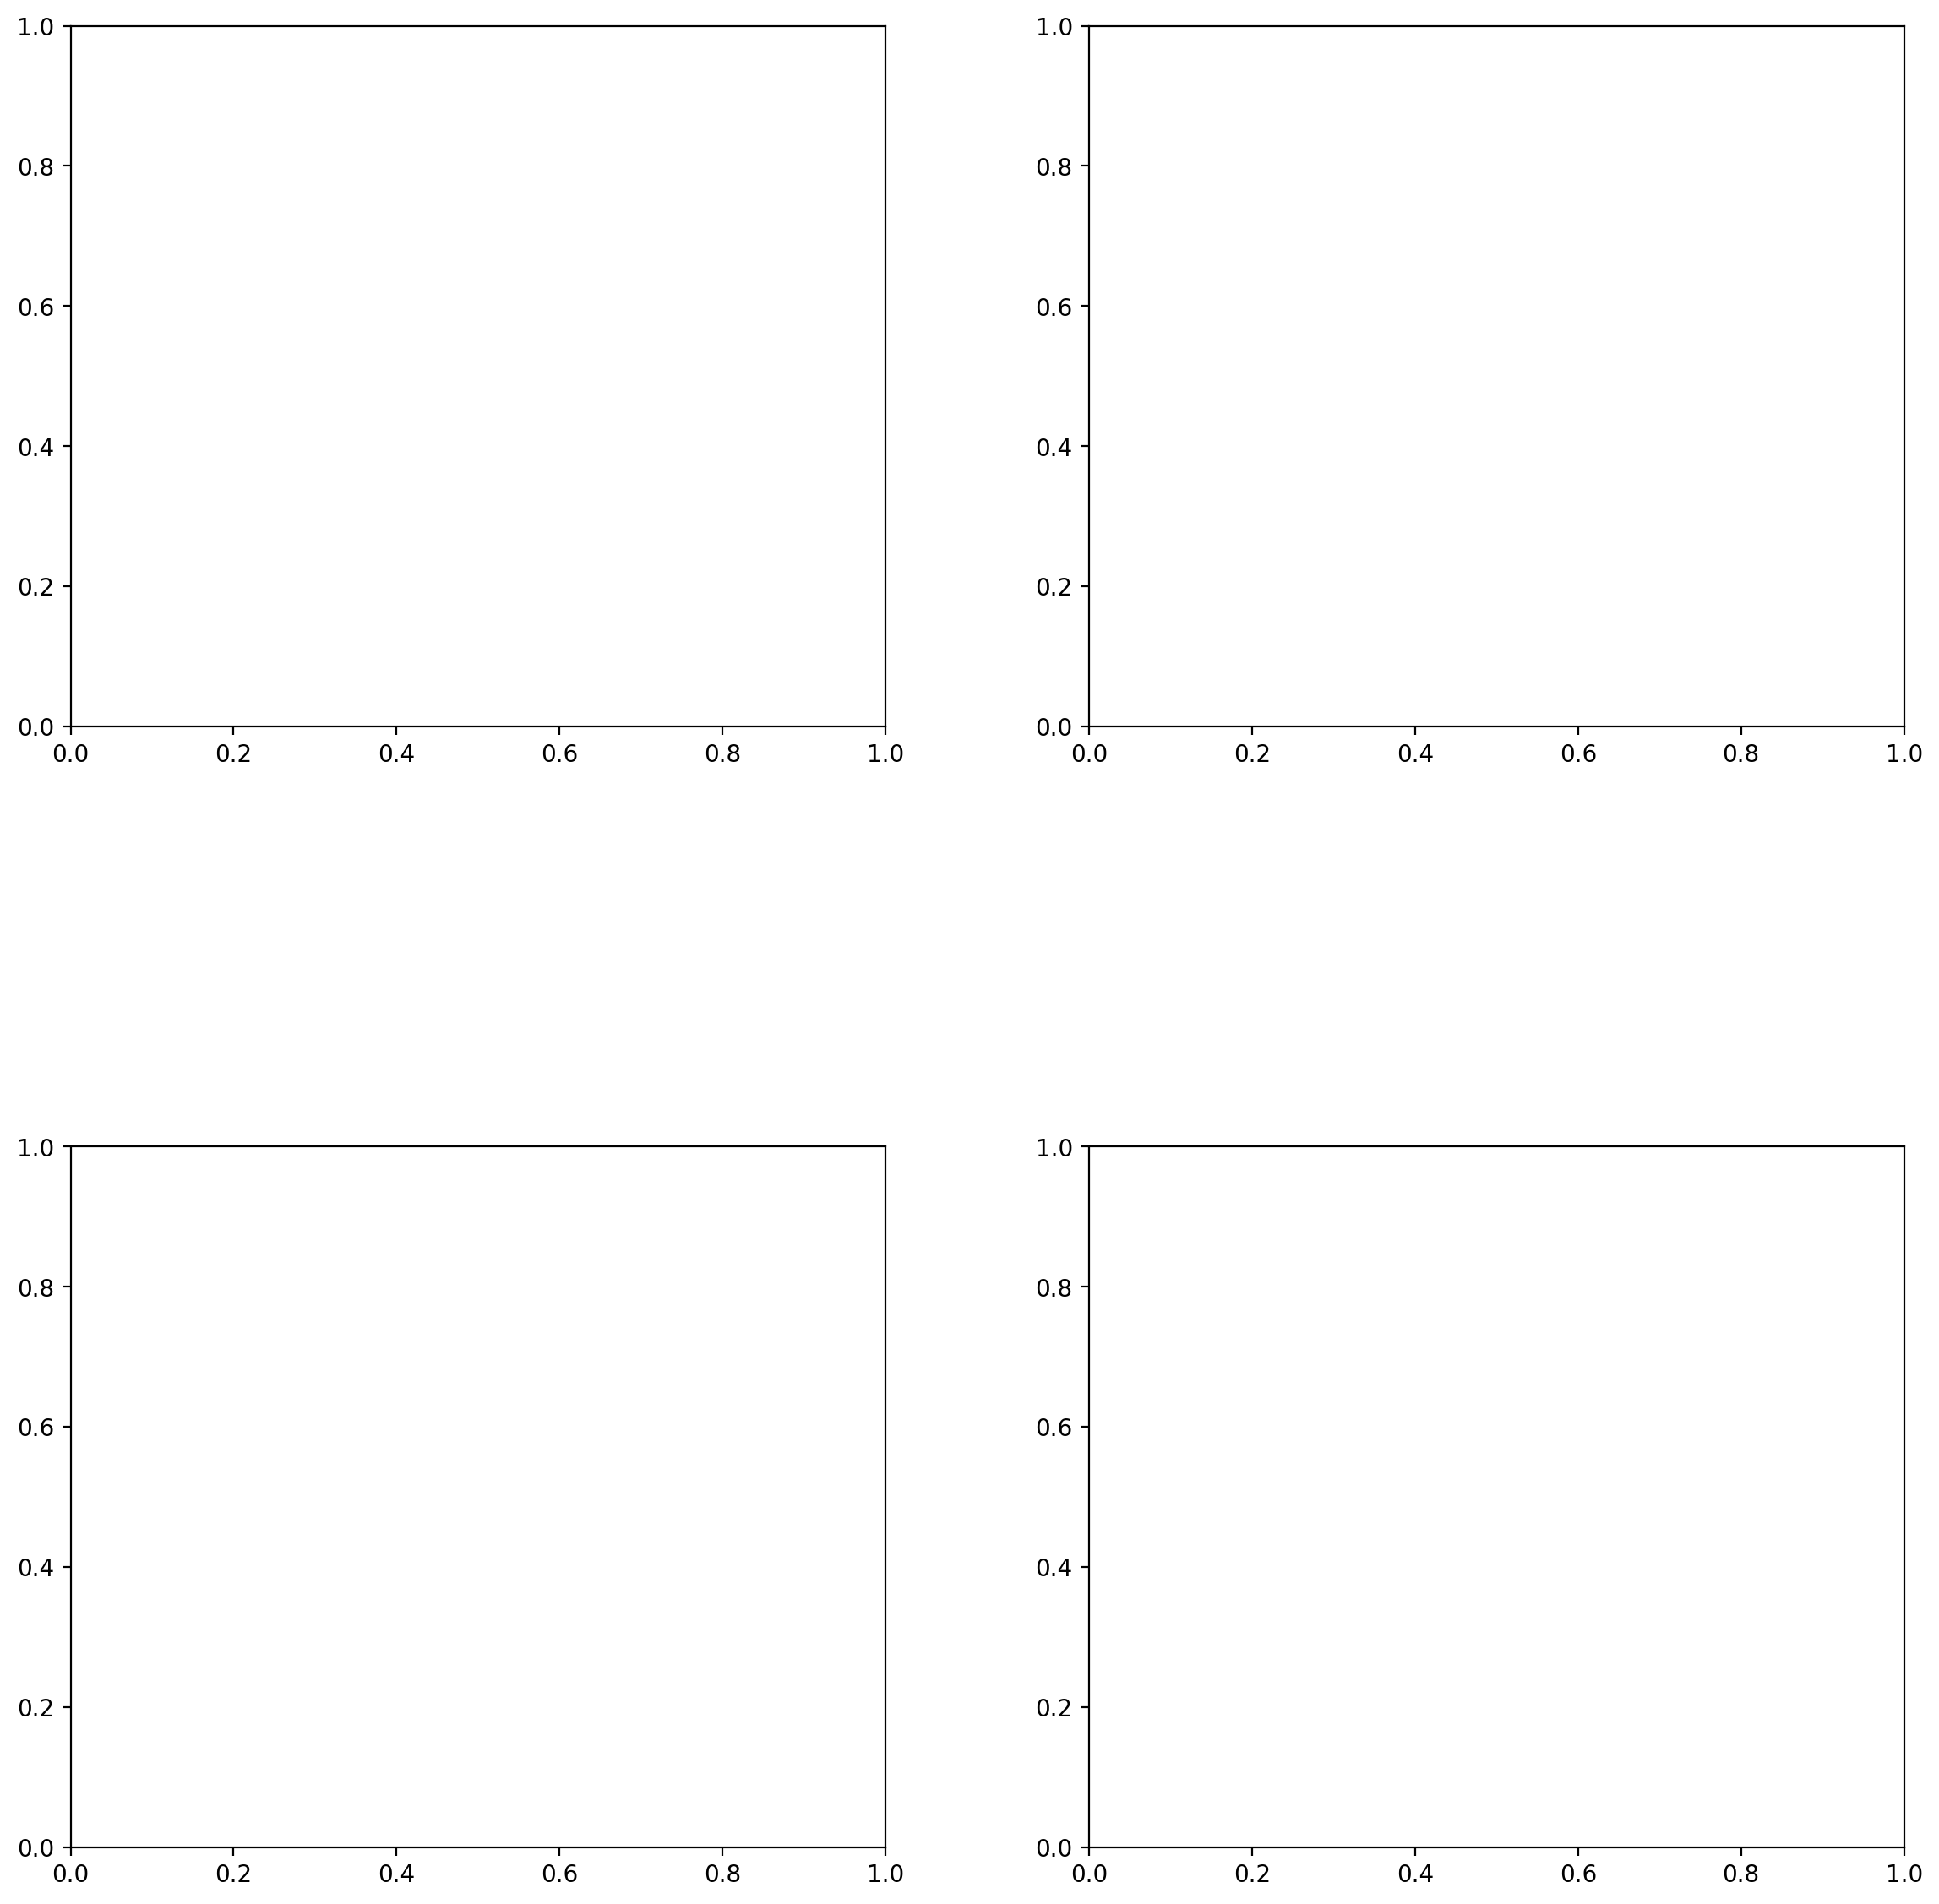

In [ ]:
from matplotlib.gridspec import GridSpec

def add_bar_above_heatmap(
    ax_heat,
    counts,
    height_rel=0.22,
    pad_rel=0.04,
    ylabel="# manuscripts",    # relabeled from "n"
    fmt="{:,}",           # how to format the numbers
    text_size=9,
    text_rotation=0
):
    """
    Add a barplot inside the heatmap's axes, aligned to heatmap columns,
    and annotate bars with their counts.
    """
    ncols = len(counts)

    # Inset bar axis across full width of heatmap, just above it
    bar_ax = ax_heat.inset_axes([0, 1.0 + pad_rel, 1.0, height_rel],
                                transform=ax_heat.transAxes)

    # Match x-limits to heatmap -> perfect alignment
    xmin, xmax = ax_heat.get_xlim()
    bar_ax.set_xlim(xmin, xmax)

    # Bar centers 0.5, 1.5, ...
    x = np.arange(ncols) + 0.5
    y = np.asarray(counts.values, dtype=float)
    y = np.nan_to_num(y, nan=0.0)

    # Leave headroom for text
    ymax = y.max() if y.size else 1.0
    bar_ax.set_ylim(0, (1.12 * ymax) if ymax > 0 else 1.0)

    # Draw bars
    bar_ax.bar(x, y, width=1.0)
    bar_ax.set_xticks([])
    bar_ax.set_yticks([])
    bar_ax.set_ylabel(ylabel)

    for s in ("right", "top", "left", "bottom"):
        bar_ax.spines[s].set_visible(False)

    # Add value labels
    eps = 0.01 * (bar_ax.get_ylim()[1] or 1.0)
    for xi, yi in zip(x, y):
        bar_ax.text(
            xi, yi + (eps if yi >= 0 else 0),
            fmt.format(int(round(yi))),
            ha="center", va="bottom",
            fontsize=text_size, rotation=text_rotation
        )

    return bar_ax

# ---- plotting ----
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
plt.subplots_adjust(wspace=0.25, hspace=0.6)

# Top-left: eLife significance vs OpenEval
ax = axes[0, 0]
sns.heatmap(
    oe_signif_pct, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100,
    ax=ax, cbar_kws={'label': 'Mean % of results per manuscript'}
)
ax.set_title(f"eLife significance vs OpenEval (per-manuscript fractions)\nCramér's V = {v_oe_signif:.3f}")
ax.set_xlabel("eLife significance")
ax.set_ylabel("OpenEval MAJOR/MINOR")
ax.set_xticklabels(signif_order, rotation=30)
ax.set_yticklabels(major_minor_levels, rotation=0)
counts_signif_used = ct_oe_signif_frac.sum(axis=0).astype(int)
add_bar_above_heatmap(ax, counts_signif_used)

# Top-right: eLife significance vs Peer
ax = axes[0, 1]
sns.heatmap(
    peer_signif_pct, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100,
    ax=ax, cbar_kws={'label': 'Mean % of results per manuscript'}
)
ax.set_title(f"eLife significance vs Peer (per-manuscript fractions)\nCramér's V = {v_peer_signif:.3f}")
ax.set_xlabel("eLife significance")
ax.set_ylabel("Peer MAJOR/MINOR")
ax.set_xticklabels(signif_order, rotation=30)
ax.set_yticklabels(major_minor_levels, rotation=0)
counts_signif_used_peer = ct_peer_signif_frac.sum(axis=0).astype(int)
add_bar_above_heatmap(ax, counts_signif_used_peer)

# Bottom-left: eLife evidence vs OpenEval
ax = axes[1, 0]
sns.heatmap(
    oe_evid_pct, annot=True, fmt='.1f', cmap='Greens', vmin=0, vmax=100,
    ax=ax, cbar_kws={'label': 'Mean % of results per manuscript'}
)
ax.set_title(f"eLife evidence vs OpenEval (per-manuscript fractions)\nCramér's V = {v_oe_evid:.3f}")
ax.set_xlabel("eLife evidence strength")
ax.set_ylabel("OpenEval evidence")
ax.set_xticklabels(evid_order, rotation=30)
ax.set_yticklabels(evidence_levels, rotation=0)
counts_evid_used = ct_oe_evid_frac.sum(axis=0).astype(int)
add_bar_above_heatmap(ax, counts_evid_used)

# Bottom-right: eLife evidence vs Peer
ax = axes[1, 1]
sns.heatmap(
    peer_evid_pct, annot=True, fmt='.1f', cmap='Greens', vmin=0, vmax=100,
    ax=ax, cbar_kws={'label': 'Mean % of results per manuscript'}
)
ax.set_title(f"eLife evidence vs Peer (per-manuscript fractions)\nCramér's V = {v_peer_evid:.3f}")
ax.set_xlabel("eLife evidence strength")
ax.set_ylabel("Peer evidence")
ax.set_xticklabels(evid_order, rotation=30)
ax.set_yticklabels(evidence_levels, rotation=0)
counts_evid_used_peer = ct_peer_evid_frac.sum(axis=0).astype(int)
add_bar_above_heatmap(ax, counts_evid_used_peer)

plt.show()
